[21:14:24] Device: cuda | dtype: torch.float64
[21:14:24] 
===== Start rep 1/20 =====
[21:14:42] [rep 001/20] α=1.000 | best -ELBO=-1.601004 @epoch 1190 | MSE=0.000186 | Z-drift=0.0000 | ℓ=0.0956 σ²=2.5392


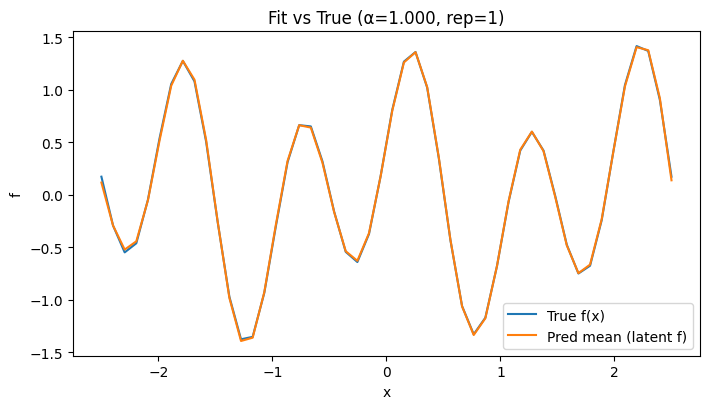

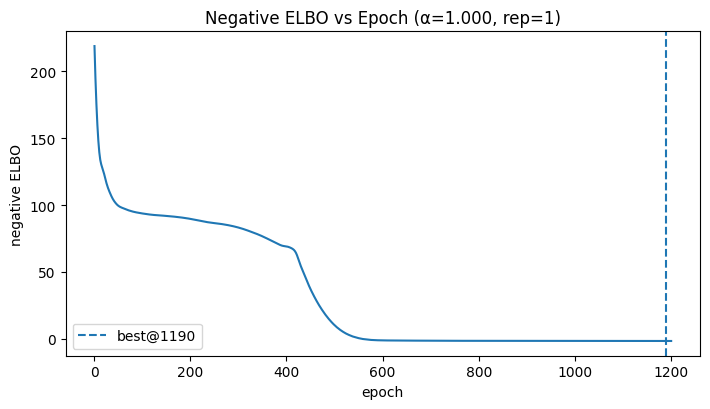

[21:15:03] [rep 001/20] α=0.800 | best -ELBO=-1.527260 @epoch 1197 | MSE=0.000170 | Z-drift=0.0000 | ℓ=0.0953 σ²=2.5867


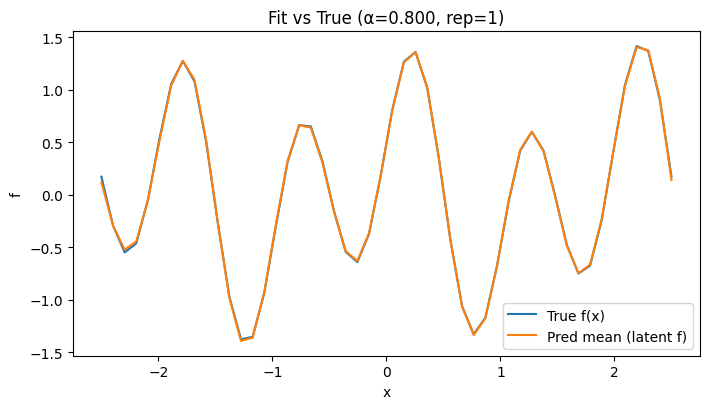

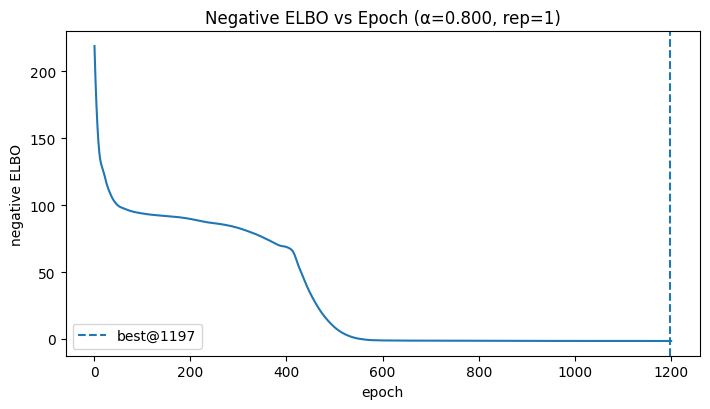

[21:15:24] [rep 001/20] α=0.600 | best -ELBO=-1.413056 @epoch 1189 | MSE=0.000155 | Z-drift=0.0000 | ℓ=0.0948 σ²=2.6578


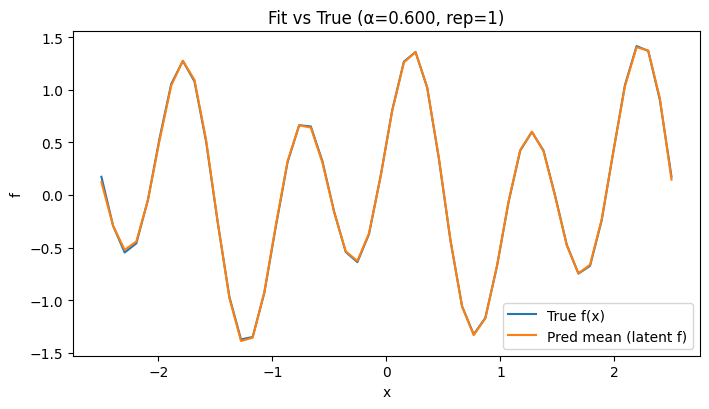

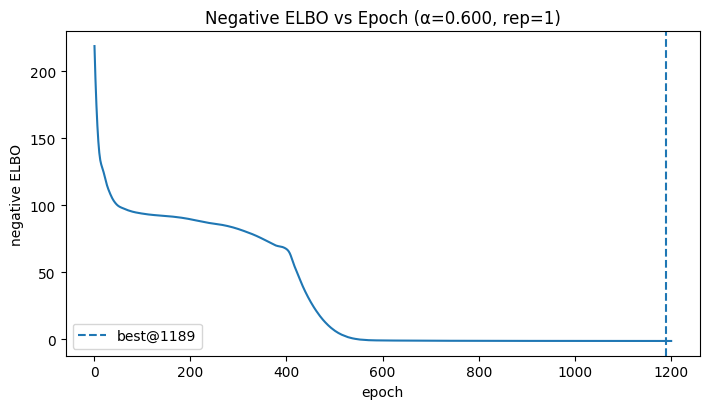

[21:15:45] [rep 001/20] α=0.500 | best -ELBO=-1.328564 @epoch 1198 | MSE=0.000137 | Z-drift=0.0000 | ℓ=0.0944 σ²=2.7137


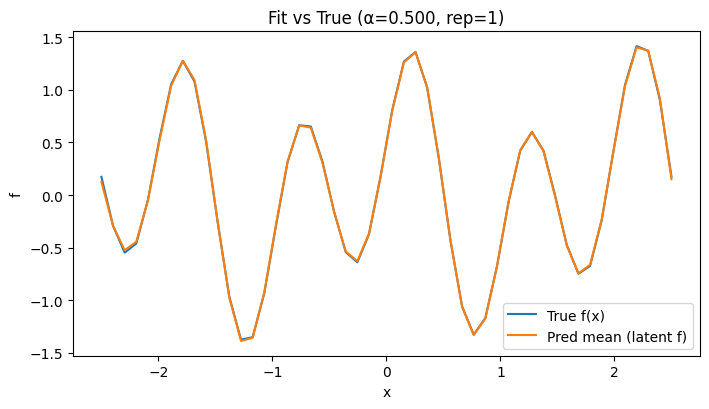

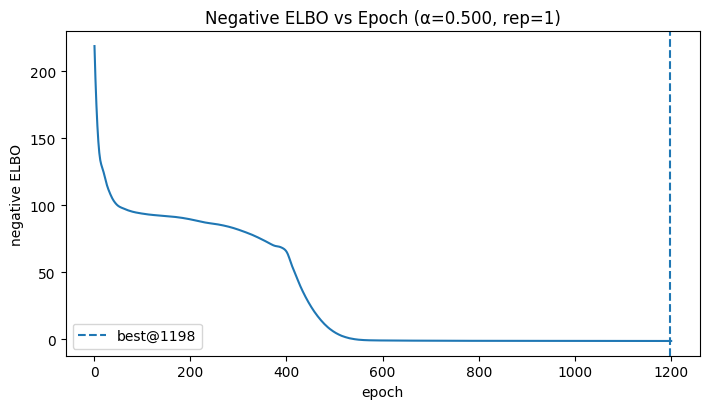

[21:16:06] [rep 001/20] α=0.300 | best -ELBO=-1.015136 @epoch 1196 | MSE=0.000100 | Z-drift=0.0000 | ℓ=0.0927 σ²=2.8913


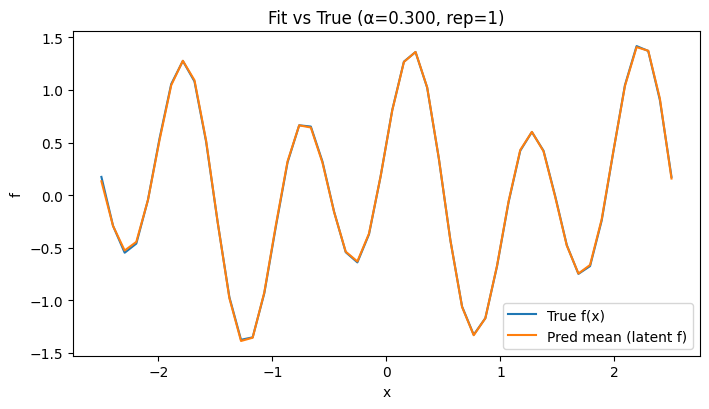

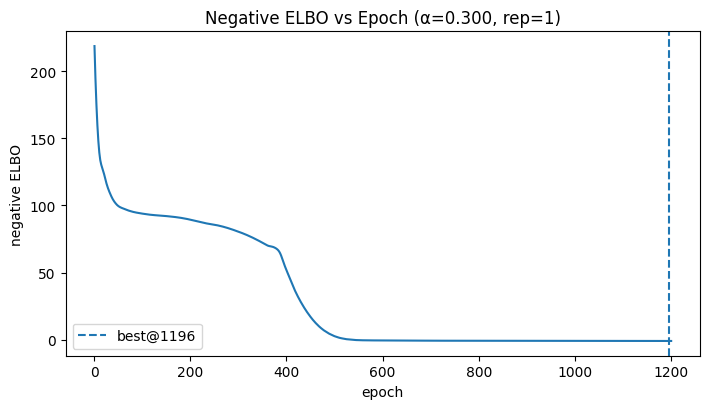

[21:16:26] [rep 001/20] α=0.100 | best -ELBO=0.214714 @epoch 1199 | MSE=0.000046 | Z-drift=0.0000 | ℓ=0.0852 σ²=3.2482


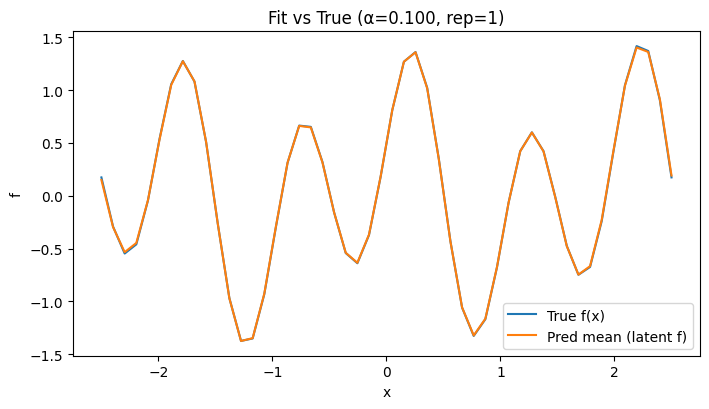

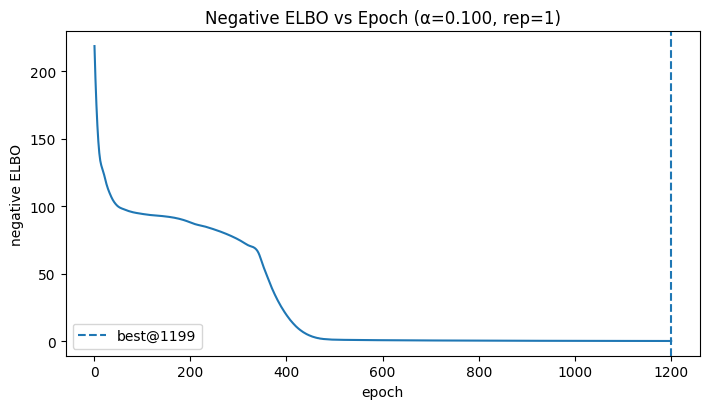

[21:16:47] [rep 001/20] α=0.001 | best -ELBO=65.232634 @epoch 1058 | MSE=0.056652 | Z-drift=0.0000 | ℓ=0.0458 σ²=0.5296


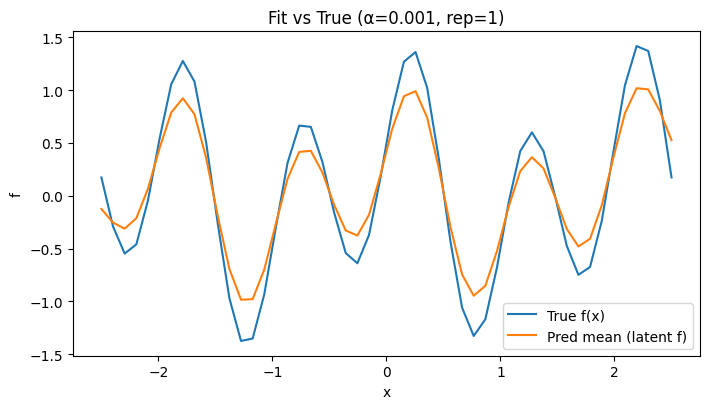

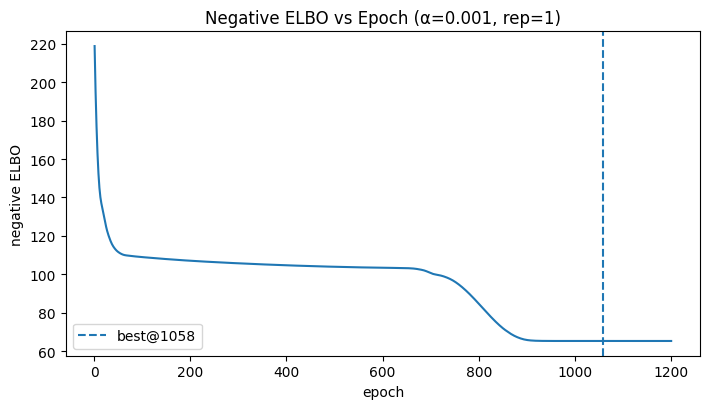

[21:16:47] [rep 001/20] coverage mean by α -> α=1.000:1.000 | α=0.800:1.000 | α=0.600:1.000 | α=0.500:1.000 | α=0.300:1.000 | α=0.100:1.000 | α=0.001:1.000
[21:16:47] 
===== Start rep 2/20 =====
[21:17:08] [rep 002/20] α=1.000 | best -ELBO=-1.600486 @epoch 1176 | MSE=0.000184 | Z-drift=0.0000 | ℓ=0.0956 σ²=2.5319
[21:17:28] [rep 002/20] α=0.800 | best -ELBO=-1.529068 @epoch 1186 | MSE=0.000166 | Z-drift=0.0000 | ℓ=0.0952 σ²=2.5791
[21:17:49] [rep 002/20] α=0.600 | best -ELBO=-1.414193 @epoch 1186 | MSE=0.000148 | Z-drift=0.0000 | ℓ=0.0948 σ²=2.6490
[21:18:09] [rep 002/20] α=0.500 | best -ELBO=-1.323434 @epoch 1167 | MSE=0.000147 | Z-drift=0.0000 | ℓ=0.0944 σ²=2.6966
[21:18:29] [rep 002/20] α=0.300 | best -ELBO=-1.017216 @epoch 1190 | MSE=0.000098 | Z-drift=0.0000 | ℓ=0.0927 σ²=2.8821
[21:18:43] [rep 002/20] α=0.100 | best -ELBO=0.212736 @epoch 1199 | MSE=0.000047 | Z-drift=0.0000 | ℓ=0.0852 σ²=3.2447
[21:19:03] [rep 002/20] α=0.001 | best -ELBO=65.249257 @epoch 1185 | MSE=0.056630 | Z-

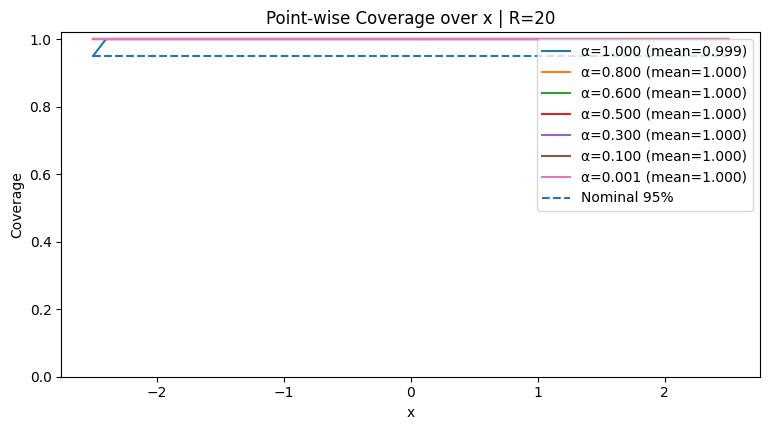

[22:00:50] 
=== Overall mean coverage (averaged over x) ===
[22:00:50]   alpha=1.000: mean coverage = 0.9990
[22:00:50]   alpha=0.800: mean coverage = 1.0000
[22:00:50]   alpha=0.600: mean coverage = 1.0000
[22:00:50]   alpha=0.500: mean coverage = 1.0000
[22:00:50]   alpha=0.300: mean coverage = 1.0000
[22:00:50]   alpha=0.100: mean coverage = 1.0000
[22:00:50]   alpha=0.001: mean coverage = 1.0000
[22:00:50] Saved indicator matrix with shape (7, 20, 50) to indicator_matrix.npy


In [1]:
# svgp_alpha_shakedown.py
# Latent-f only; multi-replications; alpha suite (shake-down)
# R=20, n_train=300, n_test=50, m=48, epochs<=1200, early stopping
# Features:
#   - learnable Z (same init across alphas, per replication)
#   - global input normalization [train_low,train_high] -> [0,1]
#   - deterministic flags
#   - full-batch training (no DataLoader randomness)
#   - fixed tiny likelihood noise; report Z-drift, hyperparams, MSE, best -ELBO
#   - per-replication summary line of mean coverage across x for each alpha

import os, math, time
from dataclasses import dataclass

import numpy as np
import torch
import gpytorch

# ----------------------------
# Determinism (set first)
# ----------------------------
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")
torch.use_deterministic_algorithms(True)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
# 想进一步提速可启用 TF32（冒烟时用，正式跑建议关）：
# torch.backends.cuda.matmul.allow_tf32 = True
# torch.backends.cudnn.allow_tf32 = True

def now(): return time.strftime("%H:%M:%S")
def log(msg): print(f"[{now()}] {msg}", flush=True)

# ----------------------------
# Config
# ----------------------------
@dataclass
class CFG:
    # data sizes
    n_train: int = 300
    n_test: int = 50

    # global design range (used for global normalization)
    train_low: float = -2.5
    train_high: float = 2.5
    test_low: float = -2.5
    test_high: float = 2.5

    # training
    use_fp64: bool = True
    epochs: int = 1200
    batch_size: int = 300      # full-batch (= n_train)
    inducing_points: int = 48
    lr_adam: float = 1e-2
    jitter: float = 3e-2
    seed: int = 42

    # early stopping
    early_stop_patience: int = 200
    early_stop_min_delta: float = 1e-4

    # experiment
    alphas: tuple = (1.0, 0.8, 0.6, 0.5, 0.3, 0.1, 0.001)
    replications: int = 20

    # plotting/logging
    log_every: int = 25
    show_plots: bool = True
    save_plots: bool = True

# ----------------------------
# Utilities
# ----------------------------
def f0(x: torch.Tensor) -> torch.Tensor:
    # true latent (noiseless)
    return torch.sin(2 * math.pi * x) + 0.5 * torch.cos(3 * x)

def make_stratified_points_1d(n, low, high, generator, device, dtype):
    # 1D LHS-like stratified sampling
    i = torch.arange(n, device=device, dtype=dtype)
    u = (i + torch.rand(n, generator=generator, device=device, dtype=dtype)) / n
    x = low + (high - low) * u
    perm = torch.randperm(n, generator=generator, device=device)
    return x[perm].unsqueeze(-1)

def map_global_to_unit_interval(x, low, high):
    return (x - low) / (high - low)

def cheb_lobatto_01(m, device, dtype):
    # Chebyshev-Lobatto nodes mapped to [0,1]
    k = torch.arange(m, device=device, dtype=dtype)
    x_m1_1 = -torch.cos(math.pi * k / (m - 1))  # [-1,1]
    return (x_m1_1 + 1.0) / 2.0                 # [0,1]

def clone_state_dict(sd):
    out = {}
    for k, v in sd.items():
        out[k] = v.detach().clone() if torch.is_tensor(v) else v
    return out

def hyper_summary(model):
    with torch.no_grad():
        ls = float(model.covar_module.base_kernel.lengthscale.mean())
        os = float(model.covar_module.outputscale)
    return ls, os

# ----------------------------
# Model  (no explicit whiten arg)
# ----------------------------
class SVGPModel(gpytorch.models.ApproximateGP):
    def __init__(self, inducing_points: torch.Tensor):
        M = inducing_points.size(0)
        q_dist = gpytorch.variational.CholeskyVariationalDistribution(M)
        # 你的 GPyTorch 版本里不传 whiten；保持 learn_inducing_locations=True
        q_strat = gpytorch.variational.VariationalStrategy(
            self,
            inducing_points,
            q_dist,
            learn_inducing_locations=True
        )
        super().__init__(q_strat)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel()
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

def init_hyper_and_q(model: SVGPModel, eps=1e-4):
    # Same init across alphas
    with torch.no_grad():
        model.mean_module.constant.zero_()
        model.covar_module.base_kernel.lengthscale.fill_(1.0)
        model.covar_module.outputscale.fill_(1.0)
        qdist = model.variational_strategy._variational_distribution
        qdist.variational_mean.zero_()
        L = torch.eye(qdist.chol_variational_covar.size(-1),
                      dtype=qdist.chol_variational_covar.dtype,
                      device=qdist.chol_variational_covar.device) * eps
        qdist.chol_variational_covar.copy_(L)

# ----------------------------
# Training (full-batch, early stopping)
# ----------------------------
def train_svgp_once(
    x_train_n, y_train, Z_init,
    lr, epochs, jitter,
    device, dtype, beta, log_every=25,
    early_stop_patience=200, early_stop_min_delta=1e-4,
):
    N = x_train_n.size(0)

    model = SVGPModel(Z_init.clone().contiguous()).to(device=device, dtype=dtype)
    init_hyper_and_q(model, eps=1e-4)
    likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device=device, dtype=dtype)
    with torch.no_grad():
        likelihood.noise = torch.as_tensor(3e-3, device=device, dtype=dtype)
    likelihood.noise_covar.raw_noise.requires_grad_(False)

    mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=N, beta=beta)

    # ==== FIX: no overlapping param groups — just optimize all model params ====
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    # （likelihood 噪声已冻结，不加入优化器）

    model.train(); likelihood.train()

    neg_elbo_hist = []
    best_loss = float("inf"); best_epoch = 0
    best_model_sd = clone_state_dict(model.state_dict())
    best_lik_sd = clone_state_dict(likelihood.state_dict())
    patience = 0

    with gpytorch.settings.cholesky_jitter(jitter), gpytorch.settings.fast_pred_var(True):
        for ep in range(1, epochs + 1):
            opt.zero_grad(set_to_none=True)
            out = model(x_train_n)              # full-batch (no shuffling)
            loss = -mll(out, y_train)
            if not torch.isfinite(loss):
                ls = float(model.covar_module.base_kernel.lengthscale.mean())
                os = float(model.covar_module.outputscale)
                raise RuntimeError(f"Non-finite loss at epoch {ep}! ℓ={ls:.3f}, σ²={os:.3f}")
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()

            cur = float(loss.item())
            neg_elbo_hist.append(cur)

            improved = (best_loss - cur) > early_stop_min_delta
            if improved:
                best_loss = cur; best_epoch = ep
                best_model_sd = clone_state_dict(model.state_dict())
                best_lik_sd = clone_state_dict(likelihood.state_dict())
                patience = 0
            else:
                patience += 1

            if (ep % log_every == 0) or ep == 1 or ep == epochs:
                pass  # 可改为打印每若干轮 -ELBO

            if patience >= early_stop_patience:
                break

    # restore best params
    model.load_state_dict(best_model_sd)
    likelihood.load_state_dict(best_lik_sd)
    model.eval(); likelihood.eval()

    # Z drift norm
    with torch.no_grad():
        Z_final = model.variational_strategy.inducing_points
        z_drift = torch.norm(Z_final - Z_init).item()

    return model, likelihood, neg_elbo_hist, best_epoch, best_loss, z_drift

# ----------------------------
# Main
# ----------------------------
def main():
    cfg = CFG()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    torch.set_default_dtype(torch.float64 if cfg.use_fp64 else torch.float32)
    torch.manual_seed(cfg.seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(cfg.seed)

    import matplotlib.pyplot as plt

    log(f"Device: {device} | dtype: {torch.get_default_dtype()}")

    # Fixed test grid (original scale) + global normalization to [0,1]
    x_test = torch.linspace(cfg.test_low, cfg.test_high, cfg.n_test,
                            device=device, dtype=torch.get_default_dtype()).unsqueeze(1)
    x_test_n = map_global_to_unit_interval(x_test, cfg.train_low, cfg.train_high)
    y_test_true = f0(x_test).squeeze(-1)
    J = cfg.n_test

    # storage for coverage indicators: [A, R, J]
    alphas = list(cfg.alphas)
    A = len(alphas)
    R = cfg.replications
    indicators = np.zeros((A, R, J), dtype=np.float64)

    rep_to_plot = 0  # only plot detailed figures for the first replication

    for r in range(R):
        log(f"\n===== Start rep {r+1}/{R} =====")
        gen = torch.Generator(device=device).manual_seed(cfg.seed + r)

        # Training design in original scale, then map globally to [0,1]
        x_train = make_stratified_points_1d(
            n=cfg.n_train, low=cfg.train_low, high=cfg.train_high,
            generator=gen, device=device, dtype=torch.get_default_dtype()
        )
        y_train = f0(x_train).squeeze(-1)

        x_tr_n = map_global_to_unit_interval(x_train, cfg.train_low, cfg.train_high)

        # Z_init in [0,1] (same for all alphas within this replication)
        Z_init = cheb_lobatto_01(cfg.inducing_points, device, torch.get_default_dtype()).unsqueeze(-1).contiguous()

        for a_idx, alpha in enumerate(alphas):
            beta = 1.0 / alpha

            model, likelihood, neg_elbo_hist, best_epoch, best_loss, z_drift = train_svgp_once(
                x_train_n=x_tr_n, y_train=y_train,
                Z_init=Z_init,
                lr=cfg.lr_adam, epochs=cfg.epochs, jitter=cfg.jitter,
                device=device, dtype=torch.get_default_dtype(),
                beta=beta, log_every=cfg.log_every,
                early_stop_patience=cfg.early_stop_patience,
                early_stop_min_delta=cfg.early_stop_min_delta
            )

            with torch.no_grad():
                pred_f = model(x_test_n)
                mu = pred_f.mean
                var = pred_f.variance
                std = torch.sqrt(var).clamp_min(1e-12)
                f_true = y_test_true
                lower = mu - 1.96 * std
                upper = mu + 1.96 * std
                cover = ((f_true >= lower) & (f_true <= upper)).to(torch.float64)
                indicators[a_idx, r, :] = cover.cpu().numpy()
                mse = torch.mean((mu - f_true)**2).item()

            ls, os = hyper_summary(model)
            log(f"[rep {r+1:03d}/{R}] α={alpha:.3f} | best -ELBO={best_loss:.6f} @epoch {best_epoch} "
                f"| MSE={mse:.6f} | Z-drift={z_drift:.4f} | ℓ={ls:.4f} σ²={os:.4f}")

            # Representative plots only for the first replication
            if r == rep_to_plot:
                # Fit vs True
                plt.figure(figsize=(7.2, 4.2))
                plt.plot(x_test.squeeze(-1).cpu(), y_test_true.cpu().numpy(), label="True f(x)")
                plt.plot(x_test.squeeze(-1).cpu(), mu.cpu().numpy(), label="Pred mean (latent f)")
                plt.title(f"Fit vs True (α={alpha:.3f}, rep={r+1})")
                plt.xlabel("x"); plt.ylabel("f"); plt.legend(); plt.tight_layout()
                if cfg.save_plots:
                    plt.savefig(f"fit_vs_true_alpha{alpha:.3f}_rep{r+1}.png".replace("/", ""), dpi=150)
                if cfg.show_plots: plt.show()
                else: plt.close()

                # -ELBO curve
                plt.figure(figsize=(7.2, 4.2))
                plt.plot(range(1, len(neg_elbo_hist)+1), neg_elbo_hist)
                plt.axvline(best_epoch, linestyle="--", label=f"best@{best_epoch}")
                plt.title(f"Negative ELBO vs Epoch (α={alpha:.3f}, rep={r+1})")
                plt.xlabel("epoch"); plt.ylabel("negative ELBO"); plt.legend(); plt.tight_layout()
                if cfg.save_plots:
                    plt.savefig(f"neg_elbo_curve_alpha{alpha:.3f}_rep{r+1}.png".replace("/", ""), dpi=150)
                if cfg.show_plots: plt.show()
                else: plt.close()

        # Per-replication coverage summary across alphas (mean over x)
        mean_cov_this_rep = indicators[:, r, :].mean(axis=1)
        rep_line = " | ".join([f"α={a:.3f}:{mc:.3f}" for a, mc in zip(alphas, mean_cov_this_rep)])
        log(f"[rep {r+1:03d}/{R}] coverage mean by α -> {rep_line}")

    # =========================
    # Point-wise coverage: average across replications per alpha
    # =========================
    x_axis = x_test.squeeze(-1).cpu().numpy()
    coverage_curves = indicators.mean(axis=1)     # [A, J]
    overall_cov = coverage_curves.mean(axis=1)    # [A]

    import matplotlib.pyplot as plt
    plt.figure(figsize=(7.8, 4.4))
    for a_idx, alpha in enumerate(alphas):
        plt.plot(x_axis, coverage_curves[a_idx], label=f"α={alpha:.3f} (mean={overall_cov[a_idx]:.3f})")
    plt.hlines(0.95, x_axis.min(), x_axis.max(), linestyles="--", label="Nominal 95%")
    plt.ylim(0.0, 1.02)
    plt.title(f"Point-wise Coverage over x | R={R}")
    plt.xlabel("x"); plt.ylabel("Coverage"); plt.legend(); plt.tight_layout()
    if cfg.save_plots:
        plt.savefig(f"coverage_curves_R{R}.png", dpi=150)
    if cfg.show_plots:
        plt.show()
    else:
        plt.close()

    log("\n=== Overall mean coverage (averaged over x) ===")
    for a_idx, alpha in enumerate(alphas):
        log(f"  alpha={alpha:.3f}: mean coverage = {overall_cov[a_idx]:.4f}")

    np.save("indicator_matrix.npy", indicators)
    log(f"Saved indicator matrix with shape {indicators.shape} to indicator_matrix.npy")

if __name__ == "__main__":
    main()


[init] device=cuda | dtype=torch.float64 | train/test=(500/50) | Z=50
[α=1.000 | rep 001/50] -ELBO(last)= 90.906828 | MSE=5.545925e-01
[α=1.000 | rep 002/50] -ELBO(last)= 90.906133 | MSE=5.546053e-01
[α=1.000 | rep 003/50] -ELBO(last)= 90.906117 | MSE=5.546042e-01
[α=1.000 | rep 004/50] -ELBO(last)= 90.906549 | MSE=5.546042e-01
[α=1.000 | rep 005/50] -ELBO(last)= 90.906135 | MSE=5.546054e-01
[α=1.000 | rep 006/50] -ELBO(last)= 90.906392 | MSE=5.546040e-01
[α=1.000 | rep 007/50] -ELBO(last)= 90.906520 | MSE=5.546787e-01
[α=1.000 | rep 008/50] -ELBO(last)= 90.906351 | MSE=5.546103e-01
[α=1.000 | rep 009/50] -ELBO(last)= 90.906078 | MSE=5.546053e-01
[α=1.000 | rep 010/50] -ELBO(last)= 90.906817 | MSE=5.546059e-01
[α=1.000 | rep 011/50] -ELBO(last)= 90.906145 | MSE=5.546045e-01
[α=1.000 | rep 012/50] -ELBO(last)= 90.907482 | MSE=5.546042e-01
[α=1.000 | rep 013/50] -ELBO(last)= 90.909582 | MSE=5.545958e-01
[α=1.000 | rep 014/50] -ELBO(last)= 90.906377 | MSE=5.546041e-01
[α=1.000 | rep 015/5

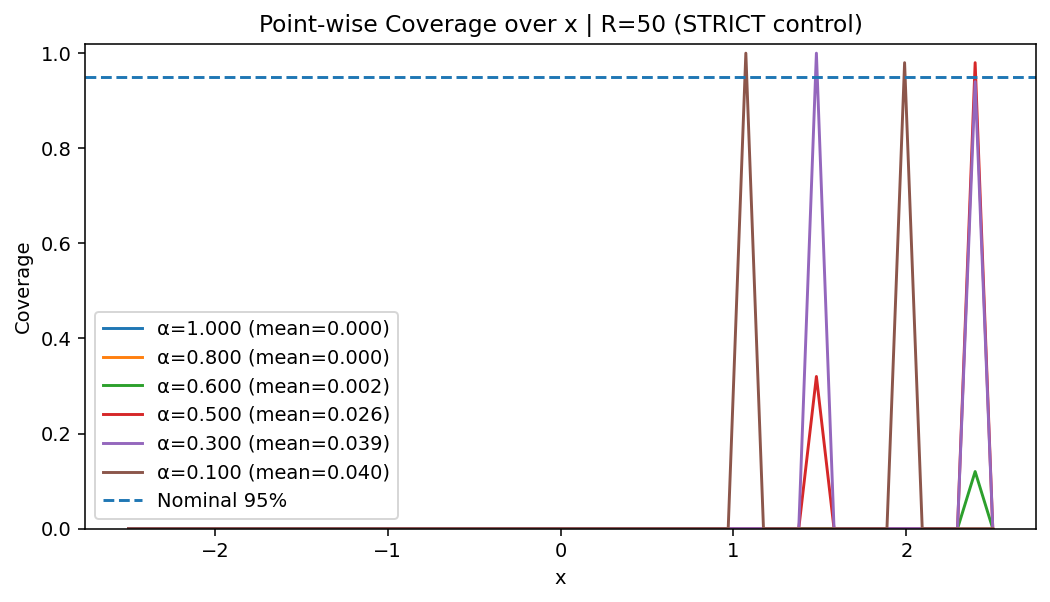

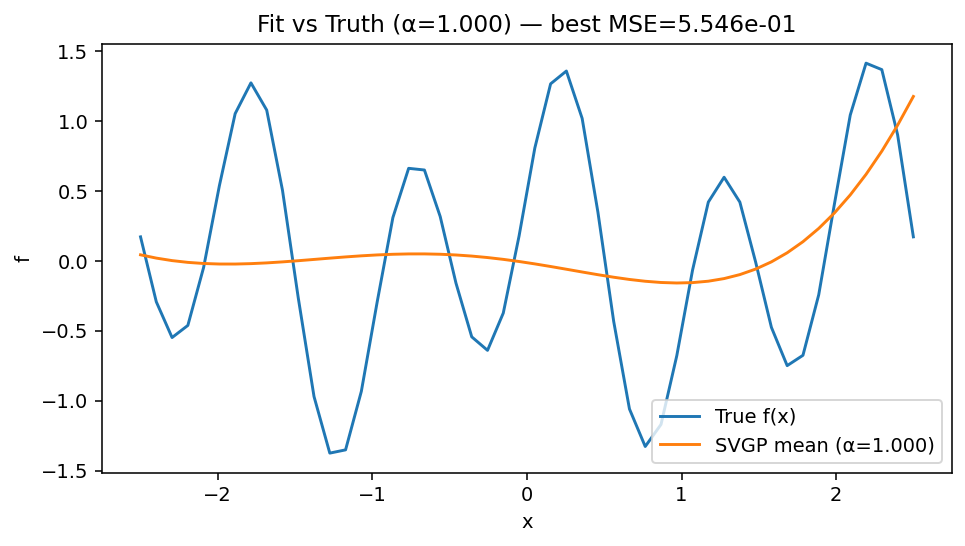

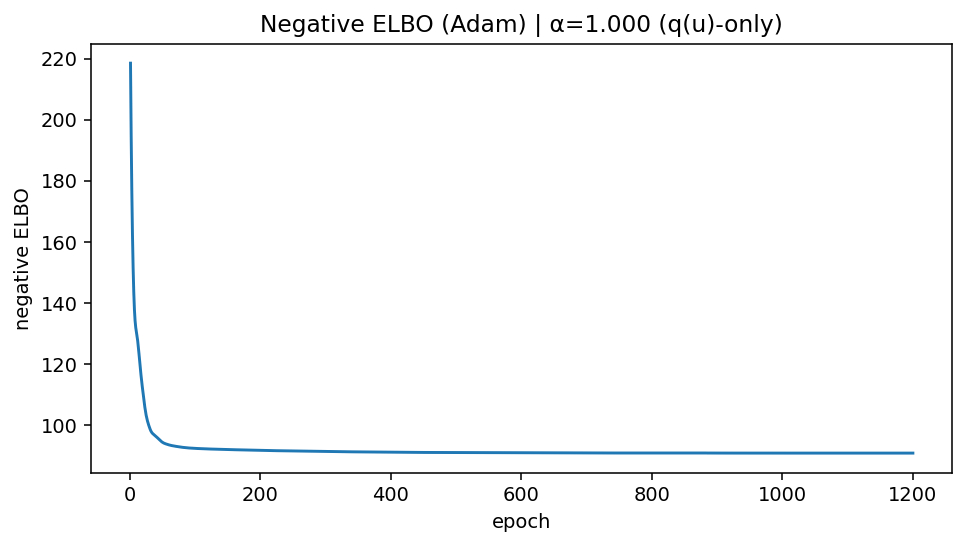

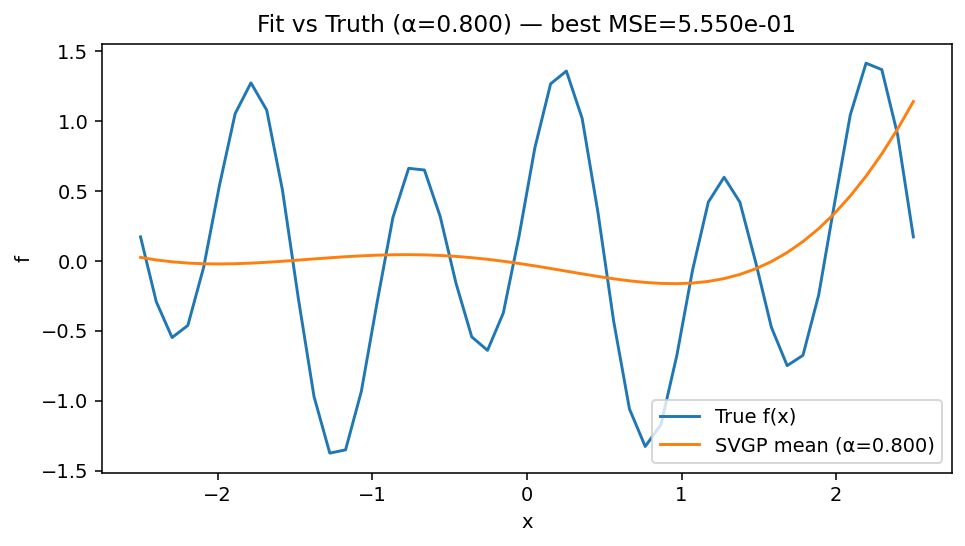

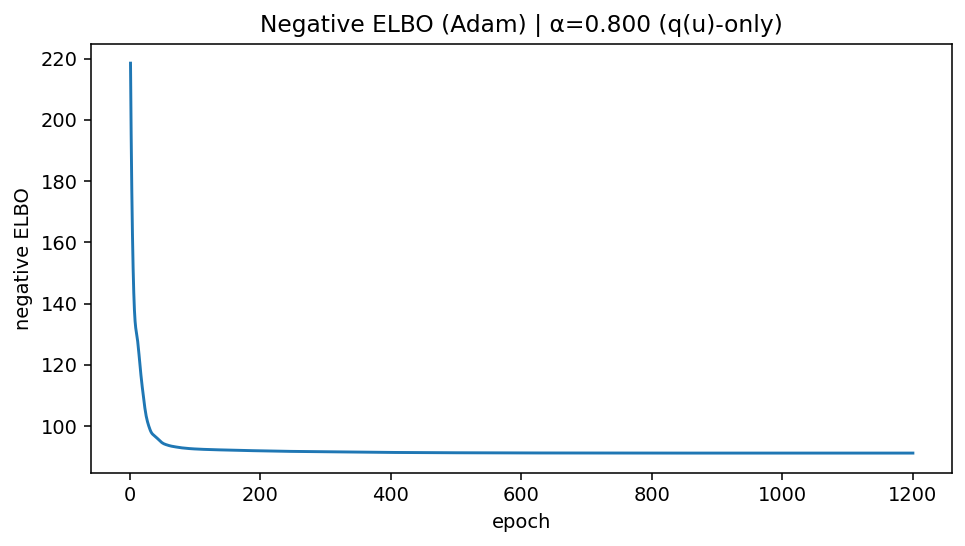

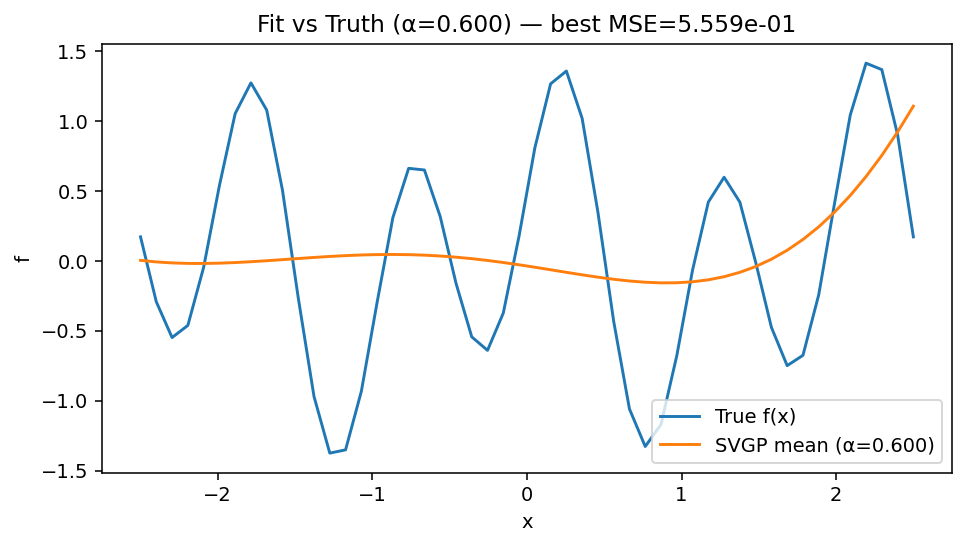

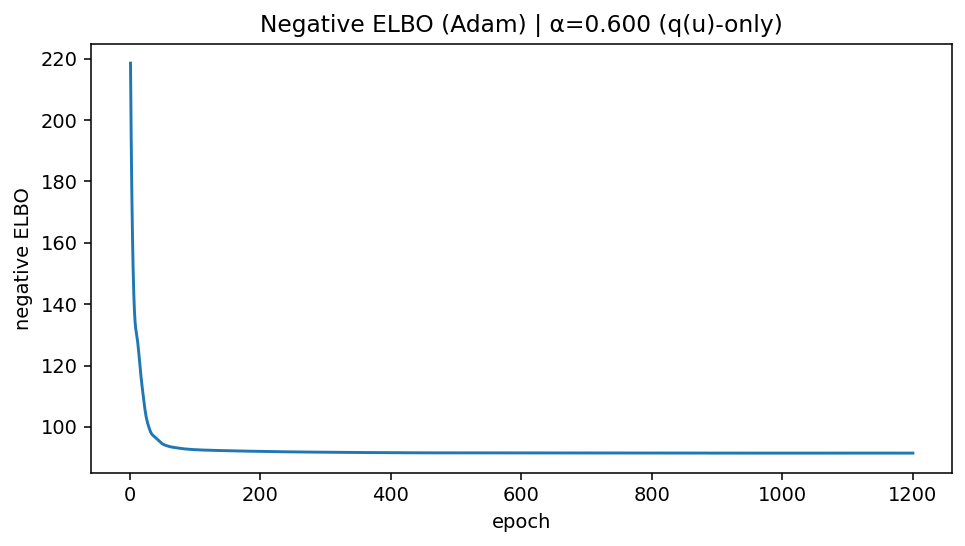

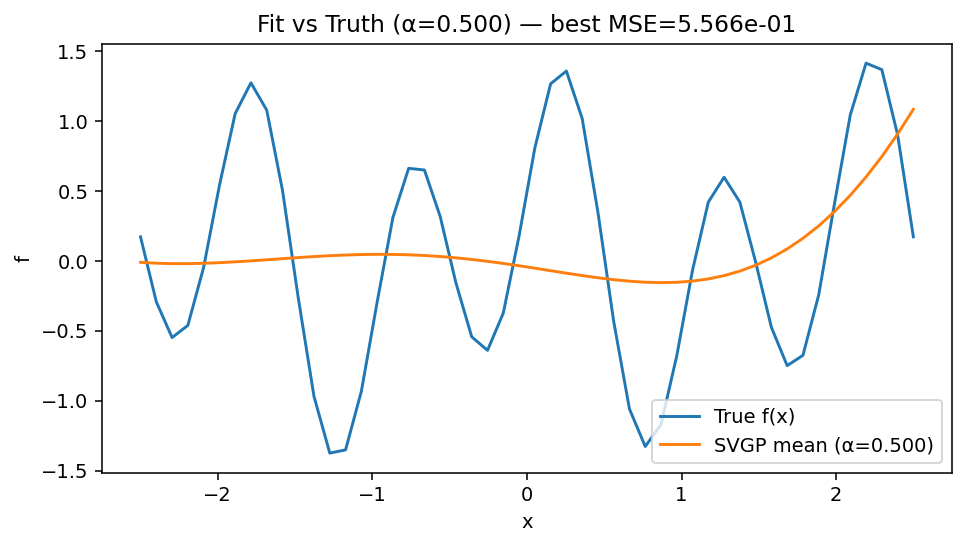

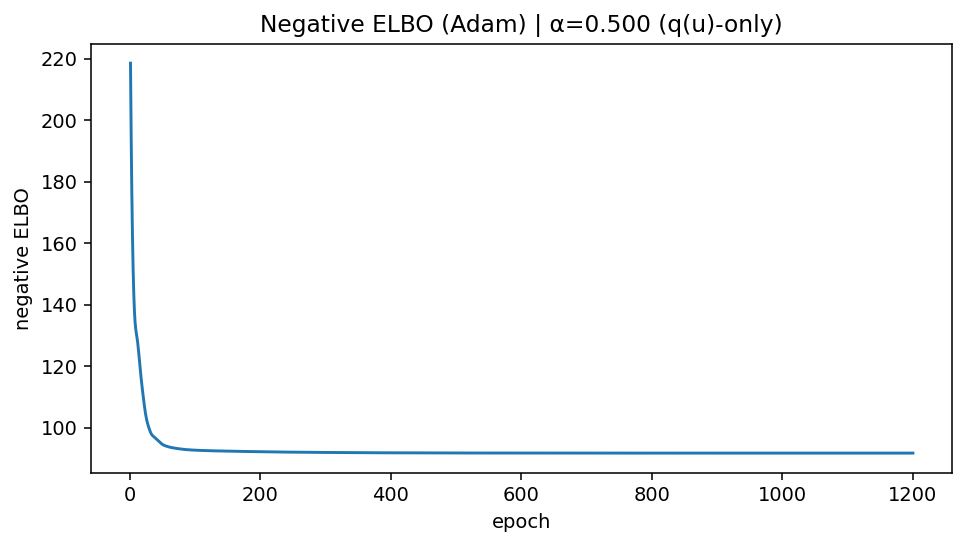

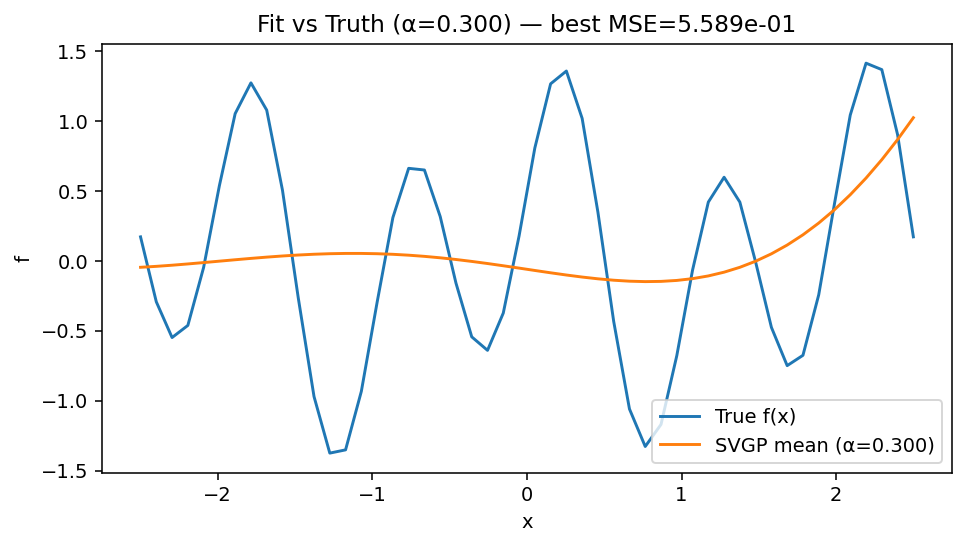

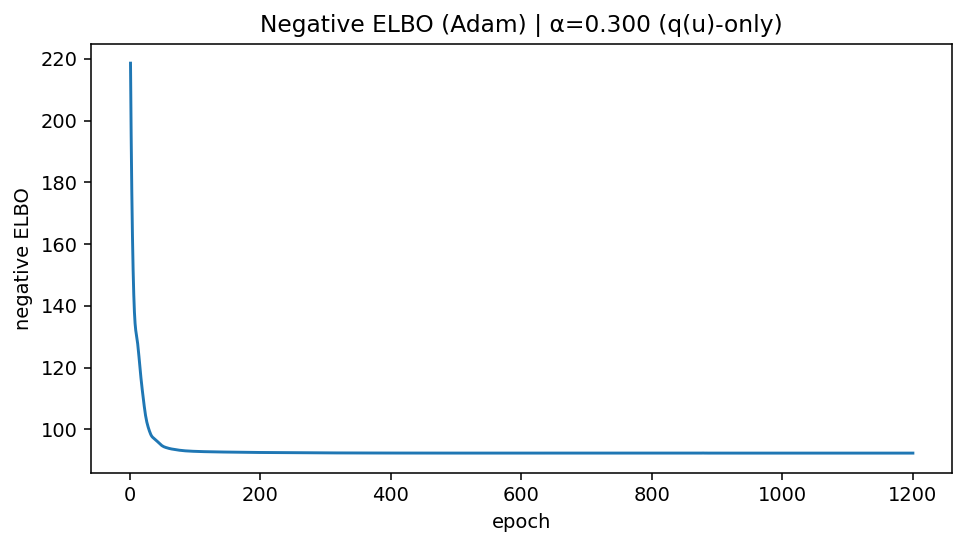

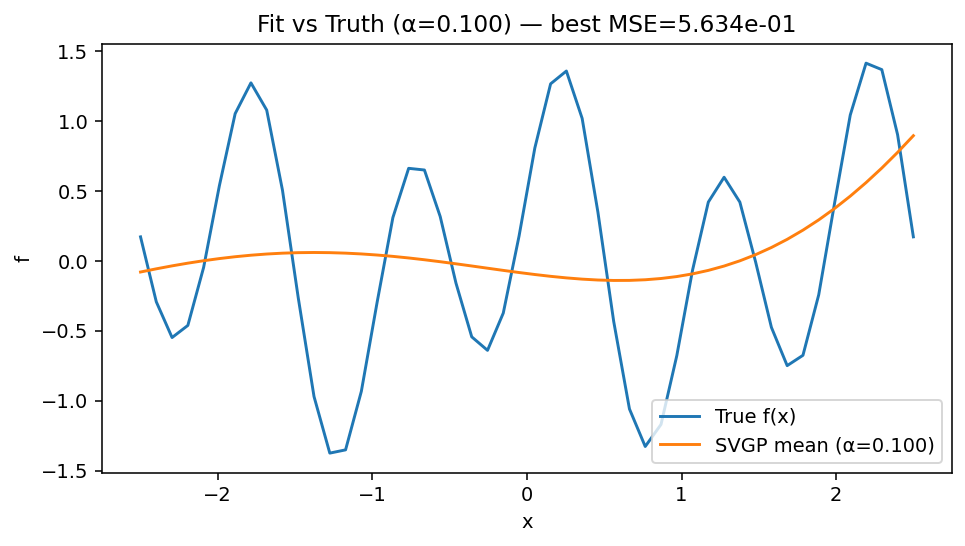

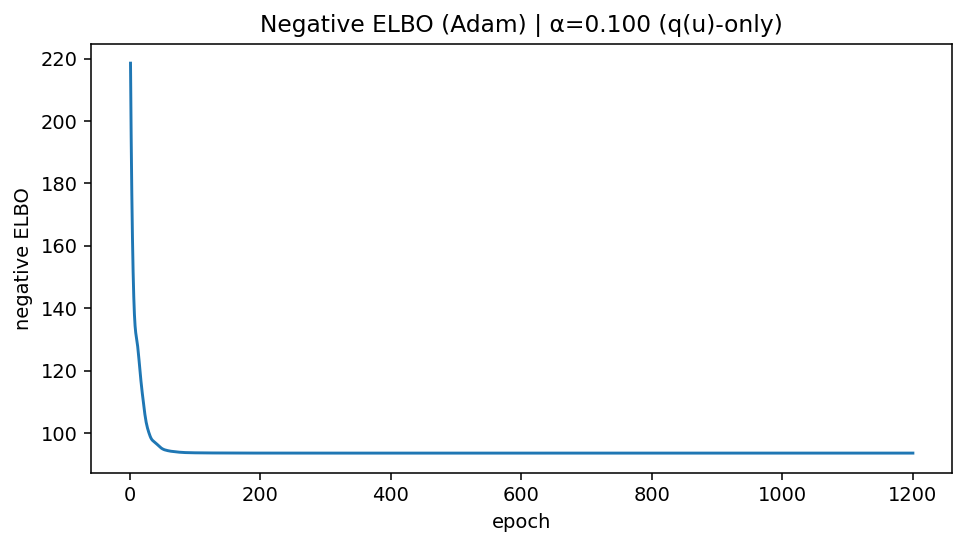


=== MSE summary over reps (STRICT control) ===
α=1.000 | MSE mean=5.546037e-01 | std=1.596413e-05 | min=5.545601e-01 | max=5.546787e-01
α=0.800 | MSE mean=5.551779e-01 | std=7.800319e-05 | min=5.549606e-01 | max=5.555365e-01
α=0.600 | MSE mean=5.560728e-01 | std=2.591566e-05 | min=5.559128e-01 | max=5.561127e-01
α=0.500 | MSE mean=5.567625e-01 | std=6.763688e-05 | min=5.565998e-01 | max=5.571742e-01
α=0.300 | MSE mean=5.589450e-01 | std=5.295950e-05 | min=5.588515e-01 | max=5.592472e-01
α=0.100 | MSE mean=5.634536e-01 | std=1.929289e-05 | min=5.633586e-01 | max=5.635346e-01


In [2]:
# === Step 0: SVGP point-wise coverage under STRICT control (latent-f only) ===
# 目标：只让 α 变化，其它一律固定；验证 coverage 是否随 α 呈单调（通常 α↓ -> 区间变窄 -> 覆盖下降）
#
# 固定内容：
#  - 训练/测试集（一次生成，之后全程复用）
#  - 归一化（全局线性映射到 [0,1]）
#  - 诱导点 Z（Chebyshev-Lobatto in [0,1]，learn_inducing_locations=False）
#  - RBF 超参（lengthscale, outputscale），均冻结
#  - 均值项、likelihood 噪声，均冻结
# 训练：仅更新 q(u)（变分参数）；每个 α 做 R 次重复（仅初始化不同）
#
import math, time
from dataclasses import dataclass

import torch, gpytorch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

plt.rcParams["figure.dpi"] = 140
torch.set_default_dtype(torch.float64)

# ---------------- Config ----------------
@dataclass
class CFG:
    # α 列表（β=1/α）
    alphas: list = (1.0, 0.8, 0.6, 0.5, 0.3, 0.1)

    # 重复次数（只变 q(u) 初始化）
    reps: int = 50

    # 数据区间与规模
    n_train: int = 500
    n_test: int = 50
    train_low: float = -2.5
    train_high: float =  2.5
    test_low: float  = -2.5
    test_high: float =  2.5

    # 诱导点与核
    m_inducing: int = 50
    fixed_lengthscale: float = 0.12   # 在 [0,1] 归一化尺度下
    fixed_outputscale: float = 0.6    # σ^2
    fixed_noise: float = 3e-3         # 仅用于 ELBO 中的 lik；覆盖评估不用到噪声

    # 训练
    lr: float = 2e-2
    epochs: int = 1200
    batch_size: int = 500  # 全量即可

    # 数值
    jitter: float = 3e-2
    seed: int = 123
    nominal_p: float = 0.95

cfg = CFG()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(cfg.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.seed)

# ---------------- Toy truth ----------------
def f0(x: torch.Tensor) -> torch.Tensor:
    return torch.sin(2 * math.pi * x) + 0.5 * torch.cos(3 * x)

# ---------------- Utils ----------------
def make_lhs_1d(n, low, high, gen, device, dtype):
    """一次性 LHS，后续所有 α/rep 都用这同一批训练点。"""
    i = torch.arange(n, device=device, dtype=dtype)
    u = (i + torch.rand(n, generator=gen, device=device, dtype=dtype)) / n
    x = low + (high - low) * u
    perm = torch.randperm(n, generator=gen, device=device)
    return x[perm].unsqueeze(-1)

def cheb_lobatto_01(m, device, dtype):
    """Chebyshev-Lobatto 节点（含端点）映射到 [0,1]"""
    # x_k = 0.5 * (1 - cos(pi * k/(m-1)))
    k = torch.arange(m, device=device, dtype=dtype)
    return 0.5 * (1.0 - torch.cos(math.pi * k / (m - 1))).unsqueeze(-1)

def clone_sd(sd):
    out = {}
    for k, v in sd.items():
        out[k] = v.detach().clone() if torch.is_tensor(v) else v
    return out

# ---------------- Model ----------------
class SVGP_FixedKernel(gpytorch.models.ApproximateGP):
    def __init__(self, Z_fixed_01, lengthscale, outputscale):
        # 固定 Z，且不学习位置
        q_dist = gpytorch.variational.CholeskyVariationalDistribution(Z_fixed_01.size(0))
        strat = gpytorch.variational.VariationalStrategy(
            self, Z_fixed_01, q_dist, learn_inducing_locations=False
        )
        super().__init__(strat)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

        # 设定并冻结核超参
        with torch.no_grad():
            self.covar_module.base_kernel.lengthscale.fill_(lengthscale)
            self.covar_module.outputscale.fill_(outputscale)
            # 冻结 raw 参数
            self.covar_module.base_kernel.raw_lengthscale.requires_grad_(False)
            self.covar_module.raw_outputscale.requires_grad_(False)

        # 冻结均值常数（避免 α 间出现额外自由度）
        self.mean_module.initialize(constant=0.0)
        for p in self.mean_module.parameters():
            p.requires_grad = False

    def forward(self, x01):
        mean_x = self.mean_module(x01)
        covar_x = self.covar_module(x01)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# ---------------- Data: 一次性生成并固定 ----------------
gen0 = torch.Generator(device=device).manual_seed(cfg.seed + 2024)
x_tr = make_lhs_1d(cfg.n_train, cfg.train_low, cfg.train_high, gen0, device, torch.get_default_dtype())
y_tr = f0(x_tr).squeeze(-1)

# 固定的测试网格（同一套）
x_te = torch.linspace(cfg.test_low, cfg.test_high, cfg.n_test, device=device).unsqueeze(-1)
y_true = f0(x_te).squeeze(-1)

# 全局线性归一化到 [0,1]（非 z-score）
def to01(x):
    return (x - cfg.train_low) / (cfg.train_high - cfg.train_low)

x_tr_01 = to01(x_tr)
x_te_01 = to01(x_te)

# 固定 Z：Chebyshev-Lobatto in [0,1]
Z_fixed = cheb_lobatto_01(cfg.m_inducing, device, torch.get_default_dtype())

# 训练 loader（全量批）
loader = DataLoader(TensorDataset(x_tr_01, y_tr), batch_size=cfg.batch_size, shuffle=True, drop_last=False)

print(f"[init] device={device} | dtype={torch.get_default_dtype()} | "
      f"train/test=({cfg.n_train}/{cfg.n_test}) | Z={cfg.m_inducing}", flush=True)

# ---------------- Coverage storage ----------------
J = cfg.n_test
cover_curves = {}          # α -> (J,) 覆盖率
rep_mse_stats = {}         # α -> [R] 的 MSE
rep_best_records = {}      # α -> 代表性结果（min-MSE）

z975 = 1.959963984540054  # 95% 双侧

# ---------------- Main: α 循环（严格控变量） ----------------
for ALPHA in cfg.alphas:
    beta = 1.0 / ALPHA

    hits_mat = torch.zeros(cfg.reps, J, device="cpu", dtype=torch.float64)
    mses = []
    rep_best = {"mse": float("inf"), "mu": None, "elbo_hist": None}

    for r in range(1, cfg.reps + 1):
        # 每个重复只改 q(u) 的初始化（通过不同随机种子实现）
        seed_r = cfg.seed + 1000 * r + int(100 * ALPHA)
        torch.manual_seed(seed_r)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed_r)

        # 模型与似然（核与 Z 固定）
        model = SVGP_FixedKernel(Z_fixed, cfg.fixed_lengthscale, cfg.fixed_outputscale).to(device)
        lik = gpytorch.likelihoods.GaussianLikelihood().to(device)
        with torch.no_grad():
            lik.noise = torch.as_tensor(cfg.fixed_noise, device=device, dtype=torch.get_default_dtype())
        lik.noise_covar.raw_noise.requires_grad_(False)

        # 只优化变分参数（q(u)）
        params = [{'params': model.variational_parameters()}]
        opt = torch.optim.Adam(params, lr=cfg.lr)

        mll = gpytorch.mlls.VariationalELBO(lik, model, num_data=cfg.n_train, beta=beta)

        # 训练（固定 epoch；无早停）
        elbo_hist = []
        model.train(); lik.train()
        with gpytorch.settings.cholesky_jitter(cfg.jitter):
            for ep in range(1, cfg.epochs + 1):
                total = 0.0
                for xb, yb in loader:
                    opt.zero_grad(set_to_none=True)
                    out = model(xb)
                    loss = -mll(out, yb)
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                    opt.step()
                    total += float(loss.item())
                elbo_hist.append(total)

        # 评估（latent f）
        model.eval(); lik.eval()
        with torch.no_grad():
            pred_f = model(x_te_01)
            mu, sd = pred_f.mean, pred_f.stddev.clamp_min(1e-12)
            mse = torch.mean((mu - y_true)**2).item()

            lo, hi = mu - z975 * sd, mu + z975 * sd
            hits = ((y_true >= lo) & (y_true <= hi)).to(torch.float64).cpu()
            hits_mat[r-1, :] = hits

        mses.append(mse)
        # 可选：逐重复简洁打印
        print(f"[α={ALPHA:>4.3f} | rep {r:03d}/{cfg.reps}] -ELBO(last)={elbo_hist[-1]:>10.6f} | MSE={mse:>10.6e}",
              flush=True)

        if mse < rep_best["mse"]:
            rep_best.update({"mse": mse, "mu": mu.detach().cpu(), "elbo_hist": elbo_hist})

    cover = hits_mat.mean(dim=0).numpy()  # 按列平均得到 x 上的点态覆盖
    cover_curves[ALPHA] = cover
    rep_mse_stats[ALPHA] = mses
    rep_best_records[ALPHA] = rep_best

# ---------------- Plots ----------------
x_cpu = x_te.squeeze(-1).cpu().numpy()

# 1) 覆盖率曲线（所有 α）
plt.figure(figsize=(7.6, 4.4))
for a in cfg.alphas:
    c = cover_curves[a]
    plt.plot(x_cpu, c, label=f"α={a:.3f} (mean={c.mean():.3f})")
plt.axhline(cfg.nominal_p, linestyle="--", label=f"Nominal {int(cfg.nominal_p*100)}%")
plt.ylim(0.0, 1.02)
plt.xlabel("x"); plt.ylabel("Coverage")
plt.title(f"Point-wise Coverage over x | R={cfg.reps} (STRICT control)")
plt.legend()
plt.tight_layout(); plt.show()

# 2) 每个 α：代表性 fit 与 -ELBO
for a in cfg.alphas:
    rec = rep_best_records[a]
    mu_best = rec["mu"]

    plt.figure(figsize=(7.0, 4.0))
    plt.plot(x_cpu, f0(x_te).cpu().numpy(), label="True f(x)")
    plt.plot(x_cpu, mu_best.numpy(), label=f"SVGP mean (α={a:.3f})")
    plt.title(f"Fit vs Truth (α={a:.3f}) — best MSE={rec['mse']:.3e}")
    plt.xlabel("x"); plt.ylabel("f"); plt.legend(); plt.tight_layout(); plt.show()

    plt.figure(figsize=(7.0, 4.0))
    plt.plot(range(1, len(rec["elbo_hist"])+1), rec["elbo_hist"])
    plt.title(f"Negative ELBO (Adam) | α={a:.3f} (q(u)-only)")
    plt.xlabel("epoch"); plt.ylabel("negative ELBO"); plt.tight_layout(); plt.show()

# 3) 数值汇总
print("\n=== MSE summary over reps (STRICT control) ===")
for a in cfg.alphas:
    arr = torch.tensor(rep_mse_stats[a])
    print(f"α={a:>5.3f} | MSE mean={arr.mean().item():.6e} | std={arr.std(unbiased=False).item():.6e} "
          f"| min={arr.min().item():.6e} | max={arr.max().item():.6e}")


[init] device=cuda | dtype=torch.float64 | train/test=(500/50) | m(Z)=50 | R=100
[diag α=1.000] mean(var_f)=4.960824e-03 | ls=0.4161 os=1.3466 | sigma2(train)=0.0878 | latent_only=True
[diag α=0.800] mean(var_f)=5.823521e-03 | ls=0.4115 os=1.3583 | sigma2(train)=0.0883 | latent_only=True
[diag α=0.600] mean(var_f)=7.250857e-03 | ls=0.4043 os=1.3738 | sigma2(train)=0.0889 | latent_only=True
[diag α=0.500] mean(var_f)=8.387588e-03 | ls=0.3991 os=1.3829 | sigma2(train)=0.0894 | latent_only=True
[diag α=0.300] mean(var_f)=1.301122e-02 | ls=0.3818 os=1.4037 | sigma2(train)=0.0923 | latent_only=True
[diag α=0.100] mean(var_f)=3.870307e-02 | ls=0.3314 os=1.3292 | sigma2(train)=0.1090 | latent_only=True


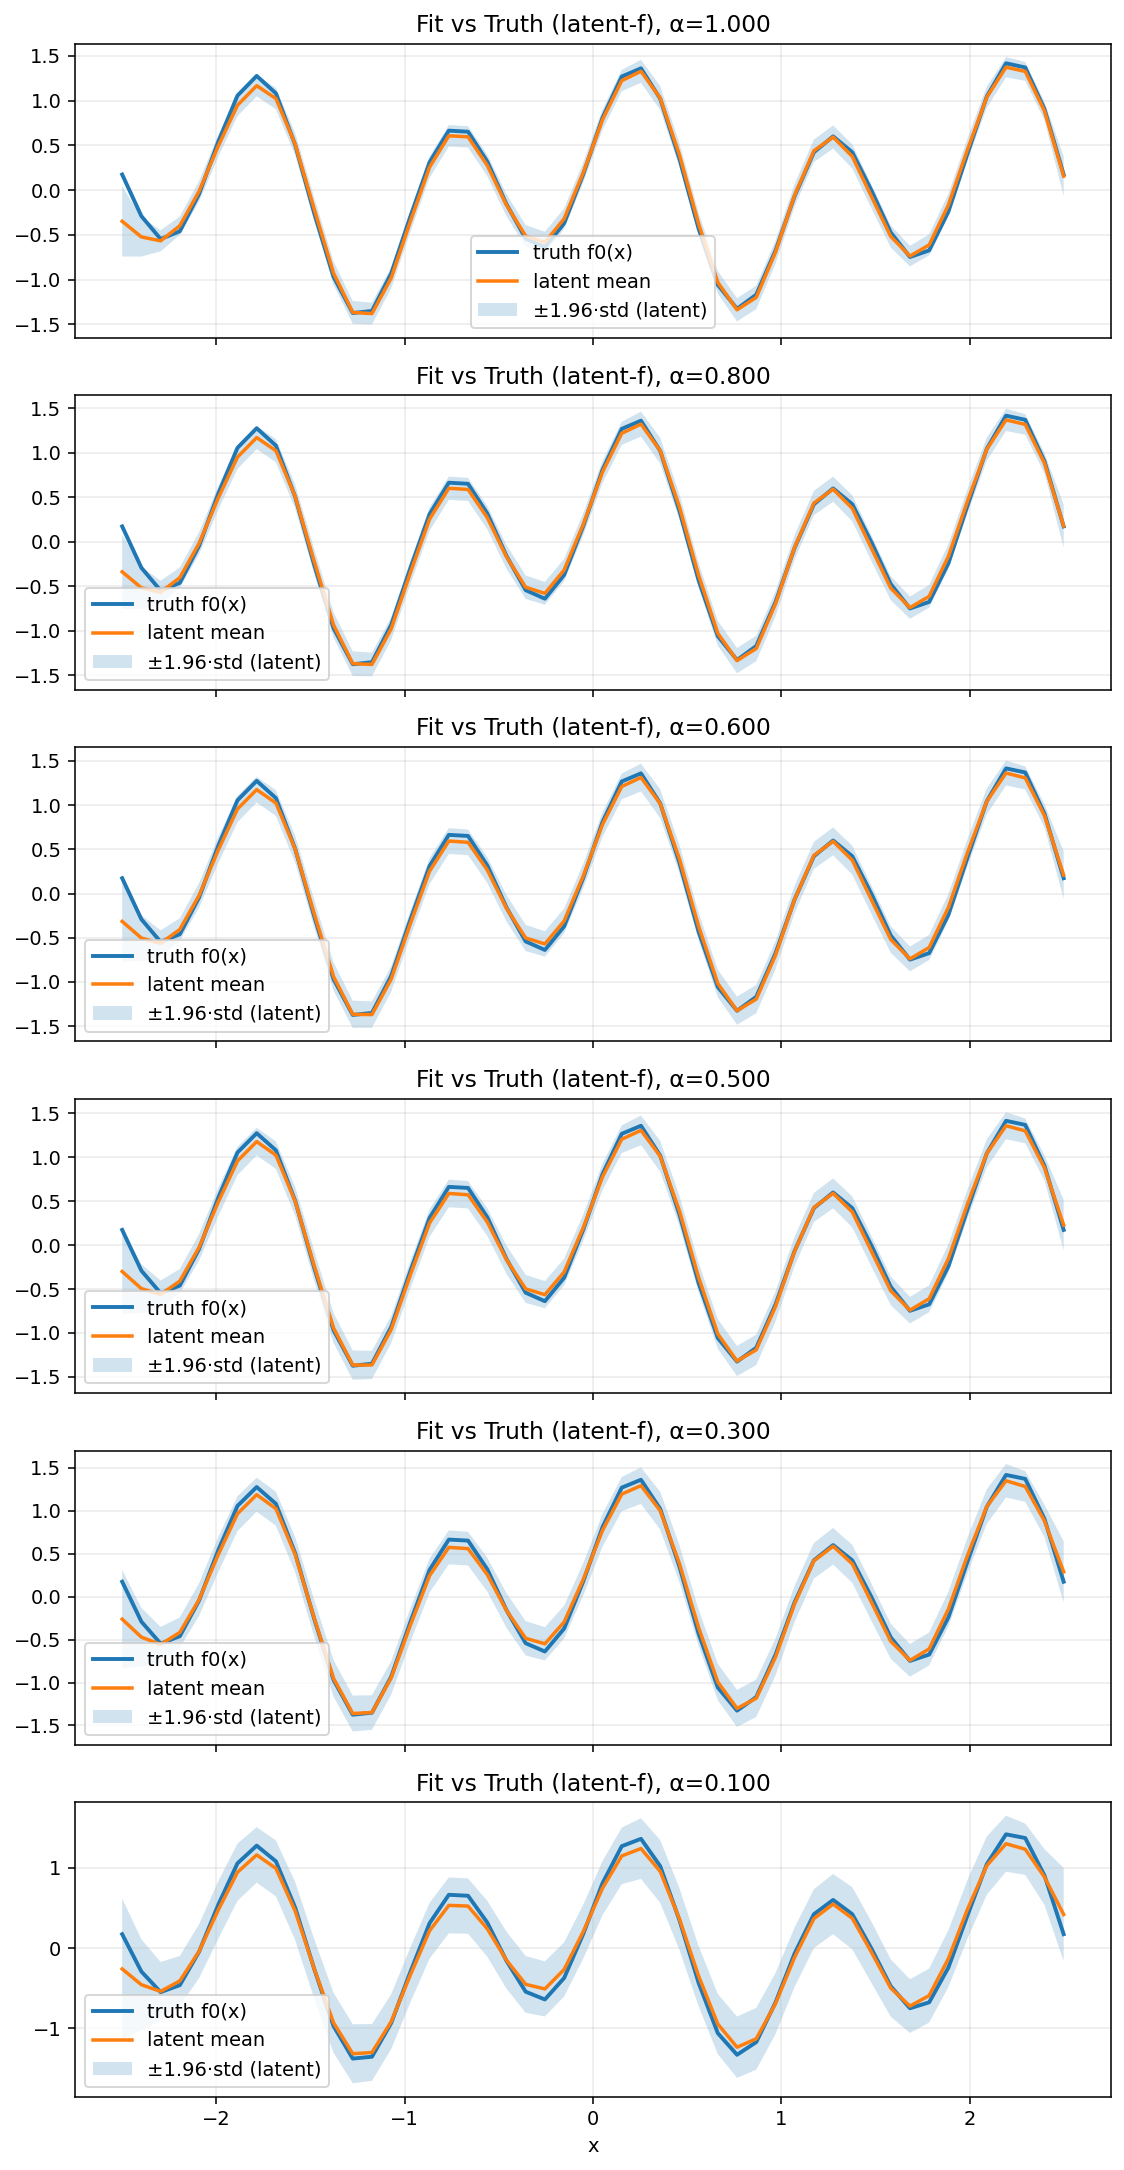

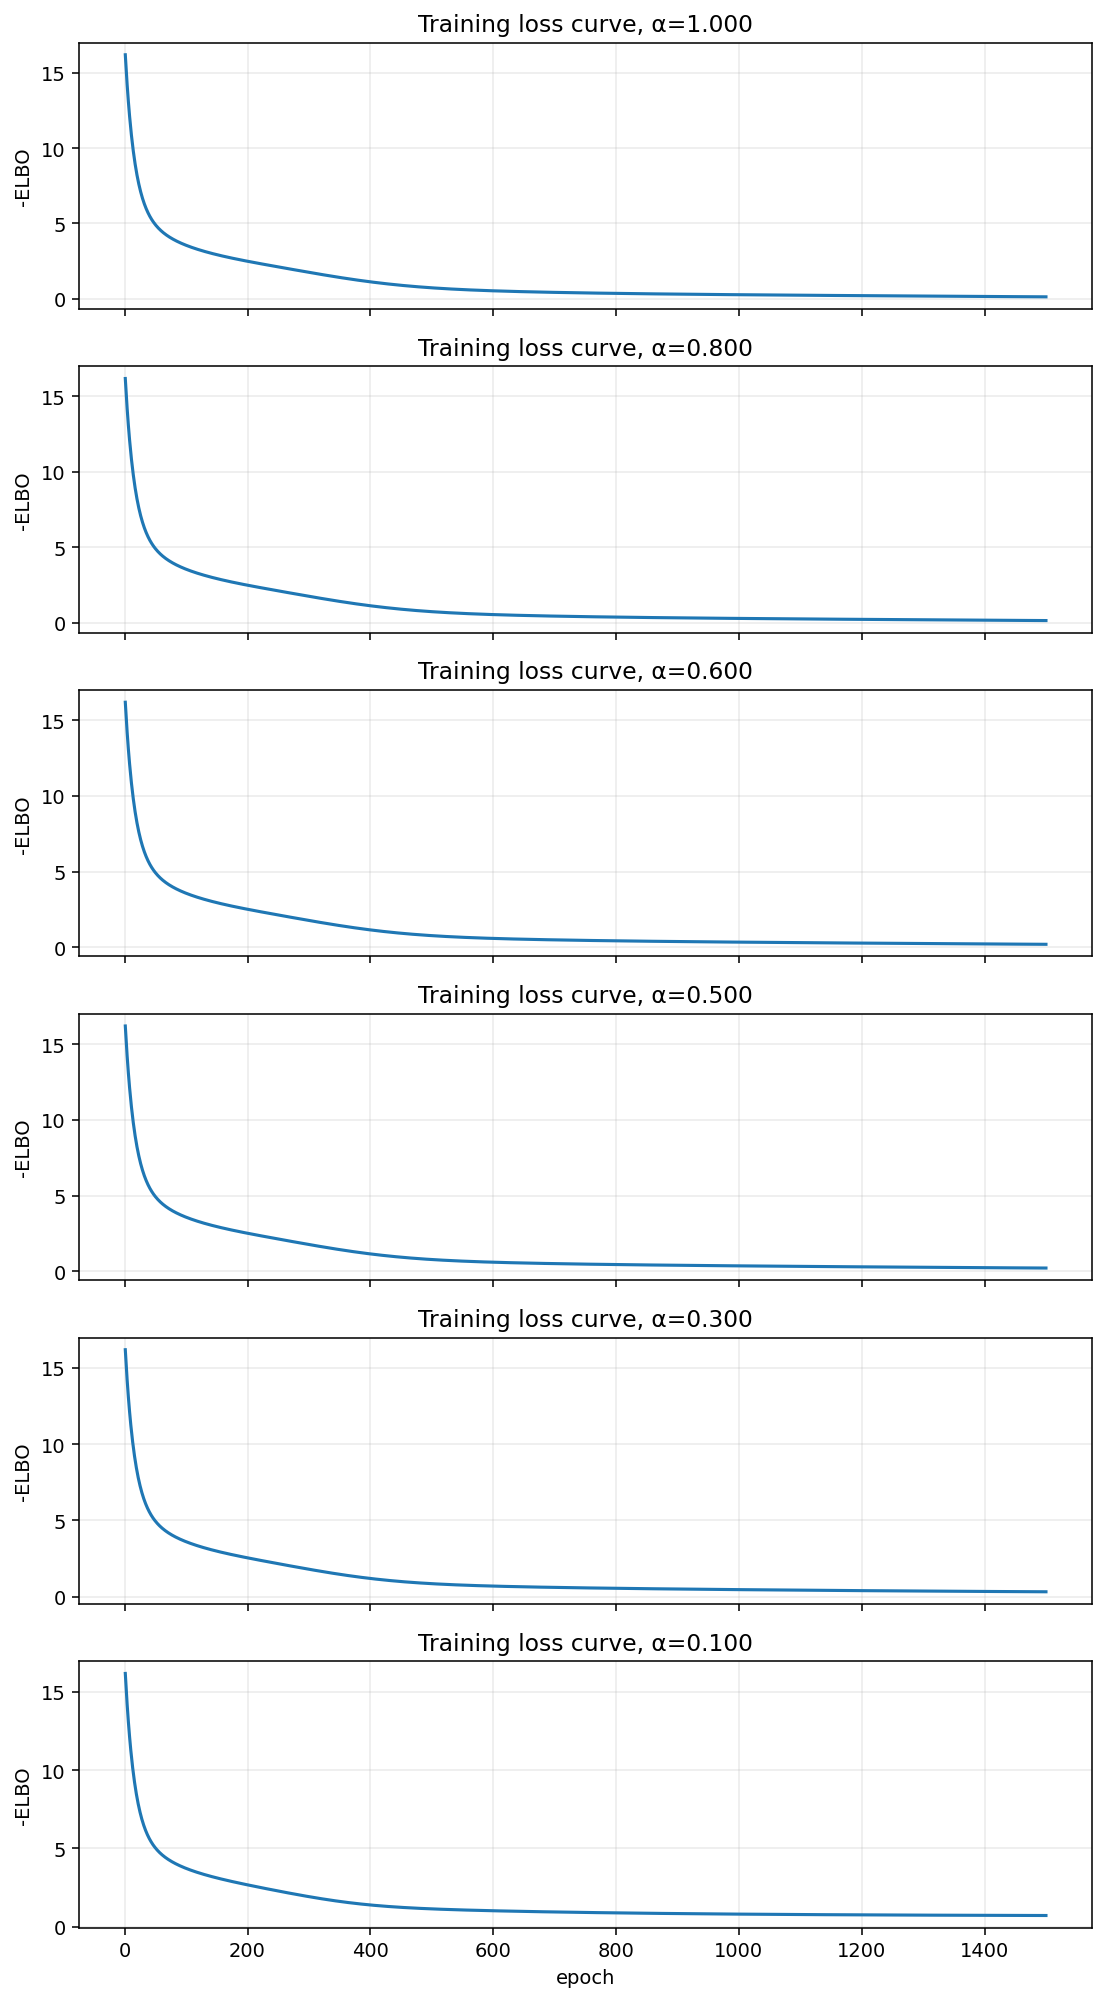

[diag α=1.000] mean(var_f)=4.136507e-03 | ls=0.4103 os=1.3171 | sigma2(train)=0.0822 | latent_only=True
[diag α=0.800] mean(var_f)=4.902746e-03 | ls=0.4058 os=1.3285 | sigma2(train)=0.0824 | latent_only=True
[diag α=0.600] mean(var_f)=6.198714e-03 | ls=0.3992 os=1.3446 | sigma2(train)=0.0832 | latent_only=True
[diag α=0.500] mean(var_f)=7.137205e-03 | ls=0.3933 os=1.3511 | sigma2(train)=0.0826 | latent_only=True
[diag α=0.300] mean(var_f)=1.129435e-02 | ls=0.3769 os=1.3723 | sigma2(train)=0.0855 | latent_only=True
[diag α=0.100] mean(var_f)=3.607610e-02 | ls=0.3300 os=1.3017 | sigma2(train)=0.1060 | latent_only=True
[diag α=1.000] mean(var_f)=4.643785e-03 | ls=0.4158 os=1.3369 | sigma2(train)=0.0937 | latent_only=True
[diag α=0.800] mean(var_f)=5.520736e-03 | ls=0.4108 os=1.3467 | sigma2(train)=0.0942 | latent_only=True
[diag α=0.600] mean(var_f)=7.086159e-03 | ls=0.4039 os=1.3628 | sigma2(train)=0.0965 | latent_only=True
[diag α=0.500] mean(var_f)=8.300599e-03 | ls=0.3985 os=1.3700 | 

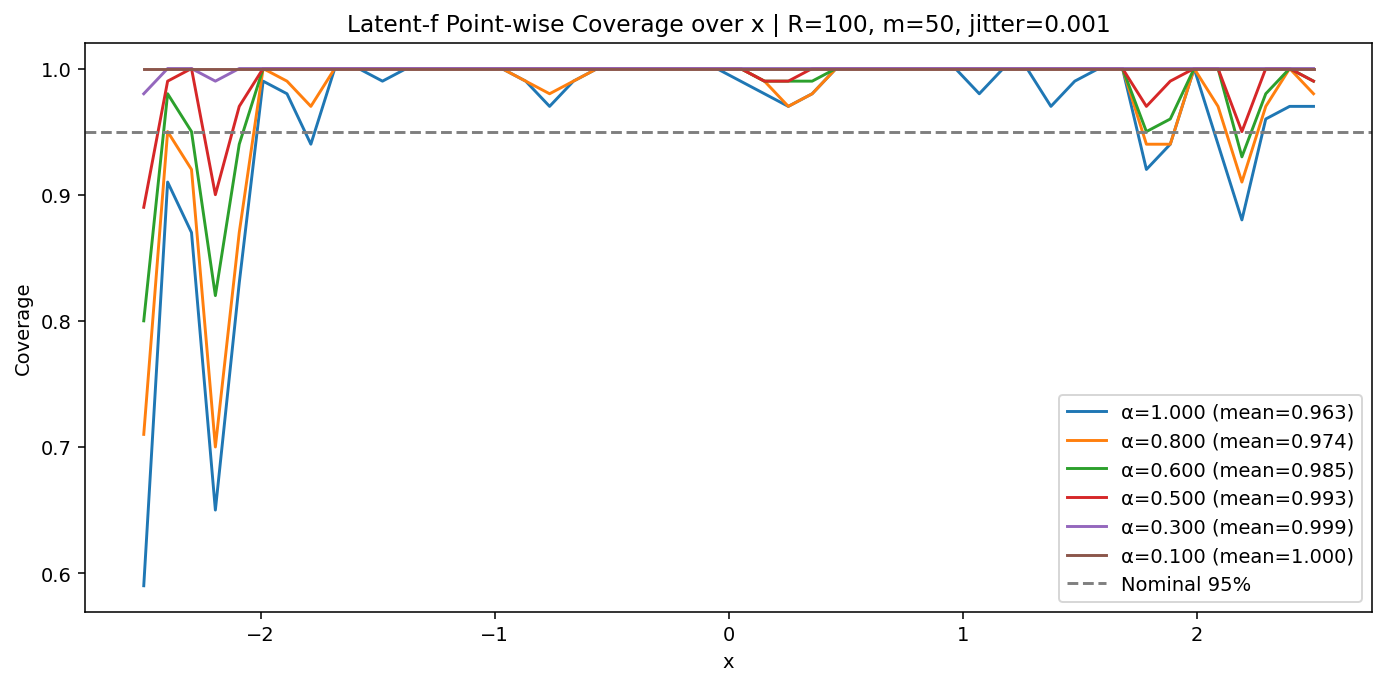


=== MSE summary over reps (latent-f mean vs truth) ===
α=1.000 | mean=4.531503e-03 | std=1.969508e-03 | min=1.348978e-03 | max=1.418527e-02
α=0.800 | mean=4.499704e-03 | std=1.922928e-03 | min=1.370743e-03 | max=1.339211e-02
α=0.600 | mean=4.531633e-03 | std=1.895105e-03 | min=1.498654e-03 | max=1.336047e-02
α=0.500 | mean=4.583079e-03 | std=1.846222e-03 | min=1.692705e-03 | max=1.257766e-02
α=0.300 | mean=5.052828e-03 | std=1.801512e-03 | min=1.941725e-03 | max=1.192077e-02
α=0.100 | mean=9.541986e-03 | std=2.200827e-03 | min=5.474163e-03 | max=1.437342e-02


In [7]:
# svgp_latentf_cov_fit_elbo.py
# 目标：
#   - 只用 latent f 的后验方差评估覆盖率（不叠加观测噪声）
#   - 画图：每个 α 的 fit vs truth（latent-f 均值 ±1.96std）+ 负 ELBO 曲线
#   - GPyTorch 1.14: VariationalStrategy 内置 whitening，无需显式 WhitenedVariationalStrategy
# 作者：you + GPT

import os, math, time, random
from dataclasses import dataclass

import numpy as np
import torch
import gpytorch
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# ========= 基本设置 =========
SEED = 1234
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float64
torch.set_default_dtype(DTYPE)

TRAIN_LOW, TRAIN_HIGH = -2.5, 2.5
TEST_LOW,  TEST_HIGH  = -2.5, 2.5
N_TRAIN, N_TEST = 500, 50

# 诱导点 & 学不学
M_INDUCING = 50
LEARN_Z = False           # 先固定 Z 排除变量；之后可改 True 做对比
STRICT_CONTROL = False    # True：只训 q(u)，冻结核&噪声（自检用）

# 训练超参
EPOCHS = 1500
BATCH_SIZE = 500
LR = 5e-3
JITTER = 1e-3           # 小 jitter，利于方差收敛
INIT_NOISE = 0.05       # 训练用观测噪声初值；评估覆盖时不用
INIT_LS = 0.5           # 初始 lengthscale 稍大，避免初期不确定过高
ALPHAS = [1.0, 0.8, 0.6, 0.5, 0.3, 0.1]
R = 100                 # 覆盖统计的 replication 次数
Z_VAL = 1.96            # 95% 置信

# ========= 真函数 & 数据生成 =========
def f0(x):
    return torch.sin(2*math.pi*x) + 0.5*torch.cos(3*x)

def gen_train_data(n):
    x = torch.empty(n, 1, dtype=DTYPE).uniform_(TRAIN_LOW, TRAIN_HIGH)
    y = f0(x) + INIT_NOISE**0.5 * torch.randn_like(x)  # 训练用带噪 y
    return x, y

def grid_test(n):
    xs = torch.linspace(TEST_LOW, TEST_HIGH, n, dtype=DTYPE).unsqueeze(-1)
    return xs, f0(xs)  # 真 f*(无噪)

# ========= SVGP 定义（1.14: VariationalStrategy 内置 whiten） =========
class SVGPModel(gpytorch.models.ApproximateGP):
    def __init__(self, inducing_points):
        variational_distribution = gpytorch.variational.CholeskyVariationalDistribution(
            inducing_points.size(0)
        )
        variational_strategy = gpytorch.variational.VariationalStrategy(
            self, inducing_points, variational_distribution, learn_inducing_locations=LEARN_Z
        )
        super().__init__(variational_strategy)

        self.mean_module = gpytorch.means.ZeroMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel()
        )
        # 初值
        self.covar_module.base_kernel.lengthscale = INIT_LS
        self.covar_module.outputscale = 1.0

    def forward(self, x):
        x = x.squeeze(-1)
        mean = self.mean_module(x)
        cov  = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean, cov)

def make_likelihood():
    lik = gpytorch.likelihoods.GaussianLikelihood()
    lik.noise = INIT_NOISE
    return lik

# β-ELBO（β=1/α）
class BetaELBO(gpytorch.mlls.VariationalELBO):
    def __init__(self, likelihood, model, num_data, beta=1.0):
        super().__init__(likelihood, model, num_data=num_data, beta=beta)

# ========= 仅 latent-f 的后验 =========
@torch.no_grad()
def latent_f_posterior(model, x_test):
    model.eval()
    with gpytorch.settings.fast_pred_var(True):
        post_f = model(x_test)      # 不过 likelihood -> 得到 latent f 分布
    mean_f = post_f.mean
    std_f  = post_f.variance.clamp_min(1e-12).sqrt()
    return mean_f, std_f

def pointwise_coverage(mean_f, std_f, f_true, z=Z_VAL):
    lower = mean_f - z * std_f
    upper = mean_f + z * std_f
    hit   = (f_true.squeeze(-1) >= lower) & (f_true.squeeze(-1) <= upper)
    return hit.detach().cpu().numpy().astype(np.int32)  # (J,)

# ========= 单个 α、单次 replication =========
def train_one_alpha(alpha, train_x, train_y, x_test, f_true, Z_init, need_log=False):
    model = SVGPModel(Z_init.clone())
    likelihood = make_likelihood()
    model, likelihood = model.to(DEVICE), likelihood.to(DEVICE)

    dataset = TensorDataset(train_x.to(DEVICE), train_y.squeeze(-1).to(DEVICE))
    loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

    beta = 1.0 / alpha
    mll  = BetaELBO(likelihood, model, num_data=N_TRAIN, beta=beta)

    # 参数选择
    params = [
        {'params': model.parameters()},
        {'params': likelihood.parameters()},
    ]
    if STRICT_CONTROL:
        for name, p in model.named_parameters():
            if "variational" in name:
                p.requires_grad_(True)
            else:
                p.requires_grad_(False)
        for p in likelihood.parameters():
            p.requires_grad_(False)
        params = [{'params':[p for p in model.parameters() if p.requires_grad]}]

    opt = torch.optim.Adam(params, lr=LR)

    loss_curve = []  # 仅 need_log=True 时真正使用

    model.train(); likelihood.train()
    with gpytorch.settings.cholesky_jitter(JITTER):
        for epoch in range(1, EPOCHS+1):
            for bx, by in loader:
                opt.zero_grad(set_to_none=True)
                out = model(bx)
                loss = -mll(out, by)
                loss.backward()
                opt.step()
            if need_log:
                # 记录每个 epoch 最后的一个 batch 的 loss（代表趋势）
                loss_curve.append(float(loss.detach().cpu()))

    # 评估（只看 latent-f）
    with torch.no_grad(), gpytorch.settings.cholesky_jitter(JITTER):
        mean_f, std_f = latent_f_posterior(model, x_test.to(DEVICE))
        hit = pointwise_coverage(mean_f, std_f, f_true.to(DEVICE))  # (J,)
        mse = torch.mean((mean_f.cpu() - f_true.squeeze(-1))**2).item()
        # 记录一些量
        ls = float(model.covar_module.base_kernel.lengthscale.detach().cpu())
        os = float(model.covar_module.outputscale.detach().cpu())
        sigma2 = float(likelihood.noise.detach().cpu())
        mean_var_f = float((std_f**2).mean().cpu())
        print(f"[diag α={alpha:.3f}] mean(var_f)={mean_var_f:.6e} | "
              f"ls={ls:.4f} os={os:.4f} | sigma2(train)={sigma2:.4f} | latent_only=True")

    rep_log = None
    if need_log:
        # 准备“fit vs truth”的可画数据
        rep_log = {
            "x": x_test.squeeze(-1).cpu().numpy(),
            "f_true": f_true.squeeze(-1).cpu().numpy(),
            "mean_f": mean_f.cpu().numpy(),
            "std_f": std_f.cpu().numpy(),
            "loss_curve": np.array(loss_curve, dtype=np.float64),
        }

    return hit, mse, {'lengthscale': ls, 'outputscale': os, 'sigma2': sigma2}, rep_log

# ========= 主流程 =========
def main():
    print(f"[init] device={DEVICE} | dtype={torch.get_default_dtype()} | "
          f"train/test=({N_TRAIN}/{N_TEST}) | m(Z)={M_INDUCING} | R={R}")
    x_test, f_true = grid_test(N_TEST)
    # 等距固定 Z（控制变量）
    Z = torch.linspace(TRAIN_LOW, TRAIN_HIGH, M_INDUCING, dtype=DTYPE).unsqueeze(-1)

    hits = {alpha: [] for alpha in ALPHAS}
    mses = {alpha: [] for alpha in ALPHAS}

    # ===== Replication 1：记录代表性曲线（fit vs truth + -ELBO）=====
    train_x1, train_y1 = gen_train_data(N_TRAIN)
    rep1_logs = {}
    for alpha in ALPHAS:
        h, mse, info, log = train_one_alpha(alpha, train_x1, train_y1, x_test, f_true, Z, need_log=True)
        hits[alpha].append(h)
        mses[alpha].append(mse)
        rep1_logs[alpha] = log

    # 画每个 α 的 fit vs truth（latent-f）
    nA = len(ALPHAS)
    fig1, axes1 = plt.subplots(nA, 1, figsize=(8, 2.6*nA), sharex=True)
    if nA == 1:
        axes1 = [axes1]
    for ax, alpha in zip(axes1, ALPHAS):
        log = rep1_logs[alpha]
        xs = log["x"]
        true = log["f_true"]
        mu = log["mean_f"]
        std = log["std_f"]
        ax.plot(xs, true, lw=2, label="truth f0(x)")
        ax.plot(xs, mu, lw=1.8, label="latent mean")
        ax.fill_between(xs, mu - Z_VAL*std, mu + Z_VAL*std, alpha=0.2, label="±1.96·std (latent)")
        ax.set_title(f"Fit vs Truth (latent-f), α={alpha:.3f}")
        ax.legend(loc="best")
        ax.grid(alpha=0.25)
    axes1[-1].set_xlabel("x")
    plt.tight_layout()
    plt.show()

    # 画每个 α 的负 ELBO 曲线
    fig2, axes2 = plt.subplots(nA, 1, figsize=(8, 2.4*nA), sharex=True)
    if nA == 1:
        axes2 = [axes2]
    for ax, alpha in zip(axes2, ALPHAS):
        log = rep1_logs[alpha]
        ax.plot(np.arange(1, len(log["loss_curve"])+1), log["loss_curve"], lw=1.6)
        ax.set_ylabel("-ELBO")
        ax.set_title(f"Training loss curve, α={alpha:.3f}")
        ax.grid(alpha=0.25)
    axes2[-1].set_xlabel("epoch")
    plt.tight_layout()
    plt.show()

    # ===== Replication 2..R：只做覆盖统计 =====
    t0 = time.time()
    for r in range(2, R+1):
        train_x, train_y = gen_train_data(N_TRAIN)
        for alpha in ALPHAS:
            h, mse, info, _ = train_one_alpha(alpha, train_x, train_y, x_test, f_true, Z, need_log=False)
            hits[alpha].append(h)
            mses[alpha].append(mse)
        if r % 5 == 0 or r == R:
            dt = time.time() - t0
            msg = " | ".join([f"α={a:.1f}:{np.mean(np.stack(hits[a],0),0).mean():.3f}" for a in ALPHAS])
            print(f"[rep {r:03d}/{R}] mean-coverage by α -> {msg} | elapsed={dt/60:.1f} min")

    # === 覆盖曲线 ===
    xs = x_test.squeeze(-1).cpu().numpy()
    plt.figure(figsize=(10,5))
    for alpha in ALPHAS:
        H = np.stack(hits[alpha], axis=0)   # (R, J)
        cov = H.mean(axis=0)                # 每个 x_j 的覆盖率
        mean_cov = cov.mean()
        plt.plot(xs, cov, label=f"α={alpha:.3f} (mean={mean_cov:.3f})")
        print(f"[summary] alpha={alpha:.3f} | mean coverage={mean_cov:.4f}")

    plt.axhline(0.95, ls="--", color="C7", label="Nominal 95%")
    plt.title(f"Latent-f Point-wise Coverage over x | R={R}, m={M_INDUCING}, jitter={JITTER:g}")
    plt.xlabel("x"); plt.ylabel("Coverage"); plt.legend()
    plt.tight_layout()
    plt.show()

    # MSE 简表
    print("\n=== MSE summary over reps (latent-f mean vs truth) ===")
    for alpha in ALPHAS:
        arr = np.array(mses[alpha])
        print(f"α={alpha:.3f} | mean={arr.mean():.6e} | std={arr.std():.6e} | "
              f"min={arr.min():.6e} | max={arr.max():.6e}")

if __name__ == "__main__":
    main()


[init] dev=cuda dtype=torch.float64 | N=(500/50) | m=32 | jitter=0.0005
[diag α=1.000] mean(var_f)=2.122357e-03 | ls=0.2460 os=0.3999 | sigma2(train)=0.0030 | latent_only=True
[diag α=0.800] mean(var_f)=9.170743e-04 | ls=0.1781 os=0.2600 | sigma2(train)=0.0030 | latent_only=True
[diag α=0.600] mean(var_f)=1.503399e-03 | ls=0.1941 os=0.2596 | sigma2(train)=0.0030 | latent_only=True
[diag α=0.500] mean(var_f)=2.552381e-03 | ls=0.2510 os=0.4942 | sigma2(train)=0.0030 | latent_only=True
[diag α=0.300] mean(var_f)=1.002062e-03 | ls=0.1737 os=0.3544 | sigma2(train)=0.0030 | latent_only=True
[diag α=0.100] mean(var_f)=2.120637e-03 | ls=0.1851 os=0.6016 | sigma2(train)=0.0030 | latent_only=True
[rep 001/100] done.


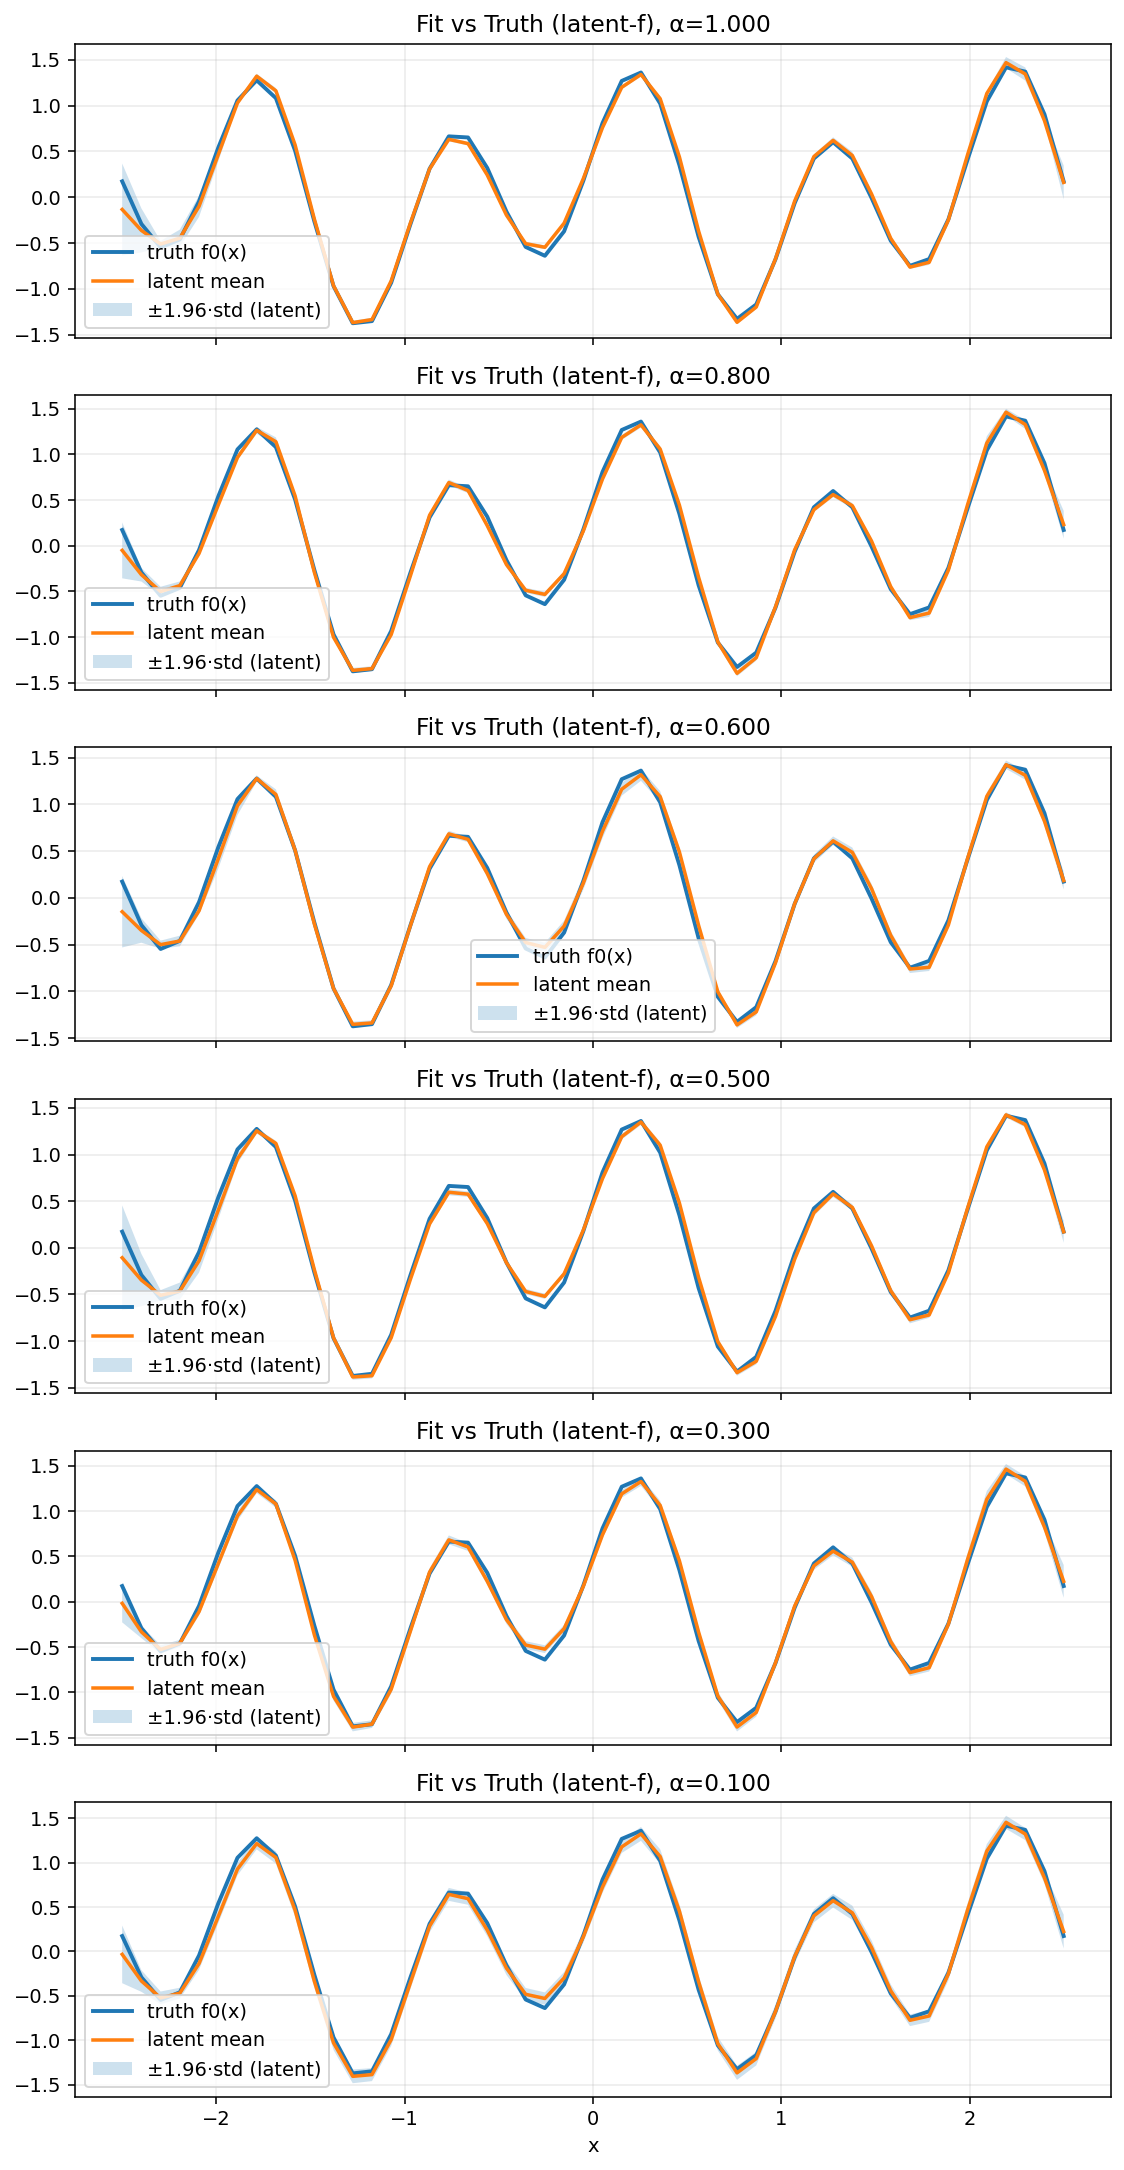

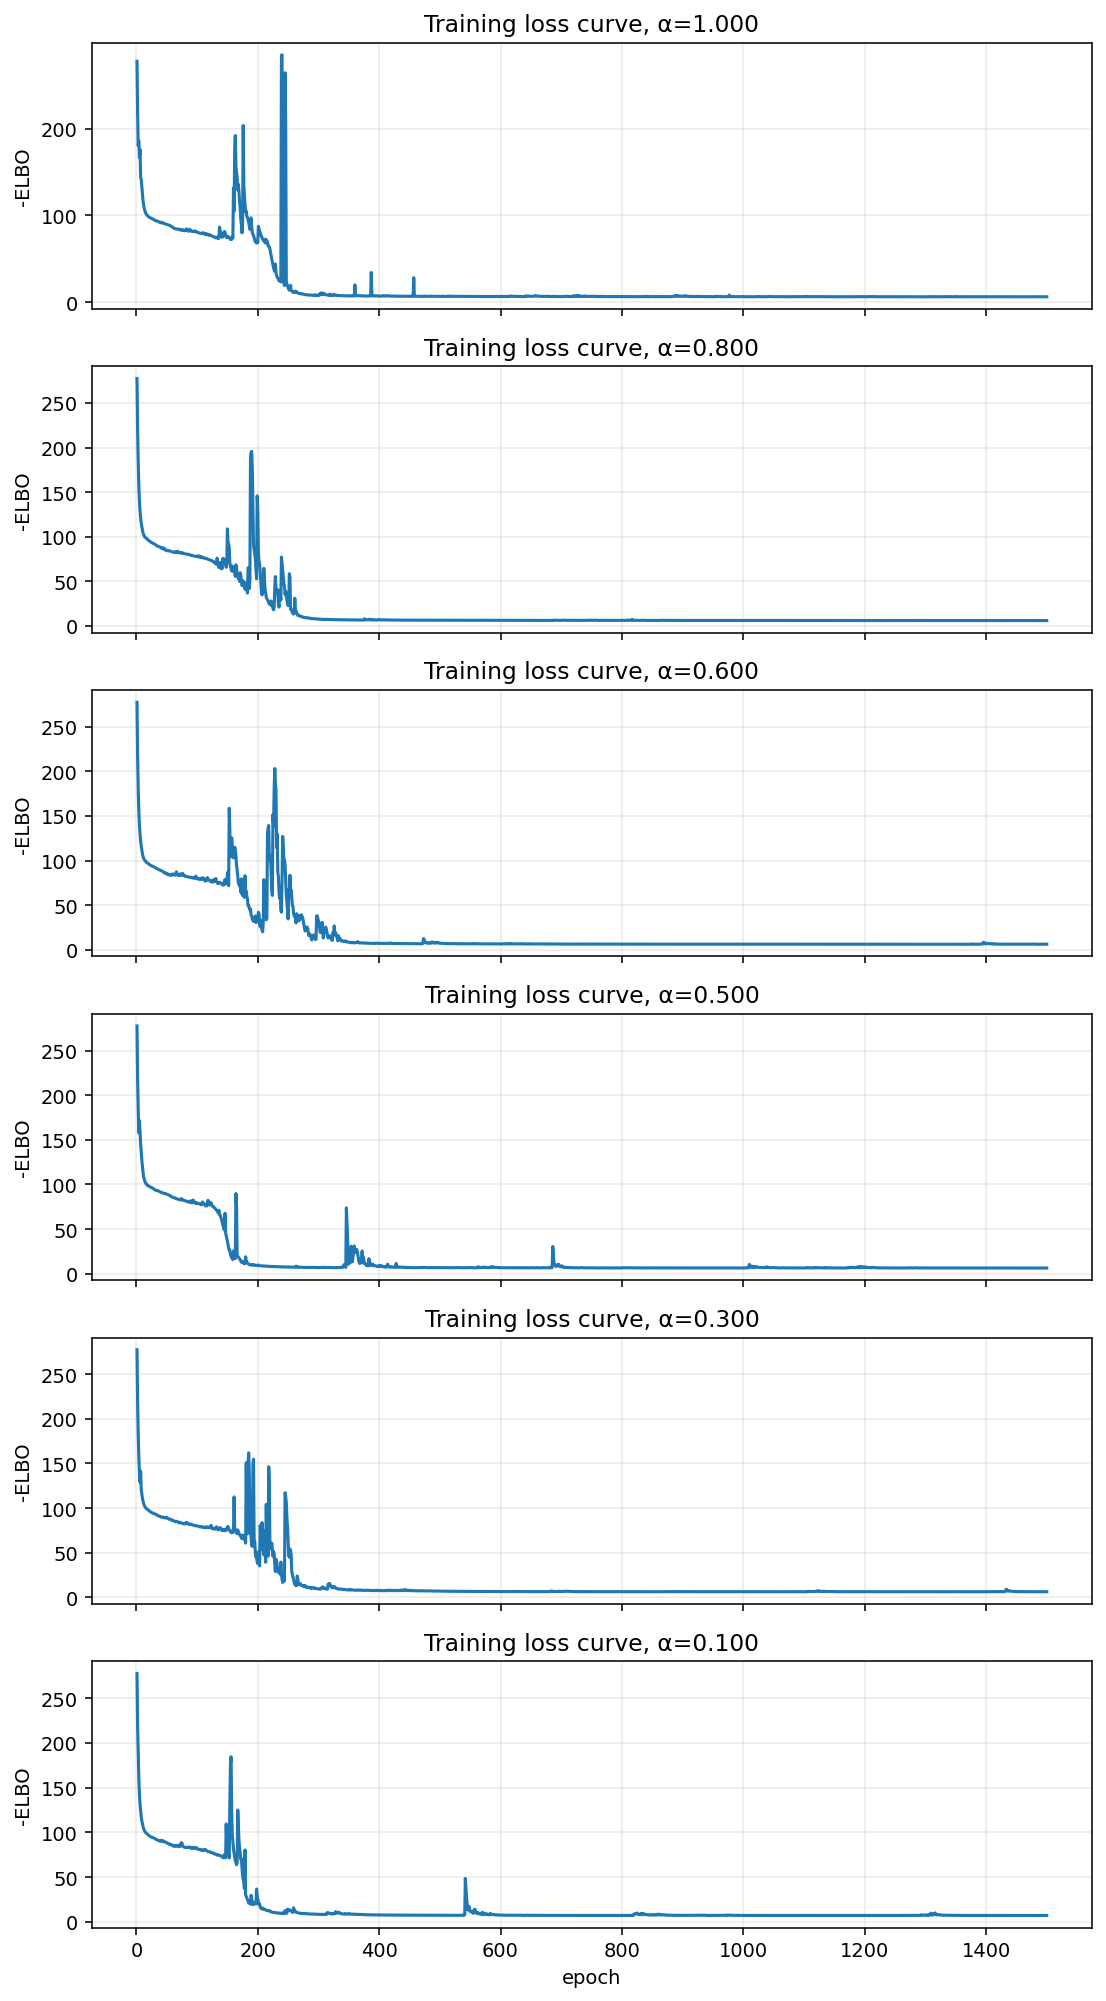

[diag α=1.000] mean(var_f)=2.252664e-03 | ls=0.1337 os=0.0516 | sigma2(train)=0.0030 | latent_only=True
[diag α=0.800] mean(var_f)=2.882496e-03 | ls=0.1201 os=0.0431 | sigma2(train)=0.0030 | latent_only=True
[diag α=0.600] mean(var_f)=8.340725e-04 | ls=0.2073 os=0.3911 | sigma2(train)=0.0030 | latent_only=True
[diag α=0.500] mean(var_f)=1.492780e-03 | ls=0.1839 os=0.2349 | sigma2(train)=0.0030 | latent_only=True
[diag α=0.300] mean(var_f)=7.992063e-04 | ls=0.2046 os=0.4908 | sigma2(train)=0.0030 | latent_only=True
[diag α=0.100] mean(var_f)=1.886171e-03 | ls=0.2137 os=0.8512 | sigma2(train)=0.0030 | latent_only=True
[diag α=1.000] mean(var_f)=4.021738e-03 | ls=0.0970 os=0.0232 | sigma2(train)=0.0030 | latent_only=True
[diag α=0.800] mean(var_f)=3.449717e-03 | ls=0.1190 os=0.0349 | sigma2(train)=0.0030 | latent_only=True
[diag α=0.600] mean(var_f)=6.574730e-04 | ls=0.2240 os=0.5471 | sigma2(train)=0.0030 | latent_only=True
[diag α=0.500] mean(var_f)=7.213028e-04 | ls=0.1679 os=0.3183 | 

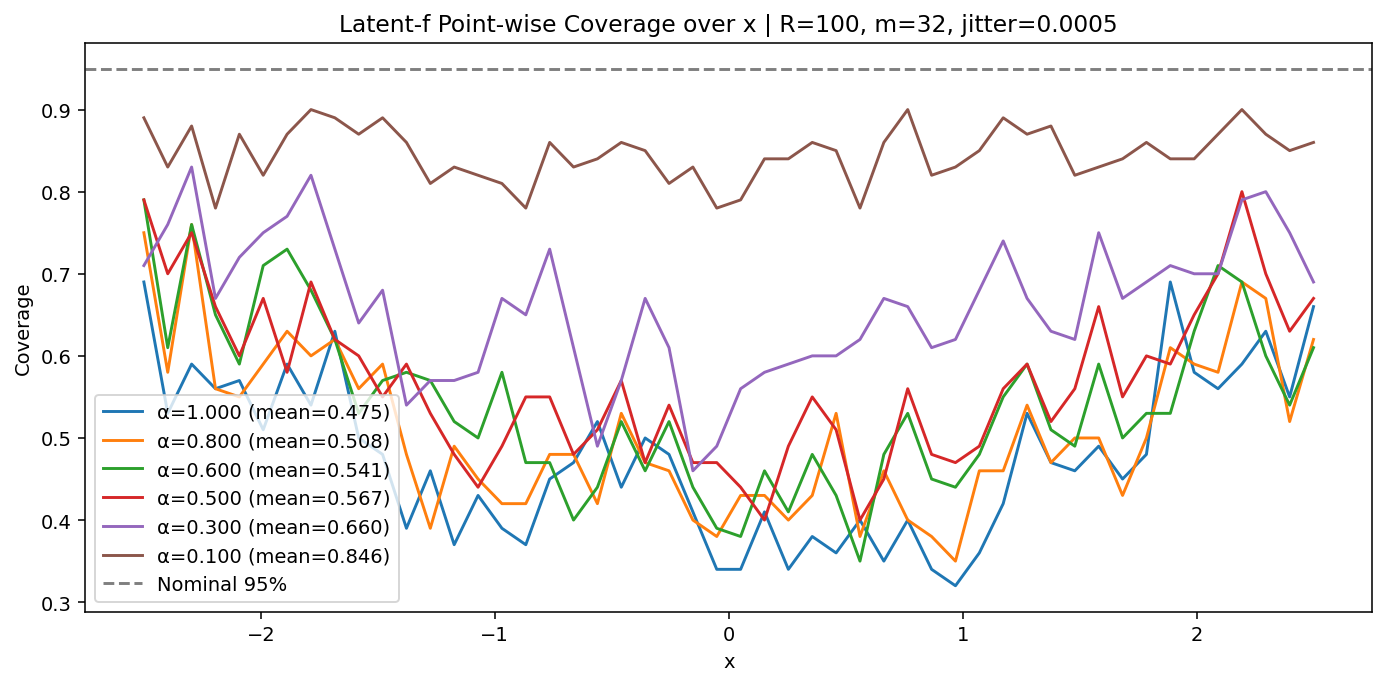


=== MSE summary over reps (latent-f mean vs truth) ===
α=1.000 | mean=8.628638e-03 | std=1.929652e-02 | min=1.402975e-03 | max=1.549785e-01
α=0.800 | mean=6.763252e-03 | std=1.196663e-02 | min=1.053167e-03 | max=9.302346e-02
α=0.600 | mean=8.102507e-03 | std=1.796454e-02 | min=1.317181e-03 | max=1.386715e-01
α=0.500 | mean=8.330190e-03 | std=1.859902e-02 | min=1.239541e-03 | max=1.104570e-01
α=0.300 | mean=6.810036e-03 | std=1.791368e-02 | min=1.638958e-03 | max=1.754277e-01
α=0.100 | mean=1.147243e-02 | std=4.081113e-02 | min=1.055290e-03 | max=3.743580e-01


In [18]:
# svgp_latentf_cov_fit_elbo_zscore.py
import os, math, time, random
from dataclasses import dataclass

import numpy as np
import torch
import gpytorch
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# ========= 基本设置 =========
SEED = 1234
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float64
torch.set_default_dtype(DTYPE)

TRAIN_LOW, TRAIN_HIGH = -2.5, 2.5
TEST_LOW,  TEST_HIGH  = -2.5, 2.5
N_TRAIN, N_TEST = 500, 50

# 诱导点 & 学不学
M_INDUCING = 32
LEARN_Z = True
STRICT_CONTROL = False

# 训练超参（保持与你要求一致）
EPOCHS = 1500
BATCH_SIZE = 500
LR = 5e-2
JITTER = 5e-4
INIT_NOISE = 0.05
INIT_LS = 0.8
ALPHAS = [1.0, 0.8, 0.6, 0.5, 0.3, 0.1]
R = 100
Z_VAL = 1.96  # 95%置信

# ========= 真函数 & 数据生成 =========
def f0(x):
    return torch.sin(2*math.pi*x) + 0.5*torch.cos(3*x)

def gen_train_data(n):
    x = torch.empty(n, 1, dtype=DTYPE).uniform_(TRAIN_LOW, TRAIN_HIGH)
    y = f0(x) + INIT_NOISE**0.5 * torch.randn_like(x)
    return x, y

def grid_test(n):
    xs = torch.linspace(TEST_LOW, TEST_HIGH, n, dtype=DTYPE).unsqueeze(-1)
    return xs, f0(xs)

# ========= SVGP（GPyTorch 1.14: VariationalStrategy 默认 whitening）=========
class SVGPModel(gpytorch.models.ApproximateGP):
    def __init__(self, inducing_points):
        q_dist = gpytorch.variational.CholeskyVariationalDistribution(inducing_points.size(0))
        q_strat = gpytorch.variational.VariationalStrategy(
            self, inducing_points, q_dist, learn_inducing_locations=LEARN_Z
        )
        super().__init__(q_strat)
        self.mean_module = gpytorch.means.ZeroMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())
        self.covar_module.base_kernel.lengthscale = INIT_LS
        self.covar_module.outputscale = 1.0

    def forward(self, x):
        x = x.squeeze(-1)
        mean = self.mean_module(x)
        cov  = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean, cov)

def make_likelihood():
    lik = gpytorch.likelihoods.GaussianLikelihood()
    with torch.no_grad():
        lik.noise = torch.as_tensor(3e-3, dtype=DTYPE, device=DEVICE)  # 小而稳定
    # 冻结噪声
    lik.noise_covar.raw_noise.requires_grad_(False)
    return lik

class BetaELBO(gpytorch.mlls.VariationalELBO):
    def __init__(self, likelihood, model, num_data, beta=1.0):
        super().__init__(likelihood, model, num_data=num_data, beta=beta)

# ========= 仅 latent-f 的后验 =========
@torch.no_grad()
def latent_f_posterior(model, x_test):
    model.eval()
    with gpytorch.settings.fast_pred_var(True):
        post_f = model(x_test)
    mean_f = post_f.mean
    std_f  = post_f.variance.clamp_min(1e-12).sqrt()
    return mean_f, std_f

def pointwise_coverage(mean_f, std_f, f_true, z=Z_VAL):
    lower = mean_f - z * std_f
    upper = mean_f + z * std_f
    hit   = (f_true.squeeze(-1) >= lower) & (f_true.squeeze(-1) <= upper)
    return hit.detach().cpu().numpy().astype(np.int32)

# ========= 单个 α、单次 replication =========
def train_one_alpha(alpha, x_train_n, y_train, x_test_n, f_true, Z_n, x_axis_raw, need_log=False):
    """
    x_train_n / x_test_n / Z_n: 已按本rep的x均值方差z-score
    x_axis_raw: 原始测试网格 (numpy)，仅用于画图
    """
    model = SVGPModel(Z_n.clone())
    likelihood = make_likelihood()
    model, likelihood = model.to(DEVICE), likelihood.to(DEVICE)

    dataset = TensorDataset(x_train_n.to(DEVICE), y_train.squeeze(-1).to(DEVICE))
    loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)

    beta = 1.0 / alpha
    mll  = BetaELBO(likelihood, model, num_data=N_TRAIN, beta=beta)

    # ---- 只创建一次 optimizer；保持常数学习率 ----
    params = [{'params': model.parameters()}, {'params': likelihood.parameters()}]
    if STRICT_CONTROL:
        for name, p in model.named_parameters():
            p.requires_grad_(("variational" in name))
        for p in likelihood.parameters():
            p.requires_grad_(False)
        params = [{'params': [p for p in model.parameters() if p.requires_grad]}]

    opt = torch.optim.Adam(params, lr=LR)

    loss_curve = []
    model.train(); likelihood.train()
    with gpytorch.settings.cholesky_jitter(JITTER):
        for epoch in range(1, EPOCHS + 1):
            for bx, by in loader:
                opt.zero_grad(set_to_none=True)
                out = model(bx)
                loss = -mll(out, by)
                loss.backward()
                # ---- 轻度梯度裁剪（稳态小保险）----
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
                opt.step()
            if need_log:
                loss_curve.append(float(loss.detach().cpu()))

    # ===== 评估（latent-f）=====
    with torch.no_grad(), gpytorch.settings.cholesky_jitter(JITTER):
        mean_f, std_f = latent_f_posterior(model, x_test_n.to(DEVICE))
        hit = pointwise_coverage(mean_f, std_f, f_true.to(DEVICE))
        mse = torch.mean((mean_f.cpu() - f_true.squeeze(-1))**2).item()
        ls = float(model.covar_module.base_kernel.lengthscale.detach().cpu())
        os = float(model.covar_module.outputscale.detach().cpu())
        sigma2 = float(likelihood.noise.detach().cpu())
        mean_var_f = float((std_f**2).mean().cpu())
        print(f"[diag α={alpha:.3f}] mean(var_f)={mean_var_f:.6e} | "
              f"ls={ls:.4f} os={os:.4f} | sigma2(train)={sigma2:.4f} | latent_only=True")

    rep_log = None
    if need_log:
        rep_log = {
            "x": np.asarray(x_axis_raw),
            "f_true": f_true.squeeze(-1).cpu().numpy(),
            "mean_f": mean_f.cpu().numpy(),
            "std_f": std_f.cpu().numpy(),
            "loss_curve": np.array(loss_curve, dtype=np.float64),
        }

    return hit, mse, {'lengthscale': ls, 'outputscale': os, 'sigma2': sigma2}, rep_log


# ========= 主流程 =========
def main():
    print(f"[init] dev={DEVICE} dtype={torch.get_default_dtype()} | N=({N_TRAIN}/{N_TEST}) | m={M_INDUCING} | jitter={JITTER:g}")
    # 固定原始测试网格 & 真函数
    x_test_raw, f_true_raw = grid_test(N_TEST)
    x_axis_raw = x_test_raw.squeeze(-1).cpu().numpy()

    # 原始坐标的等距 Z；每个rep按z-score映到标准化坐标
    Z_raw = torch.linspace(TRAIN_LOW, TRAIN_HIGH, M_INDUCING, dtype=DTYPE).unsqueeze(-1)

    hits = {alpha: [] for alpha in ALPHAS}
    mses = {alpha: [] for alpha in ALPHAS}

    # ===== Replication 1：记录代表性曲线（fit vs truth + -ELBO）=====
    train_x1_raw, train_y1 = gen_train_data(N_TRAIN)
    x_mean1 = train_x1_raw.mean(0, keepdim=True)
    x_std1  = train_x1_raw.std(0, keepdim=True).clamp_min(1e-6)
    x_tr1_n = (train_x1_raw - x_mean1) / x_std1
    x_te1_n = (x_test_raw    - x_mean1) / x_std1
    Z1_n    = (Z_raw         - x_mean1) / x_std1

    rep1_logs = {}
    for alpha in ALPHAS:
        h, mse, info, log = train_one_alpha(
            alpha, x_tr1_n, train_y1, x_te1_n, f_true_raw, Z1_n, x_axis_raw, need_log=True
        )
        hits[alpha].append(h); mses[alpha].append(mse); rep1_logs[alpha] = log
    print(f"[rep 001/{R}] done.")

    # —— 画每个 α 的 fit vs truth（latent-f）——
    nA = len(ALPHAS)
    fig1, axes1 = plt.subplots(nA, 1, figsize=(8, 2.6*nA), sharex=True)
    if nA == 1: axes1 = [axes1]
    for ax, alpha in zip(axes1, ALPHAS):
        log = rep1_logs[alpha]
        xs = log["x"]; true = log["f_true"]; mu = log["mean_f"]; std = log["std_f"]
        ax.plot(xs, true, lw=2, label="truth f0(x)")
        ax.plot(xs, mu, lw=1.8, label="latent mean")
        ax.fill_between(xs, mu - Z_VAL*std, mu + Z_VAL*std, alpha=0.22, label="±1.96·std (latent)")
        ax.set_title(f"Fit vs Truth (latent-f), α={alpha:.3f}")
        ax.legend(loc="best"); ax.grid(alpha=0.25)
    axes1[-1].set_xlabel("x")
    plt.tight_layout(); plt.show()

    # —— 画每个 α 的负 ELBO 曲线 —— 
    fig2, axes2 = plt.subplots(nA, 1, figsize=(8, 2.4*nA), sharex=True)
    if nA == 1: axes2 = [axes2]
    for ax, alpha in zip(axes2, ALPHAS):
        log = rep1_logs[alpha]
        ax.plot(np.arange(1, len(log["loss_curve"])+1), log["loss_curve"], lw=1.6)
        ax.set_ylabel("-ELBO"); ax.set_title(f"Training loss curve, α={alpha:.3f}")
        ax.grid(alpha=0.25)
    axes2[-1].set_xlabel("epoch")
    plt.tight_layout(); plt.show()

    # ===== Replication 2..R：只做覆盖统计 =====
    t0 = time.time()
    for r in range(2, R+1):
        train_x_raw, train_y = gen_train_data(N_TRAIN)
        x_mean = train_x_raw.mean(0, keepdim=True)
        x_std  = train_x_raw.std(0, keepdim=True).clamp_min(1e-6)
        x_tr_n = (train_x_raw - x_mean) / x_std
        x_te_n = (x_test_raw  - x_mean) / x_std
        Z_n    = (Z_raw       - x_mean) / x_std

        for alpha in ALPHAS:
            h, mse, info, _ = train_one_alpha(
                alpha, x_tr_n, train_y, x_te_n, f_true_raw, Z_n, x_axis_raw, need_log=False
            )
            hits[alpha].append(h); mses[alpha].append(mse)
        if r % 5 == 0 or r == R:
            dt = time.time() - t0
            msg = " | ".join([f"α={a:.1f}:{np.mean(np.stack(hits[a],0),0).mean():.3f}" for a in ALPHAS])
            print(f"[rep {r:03d}/{R}] mean-coverage by α -> {msg} | elapsed={dt/60:.1f} min")

    # === 覆盖曲线 ===
    xs = x_axis_raw
    plt.figure(figsize=(10,5))
    for alpha in ALPHAS:
        H = np.stack(hits[alpha], axis=0)   # (R, J)
        cov = H.mean(axis=0)
        mean_cov = cov.mean()
        plt.plot(xs, cov, label=f"α={alpha:.3f} (mean={mean_cov:.3f})")
        print(f"[summary] alpha={alpha:.3f} | mean coverage={mean_cov:.4f}")

    plt.axhline(0.95, ls="--", color="C7", label="Nominal 95%")
    plt.title(f"Latent-f Point-wise Coverage over x | R={R}, m={M_INDUCING}, jitter={JITTER:g}")
    plt.xlabel("x"); plt.ylabel("Coverage"); plt.legend()
    plt.tight_layout(); plt.show()

    # MSE 简表
    print("\n=== MSE summary over reps (latent-f mean vs truth) ===")
    for alpha in ALPHAS:
        arr = np.array(mses[alpha])
        print(f"α={alpha:.3f} | mean={arr.mean():.6e} | std={arr.std():.6e} | "
              f"min={arr.min():.6e} | max={arr.max():.6e}")

if __name__ == "__main__":
    main()


[21:17:26] Device: cuda | dtype: torch.float64
[21:17:26] CUDA mem (start): 68 MB
[21:17:45] [rep 001/100] Stage-1 (α=1.000) | best -ELBO=-1.752556 @epoch 1043 | MSE=0.000033


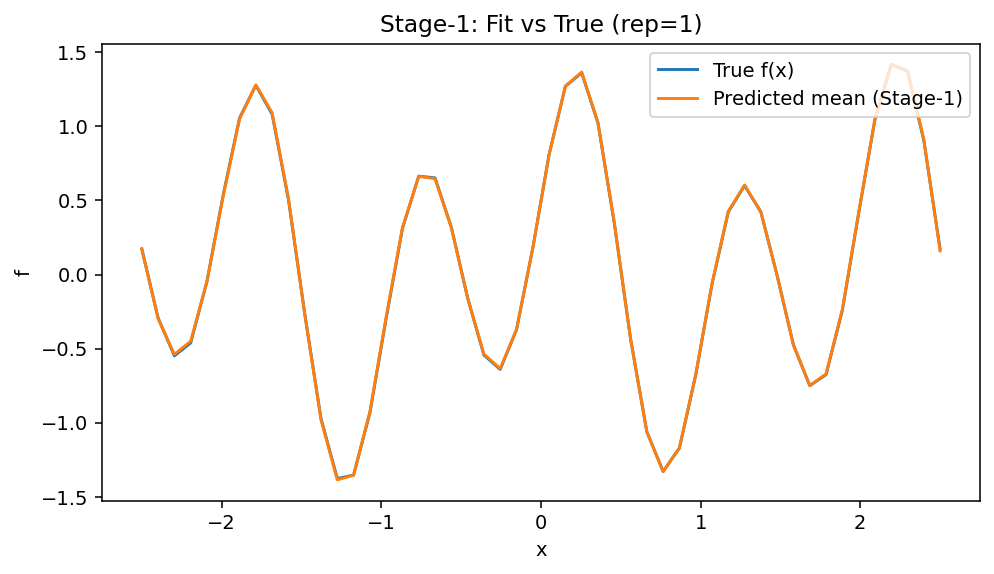

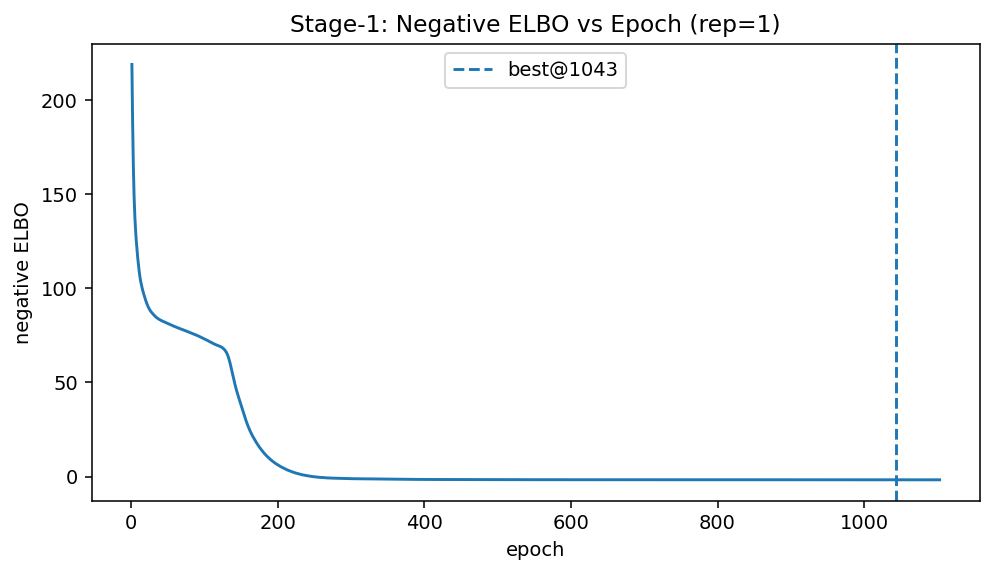

[21:18:03] [rep 001/100] α=1.000 (Stage-2) | best -ELBO=-1.756879 @epoch 805 | MSE=0.000033
[21:18:27] [rep 001/100] α=0.800 (Stage-2) | best -ELBO=-1.706183 @epoch 1365 | MSE=0.000033
[21:18:50] [rep 001/100] α=0.600 (Stage-2) | best -ELBO=-1.623867 @epoch 1002 | MSE=0.000033
[21:19:14] [rep 001/100] α=0.500 (Stage-2) | best -ELBO=-1.559761 @epoch 1368 | MSE=0.000033
[21:19:38] [rep 001/100] α=0.300 (Stage-2) | best -ELBO=-1.309514 @epoch 1090 | MSE=0.000033
[21:20:01] [rep 001/100] α=0.100 (Stage-2) | best -ELBO=-0.154401 @epoch 1175 | MSE=0.000033
[21:20:24] [rep 001/100] α=0.001 (Stage-2) | best -ELBO=117.601382 @epoch 1187 | MSE=0.000033
[21:20:39] [rep 002/100] Stage-1 (α=1.000) | best -ELBO=-1.725814 @epoch 748 | MSE=0.000150
[21:21:03] [rep 002/100] α=1.000 (Stage-2) | best -ELBO=-1.733362 @epoch 1036 | MSE=0.000150
[21:21:27] [rep 002/100] α=0.800 (Stage-2) | best -ELBO=-1.681218 @epoch 1282 | MSE=0.000150
[21:21:50] [rep 002/100] α=0.600 (Stage-2) | best -ELBO=-1.595581 @epoc

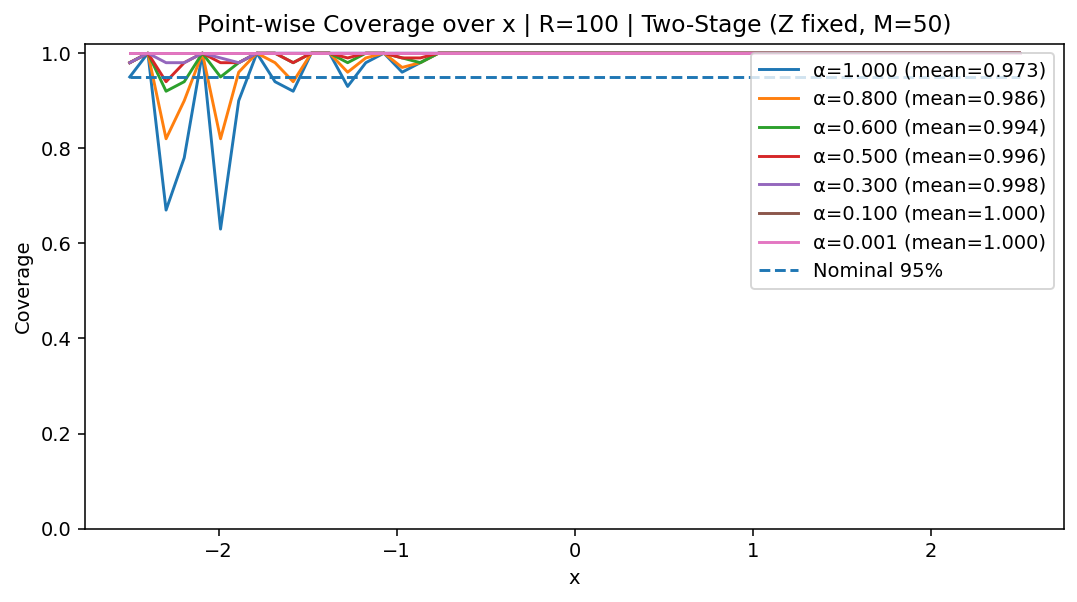

[01:45:00] 
=== Overall mean coverage (averaged over x) ===
[01:45:00]   alpha=1.000: mean coverage = 0.9728
[01:45:00]   alpha=0.800: mean coverage = 0.9860
[01:45:00]   alpha=0.600: mean coverage = 0.9940
[01:45:00]   alpha=0.500: mean coverage = 0.9962
[01:45:00]   alpha=0.300: mean coverage = 0.9982
[01:45:00]   alpha=0.100: mean coverage = 1.0000
[01:45:00]   alpha=0.001: mean coverage = 1.0000
[01:45:00] Saved indicator matrix with shape (7, 100, 50) to indicator_matrix_twostage.npy


In [24]:
# svgp_ciq_regression_alpha_suite_twostage.py
# Latent-f only; multi-replications; two-stage training:
#   Stage-1 (alpha=1): train everything (except fixed noise & fixed Z).
#   Stage-2 (alpha in CFG.alphas): load Stage-1 checkpoint, then train ONLY variational covariance with beta=1/alpha.
# Inducing points: M=50, fixed globally over all replications & alphas (not learnable).

import math
import os
import time
from contextlib import ExitStack
from dataclasses import dataclass

import torch
import gpytorch
import numpy as np
from torch.utils.data import DataLoader, TensorDataset

# =========================
# Logging helpers
# =========================
def now():
    return time.strftime("%H:%M:%S")

def log(msg):
    print(f"[{now()}] {msg}", flush=True)

def gpu_mem_mb():
    if torch.cuda.is_available():
        return torch.cuda.memory_allocated() / 1e6
    return 0.0

# =========================
# Utilities
# =========================
def has_setting(name: str) -> bool:
    return hasattr(gpytorch.settings, name)

def ciq_context():
    """Activate CIQ-related settings if supported; else no-op."""
    stack = ExitStack()
    for name, val in [
        ("num_contour_quadrature", 15),
        ("ciq_samples", 16),
        ("ciq_max_iter", 30),
        ("ciq_forward_precision", 0.01),
        ("eval_cg_tolerance", 1e-4),
        ("max_root_decomposition_size", 64),
    ]:
        if has_setting(name):
            stack.enter_context(getattr(gpytorch.settings, name)(val))
    stack.enter_context(gpytorch.settings.fast_pred_var(True))
    return stack

def clone_state_dict(sd):
    out = {}
    for k, v in sd.items():
        out[k] = v.detach().clone() if torch.is_tensor(v) else v
    return out

# True latent function (noiseless)
def f0(x: torch.Tensor) -> torch.Tensor:
    return torch.sin(2 * math.pi * x) + 0.5 * torch.cos(3 * x)

# ===== Stratified (LHS) sampling for 1D training inputs =====
def make_stratified_points_1d(n, low, high, generator, device, dtype):
    i = torch.arange(n, device=device, dtype=dtype)
    u = (i + torch.rand(n, generator=generator, device=device, dtype=dtype)) / n
    x = low + (high - low) * u
    perm = torch.randperm(n, generator=generator, device=device)
    return x[perm].unsqueeze(-1)

# =========================
# Config
# =========================
@dataclass
class CFG:
    # data sizes
    n_train: int = 500
    n_test: int = 50

    # single replication design range
    train_low: float = -2.5
    train_high: float = 2.5
    test_low: float = -2.5
    test_high: float = 2.5

    # training controls
    use_fp64: bool = True
    use_ciq: bool = False
    stage1_epochs: int = 5000
    stage2_epochs: int = 1500
    batch_size: int = 500  # full-batch
    inducing_points: int = 50  # <<< fixed globally
    lr_adam_stage1: float = 2e-2
    lr_adam_stage2: float = 2e-2
    jitter: float = 1e-2
    seed: int = 13

    # early stopping
    early_stop_patience: int = 60
    early_stop_min_delta: float = 1e-4

    # experiment factors
    alphas: tuple = (1.0, 0.8, 0.6, 0.5, 0.3, 0.1, 0.001)
    replications: int = 100

    # logging / plotting
    log_epoch: bool = False
    log_every: int = 10
    show_plots: bool = True
    save_plots: bool = True

# =========================
# Model (Z fixed; learn_inducing_locations=False)
# =========================
class SVGPModel(gpytorch.models.ApproximateGP):
    def __init__(self, inducing_points: torch.Tensor):
        M = inducing_points.size(0)
        q_dist = gpytorch.variational.CholeskyVariationalDistribution(M)
        q_strat = gpytorch.variational.VariationalStrategy(
            self, inducing_points, q_dist, learn_inducing_locations=False  # <<< FIXED Z
        )
        super().__init__(q_strat)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# =========================
# Param helpers (Two-stage)
# =========================
def freeze_all_params(model, likelihood):
    for p in model.parameters():
        p.requires_grad_(False)
    for p in likelihood.parameters():
        p.requires_grad_(False)

def pick_covariance_params_svgp(model):
    """
    返回“仅训练变分协方差”的参数列表（排除所有 *mean*；不碰 kernel/likelihood/Z）。
    兼容不同 GPyTorch 版本：优先访问 _variational_distribution 模块，
    若拿不到，则用名字匹配在整模搜索。
    """
    trainables, names = [], []

    # 1) 尝试直接拿到变分分布模块（nn.Module）
    vdist_mod = None
    vs = getattr(model, "variational_strategy", None)
    if vs is not None:
        # 新老版本兼容：优先下划线字段
        if hasattr(vs, "_variational_distribution"):
            vdist_mod = getattr(vs, "_variational_distribution")
        else:
            # 有些版本暴露 variational_distribution，但可能是 MultivariateNormal；要确认类型
            cand = getattr(vs, "variational_distribution", None)
            # 只有当它是 nn.Module/VariationalDistribution 才能 named_parameters
            if isinstance(cand, torch.nn.Module):
                vdist_mod = cand

    # 2) 如果拿到了模块，就在模块内部筛选
    if isinstance(vdist_mod, torch.nn.Module):
        for n, p in vdist_mod.named_parameters(recurse=True):
            low = n.lower()
            if "mean" in low:
                p.requires_grad_(False)
            elif any(k in low for k in ["chol", "std", "var", "covar", "factor"]):
                p.requires_grad_(True)
                trainables.append(p); names.append(f"vdist.{n}")
            else:
                # 默认不训练更安全
                p.requires_grad_(False)

    # 3) 兜底：在整模型里用名字匹配（尽量只限制在 variational_strategy 下）
    if not trainables:
        allow = (
            "chol_variational_covar",
            "variational_distribution.chol_covar",
            "variational_distribution._cholesky_factor",
            "_variational_distribution.chol_covar",
            "raw_covar",
            "chol_factor", "covar_factor",
            "variational_stddev", "raw_var",
            "qchol", "q_scale_tril"  # 额外常见命名
        )
        for n, p in model.named_parameters():
            low = n.lower()
            if "variational_strategy" in low and any(k in low for k in allow) and "mean" not in low:
                p.requires_grad_(True)
                trainables.append(p); names.append(n)

    return trainables, names


# =========================
# Stage-1 train (alpha=1), full model (except fixed noise & fixed Z)
# =========================
def stage1_train(
    model, likelihood, x_train_n, y_train, lr, epochs, jitter, batch_size,
    early_stop_patience, early_stop_min_delta, log_epoch=False, log_every=10
):
    N = x_train_n.size(0)
    mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=N, beta=1.0)

    # noise fixed (nugget)
    likelihood.noise_covar.raw_noise.requires_grad_(False)

    # optimizer: all model params + likelihood (except fixed noise & Z which has no grad anyway)
    opt = torch.optim.Adam([
        {"params": model.variational_parameters()},
        {"params": model.hyperparameters()},
        {"params": likelihood.parameters()},
    ], lr=lr)

    loader = DataLoader(TensorDataset(x_train_n, y_train),
                        batch_size=batch_size, shuffle=True, drop_last=False)

    model.train(); likelihood.train()

    neg_elbo_hist, best_loss, best_epoch = [], float("inf"), 0
    best_model_sd = clone_state_dict(model.state_dict())
    best_lik_sd = clone_state_dict(likelihood.state_dict())
    patience = 0

    with gpytorch.settings.cholesky_jitter(jitter):
        for ep in range(1, epochs + 1):
            total, n_batches = 0.0, 0
            for xb, yb in loader:
                opt.zero_grad(set_to_none=True)
                out = model(xb)
                loss = -mll(out, yb)
                if loss.numel() > 1:
                    loss = loss.mean()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                opt.step()
                total += float(loss.item()); n_batches += 1

            avg_loss = total / max(1, n_batches)
            neg_elbo_hist.append(avg_loss)

            if best_loss - avg_loss > early_stop_min_delta:
                best_loss, best_epoch = avg_loss, ep
                best_model_sd = clone_state_dict(model.state_dict())
                best_lik_sd = clone_state_dict(likelihood.state_dict())
                patience = 0
            else:
                patience += 1

            if log_epoch and (ep % log_every == 0 or ep == 1 or ep == epochs):
                log(f"  [Stage-1] epoch {ep:04d}/{epochs} | -ELBO={avg_loss:.6f} (best {best_loss:.6f}@{best_epoch})")

            if patience >= early_stop_patience:
                break

    # restore best
    model.load_state_dict(best_model_sd)
    likelihood.load_state_dict(best_lik_sd)
    model.eval(); likelihood.eval()
    return neg_elbo_hist, best_epoch, best_loss

# =========================
# Stage-2 train (beta=1/alpha), ONLY variational covariance
# =========================
def stage2_train_cov_only(
    model, likelihood, x_train_n, y_train, beta, lr, epochs, jitter, batch_size
):
    N = x_train_n.size(0)
    freeze_all_params(model, likelihood)  # freeze everything first

    # pick covariance params only
    cov_params, cov_names = pick_covariance_params_svgp(model)
    assert cov_params, "No covariance params found to train in Stage-2."

    mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=N, beta=beta)
    opt = torch.optim.Adam(cov_params, lr=lr)

    loader = DataLoader(TensorDataset(x_train_n, y_train),
                        batch_size=batch_size, shuffle=True, drop_last=False)

    model.train(); likelihood.train()

    neg_elbo_hist, best_loss, best_epoch = [], float("inf"), 0
    best_model_sd = clone_state_dict(model.state_dict())
    best_lik_sd = clone_state_dict(likelihood.state_dict())
    patience = 0  # optional early stop for stage-2 (shorter epochs used)

    with gpytorch.settings.cholesky_jitter(jitter):
        for ep in range(1, epochs + 1):
            total, n_batches = 0.0, 0
            for xb, yb in loader:
                opt.zero_grad(set_to_none=True)
                out = model(xb)
                loss = -mll(out, yb)
                if loss.numel() > 1:
                    loss = loss.mean()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(cov_params, 5.0)
                opt.step()
                total += float(loss.item()); n_batches += 1

            avg_loss = total / max(1, n_batches)
            neg_elbo_hist.append(avg_loss)

            # lightweight best tracking (no patience gate needed here; keep the best anyway)
            if avg_loss < best_loss:
                best_loss, best_epoch = avg_loss, ep
                best_model_sd = clone_state_dict(model.state_dict())
                best_lik_sd = clone_state_dict(likelihood.state_dict())

    model.load_state_dict(best_model_sd)
    likelihood.load_state_dict(best_lik_sd)
    model.eval(); likelihood.eval()
    return neg_elbo_hist, best_epoch, best_loss, cov_names

# =========================
# Main: run multiple replications with two-stage training
# =========================
def main():
    cfg = CFG()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    torch.set_default_dtype(torch.float64 if cfg.use_fp64 else torch.float32)
    torch.manual_seed(cfg.seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(cfg.seed)

    import matplotlib.pyplot as plt

    log(f"Device: {device} | dtype: {torch.get_default_dtype()}")
    if torch.cuda.is_available():
        log(f"CUDA mem (start): {gpu_mem_mb():.0f} MB")

    # Fixed test grid (J points) in RAW space
    x_test_raw = torch.linspace(cfg.test_low, cfg.test_high, cfg.n_test,
                                device=device, dtype=torch.get_default_dtype()).unsqueeze(1)
    y_test_true = f0(x_test_raw).squeeze(-1)
    J = cfg.n_test

    # ---------- Fixed inducing points in RAW space, shared by ALL reps/alphas ----------
    Z_raw = torch.linspace(cfg.train_low, cfg.train_high, cfg.inducing_points,
                           device=device, dtype=torch.get_default_dtype()).unsqueeze(1)

    # storage for coverage indicators: [A, R, J]
    alphas = list(cfg.alphas)
    A, R = len(alphas), cfg.replications
    indicators = np.zeros((A, R, J), dtype=np.float64)

    rep_to_plot = 0  # only plot Stage-1 diagnostics for the first replication

    for r in range(R):
        gen = torch.Generator(device=device).manual_seed(cfg.seed + r)
        x_train_raw = make_stratified_points_1d(
            n=cfg.n_train, low=cfg.train_low, high=cfg.train_high,
            generator=gen, device=device, dtype=torch.get_default_dtype()
        )
        y_train = f0(x_train_raw).squeeze(-1)

        # per-rep standardization (apply SAME transform to x_test & Z_raw)
        x_mean = x_train_raw.mean(0, keepdim=True)
        x_std  = x_train_raw.std(0, keepdim=True).clamp_min(1e-6)
        x_tr_n = (x_train_raw - x_mean) / x_std
        x_te_n = (x_test_raw  - x_mean) / x_std
        Z_n    = (Z_raw       - x_mean) / x_std  # <<< makes Z fixed across reps in RAW space

        # ====== Build fresh model/likelihood for Stage-1 ======
        model = SVGPModel(Z_n.clone().contiguous()).to(device=device)
        likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device=device)

        # Fixed tiny noise + sensible initial kernel scales
        with torch.no_grad():
            model.covar_module.base_kernel.lengthscale.fill_(1.0)
            model.covar_module.outputscale.fill_(1.0)
            likelihood.noise = torch.as_tensor(3e-3, dtype=torch.get_default_dtype(), device=device)
        likelihood.noise_covar.raw_noise.requires_grad_(False)

        # ====== STAGE-1: alpha=1 (beta=1) ======
        ctx = ciq_context() if cfg.use_ciq else ExitStack()
        with ctx:
            neg_elbo_hist_s1, best_epoch_s1, best_loss_s1 = stage1_train(
                model, likelihood, x_tr_n, y_train,
                lr=cfg.lr_adam_stage1, epochs=cfg.stage1_epochs, jitter=cfg.jitter,
                batch_size=cfg.batch_size,
                early_stop_patience=cfg.early_stop_patience,
                early_stop_min_delta=cfg.early_stop_min_delta,
                log_epoch=cfg.log_epoch, log_every=cfg.log_every
            )

        # ---- Stage-1 diagnostics (plot once per replication r==rep_to_plot) ----
        with torch.no_grad():
            pred_f = model(x_te_n)
            mu = pred_f.mean
            var = pred_f.variance
            mse_s1 = torch.mean((mu - y_test_true)**2).item()

        log(f"[rep {r+1:03d}/{R}] Stage-1 (α=1.000) | best -ELBO={best_loss_s1:.6f} @epoch {best_epoch_s1} | MSE={mse_s1:.6f}")

        if r == rep_to_plot:
            import matplotlib.pyplot as plt
            # Fit vs True
            plt.figure(figsize=(7.2, 4.2))
            plt.plot(x_test_raw.squeeze(-1).cpu(), y_test_true.cpu().numpy(), label="True f(x)")
            plt.plot(x_test_raw.squeeze(-1).cpu(), mu.cpu().numpy(), label="Predicted mean (Stage-1)")
            plt.title(f"Stage-1: Fit vs True (rep={r+1})")
            plt.xlabel("x"); plt.ylabel("f"); plt.legend(); plt.tight_layout()
            if cfg.save_plots:
                plt.savefig(f"stage1_fit_vs_true_rep{r+1}.png", dpi=150)
            if cfg.show_plots: plt.show()
            else: plt.close()

            # -ELBO curve (Stage-1)
            plt.figure(figsize=(7.2, 4.2))
            plt.plot(range(1, len(neg_elbo_hist_s1)+1), neg_elbo_hist_s1)
            plt.axvline(best_epoch_s1, linestyle="--", label=f"best@{best_epoch_s1}")
            plt.title(f"Stage-1: Negative ELBO vs Epoch (rep={r+1})")
            plt.xlabel("epoch"); plt.ylabel("negative ELBO"); plt.legend(); plt.tight_layout()
            if cfg.save_plots:
                plt.savefig(f"stage1_neg_elbo_rep{r+1}.png", dpi=150)
            if cfg.show_plots: plt.show()
            else: plt.close()

        # Save Stage-1 checkpoint (to reload before each alpha in Stage-2)
        s1_model_sd = clone_state_dict(model.state_dict())
        s1_lik_sd   = clone_state_dict(likelihood.state_dict())

        # ====== STAGE-2: loop over alphas, reload Stage-1, train cov only with beta=1/alpha ======
        for a_idx, alpha in enumerate(alphas):
            beta = 1.0 / alpha

            # reload Stage-1 state for a clean start per alpha
            model.load_state_dict(s1_model_sd)
            likelihood.load_state_dict(s1_lik_sd)
            model.eval(); likelihood.eval()

            with (ciq_context() if cfg.use_ciq else ExitStack()):
                neg_elbo_hist_s2, best_epoch_s2, best_loss_s2, cov_names = stage2_train_cov_only(
                    model, likelihood, x_tr_n, y_train,
                    beta=beta, lr=cfg.lr_adam_stage2, epochs=cfg.stage2_epochs,
                    jitter=cfg.jitter, batch_size=cfg.batch_size
                )

            with torch.no_grad():
                pred_f = model(x_te_n)
                mu = pred_f.mean
                var = pred_f.variance
                std = torch.sqrt(var).clamp_min(1e-12)
                f_true = y_test_true
                lower = mu - 1.96 * std
                upper = mu + 1.96 * std
                cover = ((f_true >= lower) & (f_true <= upper)).to(torch.float64)
                indicators[a_idx, r, :] = cover.cpu().numpy()
                mse = torch.mean((mu - f_true)**2).item()

            log(f"[rep {r+1:03d}/{R}] α={alpha:.3f} (Stage-2) | best -ELBO={best_loss_s2:.6f} @epoch {best_epoch_s2} | MSE={mse:.6f}")

    # =========================
    # Point-wise coverage: average across replications per alpha
    # =========================
    x_axis = x_test_raw.squeeze(-1).cpu().numpy()
    coverage_curves = indicators.mean(axis=1)     # [A, J]
    overall_cov = coverage_curves.mean(axis=1)    # [A]

    import matplotlib.pyplot as plt
    plt.figure(figsize=(7.8, 4.4))
    for a_idx, alpha in enumerate(alphas):
        plt.plot(x_axis, coverage_curves[a_idx], label=f"α={alpha:.3f} (mean={overall_cov[a_idx]:.3f})")
    plt.hlines(0.95, x_axis.min(), x_axis.max(), linestyles="--", label="Nominal 95%")
    plt.ylim(0.0, 1.02)
    plt.title(f"Point-wise Coverage over x | R={R} | Two-Stage (Z fixed, M={cfg.inducing_points})")
    plt.xlabel("x"); plt.ylabel("Coverage"); plt.legend(); plt.tight_layout()
    if cfg.save_plots:
        plt.savefig(f"coverage_curves_R{R}_twostage.png", dpi=150)
    if cfg.show_plots: plt.show()
    else: plt.close()

    log("\n=== Overall mean coverage (averaged over x) ===")
    for a_idx, alpha in enumerate(alphas):
        log(f"  alpha={alpha:.3f}: mean coverage = {overall_cov[a_idx]:.4f}")

    np.save("indicator_matrix_twostage.npy", indicators)
    log(f"Saved indicator matrix with shape {indicators.shape} to indicator_matrix_twostage.npy")

if __name__ == "__main__":
    main()


[03:25:43] Device: cuda | dtype: torch.float64
[03:25:43] CUDA mem (start): 68 MB
[03:25:52] [rep 001/100] Stage-1 (α=1.000) | best -ELBO=-1.708719 @epoch 634 | MSE=0.000286


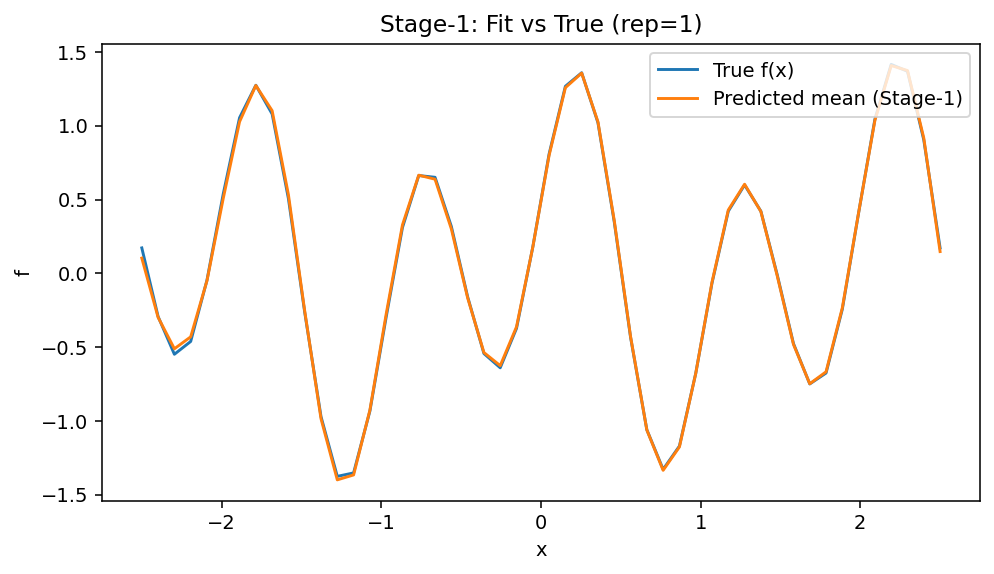

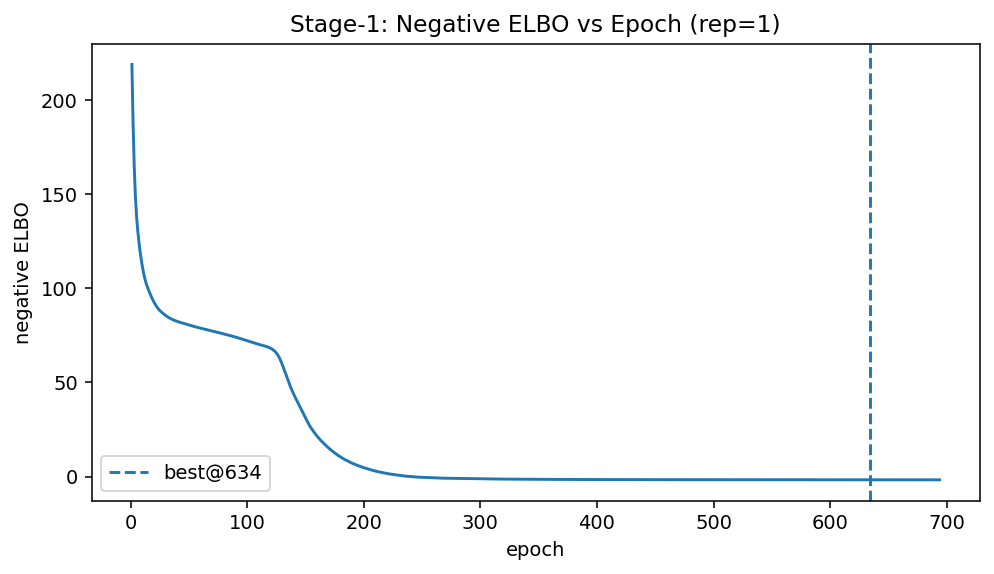

[03:26:11] [rep 001/100] α=1.000 (Stage-2) | best -ELBO=-1.716289 @epoch 1339 | MSE=0.000286
[03:26:27] [rep 001/100] α=0.800 (Stage-2) | best -ELBO=-1.663500 @epoch 1476 | MSE=0.000286
[03:26:45] [rep 001/100] α=0.600 (Stage-2) | best -ELBO=-1.577448 @epoch 1312 | MSE=0.000286
[03:27:03] [rep 001/100] α=0.500 (Stage-2) | best -ELBO=-1.509858 @epoch 1439 | MSE=0.000286
[03:27:21] [rep 001/100] α=0.300 (Stage-2) | best -ELBO=-1.247488 @epoch 1052 | MSE=0.000286
[03:27:47] [rep 001/100] α=0.100 (Stage-2) | best -ELBO=-0.029686 @epoch 1069 | MSE=0.000286
[03:28:13] [rep 001/100] α=0.001 (Stage-2) | best -ELBO=127.462379 @epoch 1482 | MSE=0.000286
[03:28:31] [rep 002/100] Stage-1 (α=1.000) | best -ELBO=-1.743595 @epoch 886 | MSE=0.000065
[03:28:57] [rep 002/100] α=1.000 (Stage-2) | best -ELBO=-1.748616 @epoch 1299 | MSE=0.000065
[03:29:20] [rep 002/100] α=0.800 (Stage-2) | best -ELBO=-1.697180 @epoch 1491 | MSE=0.000065
[03:29:46] [rep 002/100] α=0.600 (Stage-2) | best -ELBO=-1.613357 @epo

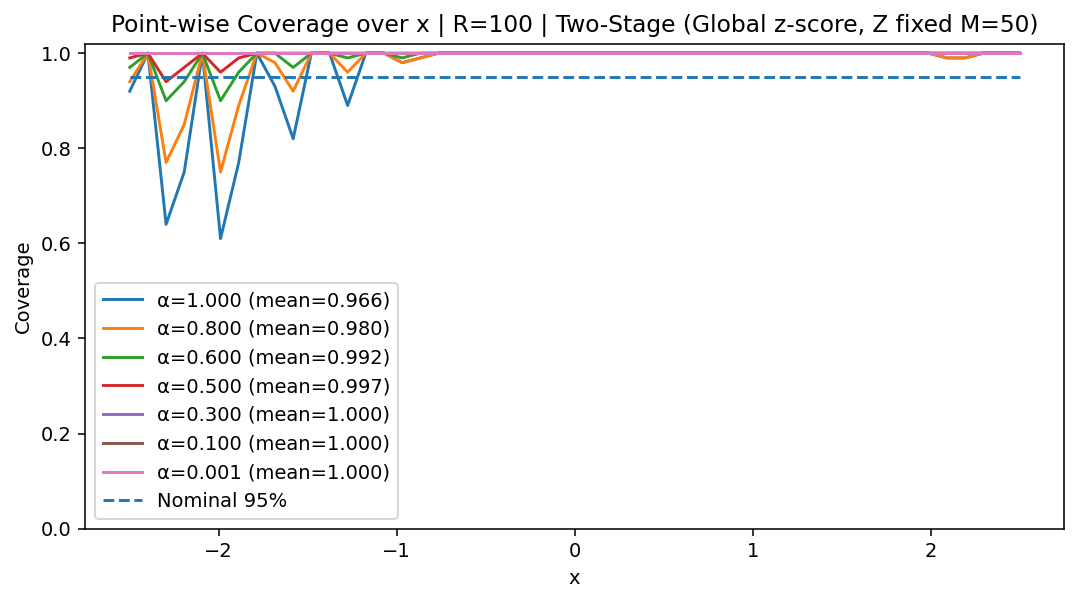

[08:43:00] 
=== Overall mean coverage (averaged over x) ===
[08:43:00]   alpha=1.000: mean coverage = 0.9656
[08:43:00]   alpha=0.800: mean coverage = 0.9802
[08:43:00]   alpha=0.600: mean coverage = 0.9924
[08:43:00]   alpha=0.500: mean coverage = 0.9970
[08:43:00]   alpha=0.300: mean coverage = 1.0000
[08:43:00]   alpha=0.100: mean coverage = 1.0000
[08:43:00]   alpha=0.001: mean coverage = 1.0000
[08:43:00] Saved indicator matrix with shape (7, 100, 50) to indicator_matrix_twostage_globalstd.npy


In [25]:
# svgp_ciq_regression_alpha_suite_twostage_globalstd.py
# Latent-f only; Two-stage SVGP with GLOBAL z-score (no per-rep standardization).
# - Fix train/test once; compute global (mu, sigma) on train; apply to train/test/Z once.
# - Stage-1 (alpha=1): train kernel + variational mean (noise fixed; Z fixed).
# - Stage-2 (alphas): reload Stage-1, train ONLY variational covariance with beta=1/alpha.
# Inducing points: M=50 (raw-space uniform grid mapped once via global z-score), fixed & not learnable.
# Replications differ only by optimization randomness (model init/optimizer shuffles).

import math, time
from contextlib import ExitStack
from dataclasses import dataclass

import torch, gpytorch
import numpy as np
from torch.utils.data import DataLoader, TensorDataset

# ----------------- logging -----------------
def now(): return time.strftime("%H:%M:%S")
def log(msg): print(f"[{now()}] {msg}", flush=True)
def gpu_mem_mb(): return (torch.cuda.memory_allocated()/1e6) if torch.cuda.is_available() else 0.0

# ----------------- helpers -----------------
def has_setting(name: str) -> bool: return hasattr(gpytorch.settings, name)

def ciq_context():
    stack = ExitStack()
    for name, val in [
        ("num_contour_quadrature", 15),
        ("ciq_samples", 16),
        ("ciq_max_iter", 30),
        ("ciq_forward_precision", 0.01),
        ("eval_cg_tolerance", 1e-4),
        ("max_root_decomposition_size", 64),
    ]:
        if has_setting(name):
            stack.enter_context(getattr(gpytorch.settings, name)(val))
    stack.enter_context(gpytorch.settings.fast_pred_var(True))
    return stack

def clone_state_dict(sd):
    out = {}
    for k, v in sd.items():
        out[k] = v.detach().clone() if torch.is_tensor(v) else v
    return out

# true latent f (noiseless)
def f0(x: torch.Tensor) -> torch.Tensor:
    return torch.sin(2 * math.pi * x) + 0.5 * torch.cos(3 * x)

# 1D stratified (LHS-like) points — used ONCE globally
def make_stratified_points_1d(n, low, high, generator, device, dtype):
    i = torch.arange(n, device=device, dtype=dtype)
    u = (i + torch.rand(n, generator=generator, device=device, dtype=dtype)) / n
    x = low + (high - low) * u
    perm = torch.randperm(n, generator=generator, device=device)
    return x[perm].unsqueeze(-1)

# ----------------- config -----------------
@dataclass
class CFG:
    # data
    n_train: int = 500
    n_test: int = 50
    train_low: float = -2.5
    train_high: float = 2.5
    test_low: float = -2.5
    test_high: float = 2.5

    # model/train
    use_fp64: bool = True
    use_ciq: bool = False
    inducing_points: int = 50
    stage1_epochs: int = 5000
    stage2_epochs: int = 1500
    batch_size: int = 500
    lr_adam_stage1: float = 2e-2
    lr_adam_stage2: float = 2e-2
    jitter: float = 1e-2
    seed: int = 13

    # early stopping
    early_stop_patience: int = 60
    early_stop_min_delta: float = 1e-4

    # experiment
    alphas: tuple = (1.0, 0.8, 0.6, 0.5, 0.3, 0.1, 0.001)
    replications: int = 100

    # logging/plots
    log_epoch: bool = False
    log_every: int = 10
    show_plots: bool = True
    save_plots: bool = True

# ----------------- model -----------------
class SVGPModel(gpytorch.models.ApproximateGP):
    def __init__(self, inducing_points_std: torch.Tensor):
        M = inducing_points_std.size(0)
        q_dist = gpytorch.variational.CholeskyVariationalDistribution(M)
        q_strat = gpytorch.variational.VariationalStrategy(
            self, inducing_points_std, q_dist, learn_inducing_locations=False
        )
        super().__init__(q_strat)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

    def forward(self, x_std):
        mean_x = self.mean_module(x_std)
        covar_x = self.covar_module(x_std)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# ----------------- two-stage param helpers -----------------
def freeze_all_params(model, likelihood):
    for p in model.parameters(): p.requires_grad_(False)
    for p in likelihood.parameters(): p.requires_grad_(False)

def pick_covariance_params_svgp(model):
    """Select ONLY variational covariance parameters (exclude any '*mean*')."""
    trainables, names = [], []
    vdist_mod = None
    vs = getattr(model, "variational_strategy", None)
    if vs is not None:
        if hasattr(vs, "_variational_distribution"):
            vdist_mod = getattr(vs, "_variational_distribution")
        else:
            cand = getattr(vs, "variational_distribution", None)
            if isinstance(cand, torch.nn.Module):
                vdist_mod = cand
    if isinstance(vdist_mod, torch.nn.Module):
        for n, p in vdist_mod.named_parameters(recurse=True):
            low = n.lower()
            if "mean" in low:
                p.requires_grad_(False)
            elif any(k in low for k in ["chol", "std", "var", "covar", "factor"]):
                p.requires_grad_(True); trainables.append(p); names.append(f"vdist.{n}")
            else:
                p.requires_grad_(False)
    if not trainables:
        allow = (
            "chol_variational_covar","variational_distribution.chol_covar",
            "variational_distribution._cholesky_factor","_variational_distribution.chol_covar",
            "raw_covar","chol_factor","covar_factor","variational_stddev","raw_var",
            "qchol","q_scale_tril"
        )
        for n, p in model.named_parameters():
            low = n.lower()
            if "variational_strategy" in low and any(k in low for k in allow) and "mean" not in low:
                p.requires_grad_(True); trainables.append(p); names.append(n)
    return trainables, names

# ----------------- Stage-1 -----------------
def stage1_train(model, likelihood, x_train_std, y_train, lr, epochs, jitter, batch_size,
                 early_stop_patience, early_stop_min_delta, log_epoch=False, log_every=10):
    N = x_train_std.size(0)
    mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=N, beta=1.0)

    likelihood.noise_covar.raw_noise.requires_grad_(False)
    opt = torch.optim.Adam([
        {"params": model.variational_parameters()},
        {"params": model.hyperparameters()},
        {"params": likelihood.parameters()},
    ], lr=lr)

    loader = DataLoader(TensorDataset(x_train_std, y_train),
                        batch_size=batch_size, shuffle=True, drop_last=False)

    model.train(); likelihood.train()
    neg_elbo_hist, best_loss, best_epoch = [], float("inf"), 0
    best_model_sd = clone_state_dict(model.state_dict())
    best_lik_sd   = clone_state_dict(likelihood.state_dict())
    patience = 0

    with gpytorch.settings.cholesky_jitter(jitter):
        for ep in range(1, epochs + 1):
            total, n_batches = 0.0, 0
            for xb, yb in loader:
                opt.zero_grad(set_to_none=True)
                out = model(xb)
                loss = -mll(out, yb)
                if loss.numel() > 1: loss = loss.mean()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                opt.step()
                total += float(loss.item()); n_batches += 1
            avg_loss = total / max(1, n_batches)
            neg_elbo_hist.append(avg_loss)

            if best_loss - avg_loss > early_stop_min_delta:
                best_loss, best_epoch = avg_loss, ep
                best_model_sd = clone_state_dict(model.state_dict())
                best_lik_sd   = clone_state_dict(likelihood.state_dict())
                patience = 0
            else:
                patience += 1

            if log_epoch and (ep % log_every == 0 or ep == 1 or ep == epochs):
                log(f"[S1] epoch {ep:04d}/{epochs} | -ELBO={avg_loss:.6f} (best {best_loss:.6f}@{best_epoch})")

            if patience >= early_stop_patience: break

    model.load_state_dict(best_model_sd)
    likelihood.load_state_dict(best_lik_sd)
    model.eval(); likelihood.eval()
    return neg_elbo_hist, best_epoch, best_loss

# ----------------- Stage-2 -----------------
def stage2_train_cov_only(model, likelihood, x_train_std, y_train, beta, lr, epochs, jitter, batch_size):
    N = x_train_std.size(0)
    freeze_all_params(model, likelihood)
    cov_params, cov_names = pick_covariance_params_svgp(model)
    assert cov_params, "No covariance params found to train in Stage-2."
    mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=N, beta=beta)
    opt = torch.optim.Adam(cov_params, lr=lr)

    loader = DataLoader(TensorDataset(x_train_std, y_train),
                        batch_size=batch_size, shuffle=True, drop_last=False)

    model.train(); likelihood.train()
    neg_elbo_hist, best_loss, best_epoch = [], float("inf"), 0
    best_model_sd = clone_state_dict(model.state_dict())
    best_lik_sd   = clone_state_dict(likelihood.state_dict())

    with gpytorch.settings.cholesky_jitter(jitter):
        for ep in range(1, epochs + 1):
            total, n_batches = 0.0, 0
            for xb, yb in loader:
                opt.zero_grad(set_to_none=True)
                out = model(xb)
                loss = -mll(out, yb)
                if loss.numel() > 1: loss = loss.mean()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(cov_params, 5.0)
                opt.step()
                total += float(loss.item()); n_batches += 1
            avg_loss = total / max(1, n_batches)
            neg_elbo_hist.append(avg_loss)
            if avg_loss < best_loss:
                best_loss, best_epoch = avg_loss, ep
                best_model_sd = clone_state_dict(model.state_dict())
                best_lik_sd   = clone_state_dict(likelihood.state_dict())

    model.load_state_dict(best_model_sd)
    likelihood.load_state_dict(best_lik_sd)
    model.eval(); likelihood.eval()
    return neg_elbo_hist, best_epoch, best_loss, cov_names

# ----------------- main -----------------
def main():
    cfg = CFG()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    torch.set_default_dtype(torch.float64 if cfg.use_fp64 else torch.float32)

    # global seeds for data construction
    torch.manual_seed(cfg.seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(cfg.seed)

    import matplotlib.pyplot as plt
    log(f"Device: {device} | dtype: {torch.get_default_dtype()}")
    if torch.cuda.is_available(): log(f"CUDA mem (start): {gpu_mem_mb():.0f} MB")

    # --------- 1) Build GLOBAL train/test once in RAW space ---------
    gen = torch.Generator(device=device).manual_seed(cfg.seed)
    x_train_raw = make_stratified_points_1d(
        n=cfg.n_train, low=cfg.train_low, high=cfg.train_high,
        generator=gen, device=device, dtype=torch.get_default_dtype()
    )
    x_test_raw = torch.linspace(cfg.test_low, cfg.test_high, cfg.n_test,
                                device=device, dtype=torch.get_default_dtype()).unsqueeze(1)
    y_train = f0(x_train_raw).squeeze(-1)
    y_test_true = f0(x_test_raw).squeeze(-1)

    # --------- 2) GLOBAL z-score (one-time) for train/test/Z ---------
    mu = x_train_raw.mean(0, keepdim=True)
    sigma = x_train_raw.std(0, keepdim=True).clamp_min(1e-6)

    x_train_std = (x_train_raw - mu) / sigma
    x_test_std  = (x_test_raw  - mu) / sigma

    # Fixed raw-space Z then mapped ONCE via the same global (mu, sigma)
    Z_raw = torch.linspace(cfg.train_low, cfg.train_high, cfg.inducing_points,
                           device=device, dtype=torch.get_default_dtype()).unsqueeze(1)
    Z_std = (Z_raw - mu) / sigma  # <- fixed across all reps/alphas

    # --------- alloc coverage storage ---------
    alphas = list(cfg.alphas)
    A, R, J = len(alphas), cfg.replications, cfg.n_test
    indicators = np.zeros((A, R, J), dtype=np.float64)

    rep_to_plot = 0  # plot Stage-1 diagnostics only for first replication

    # --------- Replications (data fixed; randomness only in optimization/init) ---------
    for r in range(R):
        # per-rep seed to vary init/shuffle deterministically
        torch.manual_seed(cfg.seed + 1000 + r)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(cfg.seed + 1000 + r)

        # fresh model/likelihood per replication (Z_std fixed; not learnable)
        model = SVGPModel(Z_std.clone().contiguous()).to(device=device)
        likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device=device)

        with torch.no_grad():
            model.covar_module.base_kernel.lengthscale.fill_(1.0)
            model.covar_module.outputscale.fill_(1.0)
            likelihood.noise = torch.as_tensor(3e-3, dtype=torch.get_default_dtype(), device=device)
        likelihood.noise_covar.raw_noise.requires_grad_(False)

        # ---- Stage-1 (alpha=1, beta=1) on GLOBAL-standardized x ----
        with (ciq_context() if cfg.use_ciq else ExitStack()):
            neg_elbo_hist_s1, best_epoch_s1, best_loss_s1 = stage1_train(
                model, likelihood, x_train_std, y_train,
                lr=cfg.lr_adam_stage1, epochs=cfg.stage1_epochs, jitter=cfg.jitter,
                batch_size=cfg.batch_size,
                early_stop_patience=cfg.early_stop_patience,
                early_stop_min_delta=cfg.early_stop_min_delta,
                log_epoch=cfg.log_epoch, log_every=cfg.log_every
            )

        with torch.no_grad():
            pred_f = model(x_test_std)
            mu_pred = pred_f.mean
            mse_s1 = torch.mean((mu_pred - y_test_true)**2).item()

        log(f"[rep {r+1:03d}/{R}] Stage-1 (α=1.000) | best -ELBO={best_loss_s1:.6f} @epoch {best_epoch_s1} | MSE={mse_s1:.6f}")

        if r == rep_to_plot:
            # Fit vs True (Stage-1)
            plt.figure(figsize=(7.2, 4.2))
            plt.plot(x_test_raw.squeeze(-1).cpu(), y_test_true.cpu().numpy(), label="True f(x)")
            plt.plot(x_test_raw.squeeze(-1).cpu(), mu_pred.cpu().numpy(), label="Predicted mean (Stage-1)")
            plt.title(f"Stage-1: Fit vs True (rep={r+1})")
            plt.xlabel("x"); plt.ylabel("f"); plt.legend(); plt.tight_layout()
            if cfg.save_plots: plt.savefig(f"stage1_fit_vs_true_rep{r+1}_globalstd.png", dpi=150)
            if cfg.show_plots: plt.show()
            else: plt.close()

            # -ELBO curve (Stage-1)
            plt.figure(figsize=(7.2, 4.2))
            plt.plot(range(1, len(neg_elbo_hist_s1)+1), neg_elbo_hist_s1)
            plt.axvline(best_epoch_s1, linestyle="--", label=f"best@{best_epoch_s1}")
            plt.title(f"Stage-1: Negative ELBO vs Epoch (rep={r+1})")
            plt.xlabel("epoch"); plt.ylabel("negative ELBO"); plt.legend(); plt.tight_layout()
            if cfg.save_plots: plt.savefig(f"stage1_neg_elbo_rep{r+1}_globalstd.png", dpi=150)
            if cfg.show_plots: plt.show()
            else: plt.close()

        # checkpoint after Stage-1
        s1_model_sd = clone_state_dict(model.state_dict())
        s1_lik_sd   = clone_state_dict(likelihood.state_dict())

        # ---- Stage-2 for each alpha (only variational covariance) ----
        for a_idx, alpha in enumerate(alphas):
            beta = 1.0 / alpha
            model.load_state_dict(s1_model_sd)
            likelihood.load_state_dict(s1_lik_sd)
            model.eval(); likelihood.eval()

            with (ciq_context() if cfg.use_ciq else ExitStack()):
                neg_elbo_hist_s2, best_epoch_s2, best_loss_s2, cov_names = stage2_train_cov_only(
                    model, likelihood, x_train_std, y_train,
                    beta=beta, lr=cfg.lr_adam_stage2, epochs=cfg.stage2_epochs,
                    jitter=cfg.jitter, batch_size=cfg.batch_size
                )

            with torch.no_grad():
                pred_f = model(x_test_std)
                mu = pred_f.mean
                std = pred_f.variance.sqrt().clamp_min(1e-12)
                lower, upper = mu - 1.96*std, mu + 1.96*std
                cover = ((y_test_true >= lower) & (y_test_true <= upper)).to(torch.float64)
                indicators[a_idx, r, :] = cover.cpu().numpy()
                mse = torch.mean((mu - y_test_true)**2).item()

            log(f"[rep {r+1:03d}/{R}] α={alpha:.3f} (Stage-2) | best -ELBO={best_loss_s2:.6f} @epoch {best_epoch_s2} | MSE={mse:.6f}")

    # ---- coverage curves ----
    x_axis = x_test_raw.squeeze(-1).cpu().numpy()
    coverage_curves = indicators.mean(axis=1)   # [A, J]
    overall_cov = coverage_curves.mean(axis=1)  # [A]

    import matplotlib.pyplot as plt
    plt.figure(figsize=(7.8, 4.4))
    for a_idx, alpha in enumerate(alphas):
        plt.plot(x_axis, coverage_curves[a_idx], label=f"α={alpha:.3f} (mean={overall_cov[a_idx]:.3f})")
    plt.hlines(0.95, x_axis.min(), x_axis.max(), linestyles="--", label="Nominal 95%")
    plt.ylim(0.0, 1.02)
    plt.title(f"Point-wise Coverage over x | R={cfg.replications} | Two-Stage (Global z-score, Z fixed M={cfg.inducing_points})")
    plt.xlabel("x"); plt.ylabel("Coverage"); plt.legend(); plt.tight_layout()
    if cfg.save_plots: plt.savefig(f"coverage_curves_R{cfg.replications}_twostage_globalstd.png", dpi=150)
    if cfg.show_plots: plt.show()
    else: plt.close()

    log("\n=== Overall mean coverage (averaged over x) ===")
    for a_idx, alpha in enumerate(alphas):
        log(f"  alpha={alpha:.3f}: mean coverage = {overall_cov[a_idx]:.4f}")

    np.save("indicator_matrix_twostage_globalstd.npy", indicators)
    log(f"Saved indicator matrix with shape {indicators.shape} to indicator_matrix_twostage_globalstd.npy")

if __name__ == "__main__":
    main()


[01:57:54] Device: cuda | dtype: torch.float64
[01:57:54] CUDA mem (start): 68 MB
[01:57:54] Symmetric normalization: raw [-2.50, 2.50] -> std [-1.00, 1.00] (expect -1, +1)
[01:57:54] Z_std head/tail: -1.000, 1.000
[01:58:07] [rep 001/100] Stage-1 (α=1.000) | best -ELBO=-1.711596 @epoch 852 | MSE=0.000089


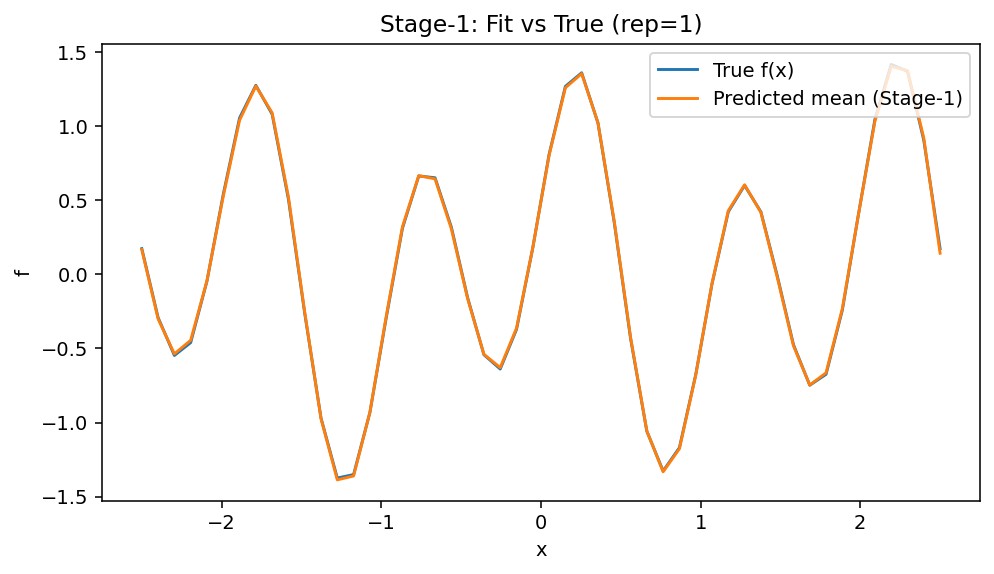

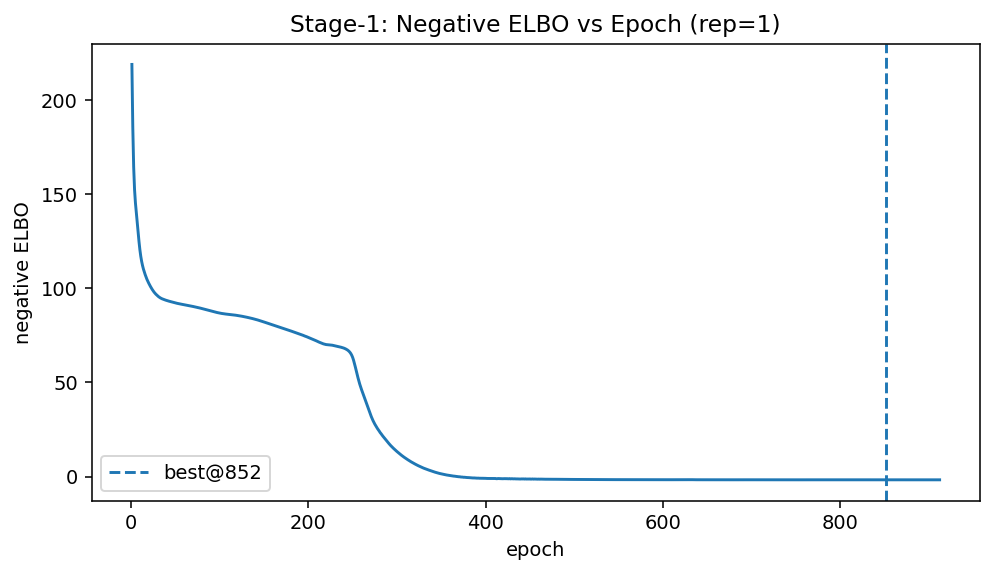

[01:58:33] [rep 001/100] α=1.000 (Stage-2) | best -ELBO=-1.720945 @epoch 1059 | MSE=0.000089
[01:58:33] [Checker] α=1.000: fraction(|bias|>band)=0.000; worst at x≈-1.888


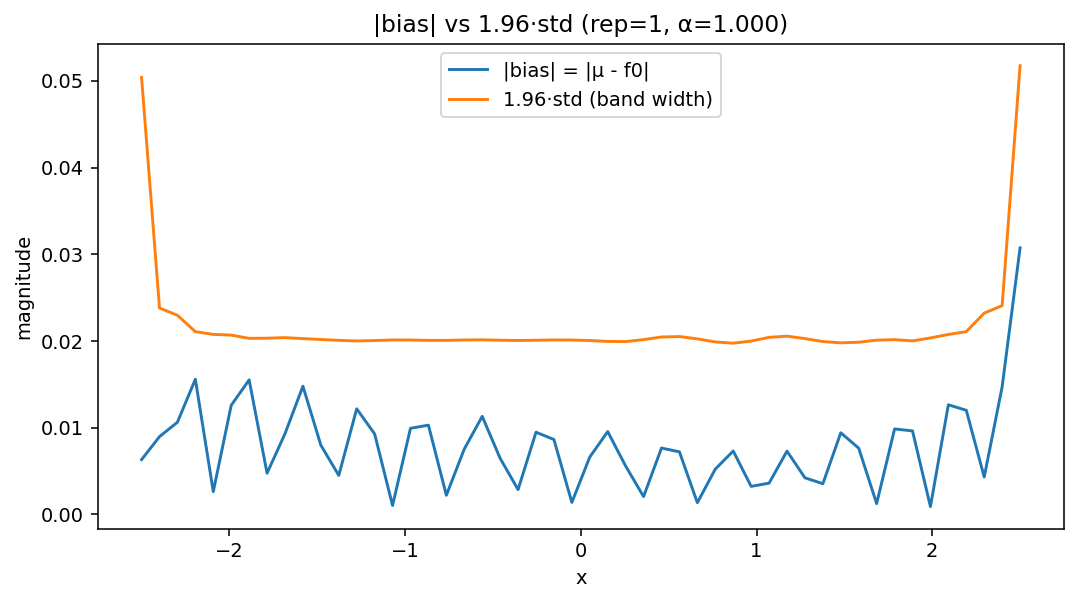

[01:58:59] [rep 001/100] α=0.800 (Stage-2) | best -ELBO=-1.663329 @epoch 1399 | MSE=0.000089
[01:59:25] [rep 001/100] α=0.600 (Stage-2) | best -ELBO=-1.568285 @epoch 792 | MSE=0.000089
[01:59:50] [rep 001/100] α=0.500 (Stage-2) | best -ELBO=-1.494149 @epoch 1201 | MSE=0.000089
[02:00:15] [rep 001/100] α=0.300 (Stage-2) | best -ELBO=-1.203620 @epoch 1249 | MSE=0.000089
[02:00:39] [rep 001/100] α=0.100 (Stage-2) | best -ELBO=0.155394 @epoch 1473 | MSE=0.000089
[02:01:05] [rep 001/100] α=0.001 (Stage-2) | best -ELBO=150.329333 @epoch 864 | MSE=0.000089
[02:01:05] [Checker] α=0.001: fraction(|bias|>band)=0.000; worst at x≈-1.276


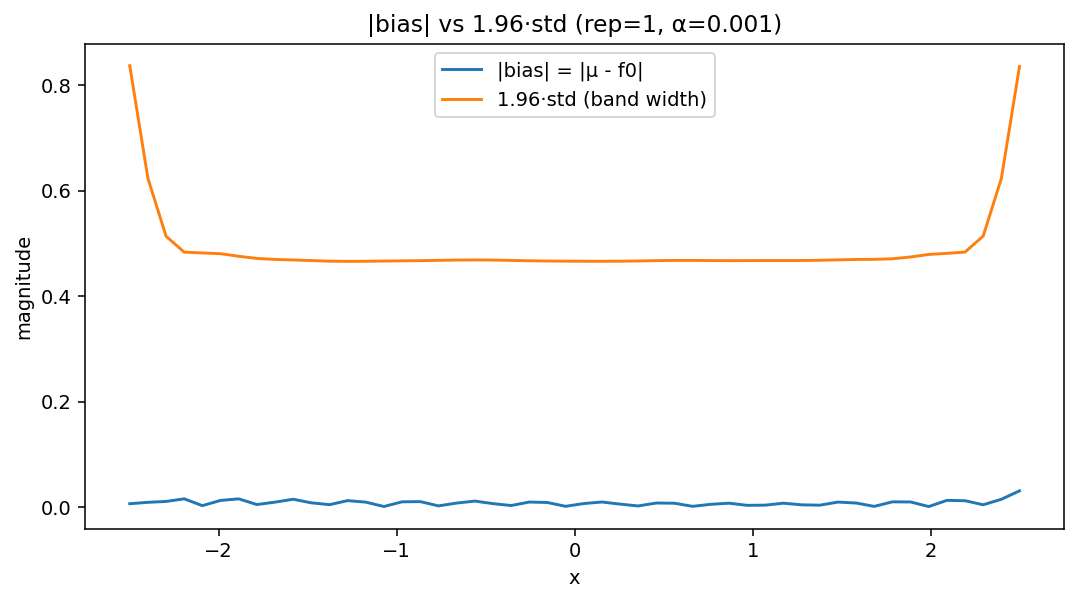

[02:01:26] [rep 002/100] Stage-1 (α=1.000) | best -ELBO=-1.725497 @epoch 1022 | MSE=0.000058
[02:01:51] [rep 002/100] α=1.000 (Stage-2) | best -ELBO=-1.732751 @epoch 1427 | MSE=0.000058
[02:02:16] [rep 002/100] α=0.800 (Stage-2) | best -ELBO=-1.676348 @epoch 992 | MSE=0.000058
[02:02:41] [rep 002/100] α=0.600 (Stage-2) | best -ELBO=-1.584922 @epoch 773 | MSE=0.000058
[02:03:07] [rep 002/100] α=0.500 (Stage-2) | best -ELBO=-1.512913 @epoch 1070 | MSE=0.000058
[02:03:32] [rep 002/100] α=0.300 (Stage-2) | best -ELBO=-1.232097 @epoch 1061 | MSE=0.000058
[02:03:57] [rep 002/100] α=0.100 (Stage-2) | best -ELBO=0.079268 @epoch 1270 | MSE=0.000058
[02:04:23] [rep 002/100] α=0.001 (Stage-2) | best -ELBO=142.774091 @epoch 1149 | MSE=0.000058
[02:04:42] [rep 003/100] Stage-1 (α=1.000) | best -ELBO=-1.716481 @epoch 912 | MSE=0.000074
[02:05:07] [rep 003/100] α=1.000 (Stage-2) | best -ELBO=-1.725307 @epoch 1060 | MSE=0.000074
[02:05:32] [rep 003/100] α=0.800 (Stage-2) | best -ELBO=-1.668121 @epoch 

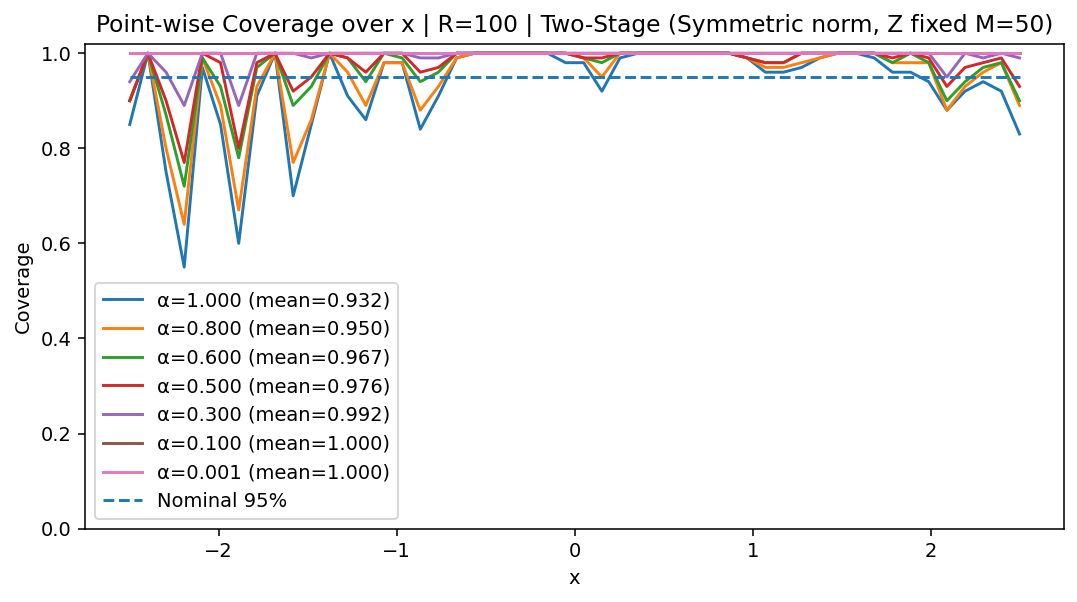

[07:10:51] 
=== Overall mean coverage (averaged over x) ===
[07:10:51]   alpha=1.000: mean coverage = 0.9316
[07:10:51]   alpha=0.800: mean coverage = 0.9496
[07:10:51]   alpha=0.600: mean coverage = 0.9674
[07:10:51]   alpha=0.500: mean coverage = 0.9758
[07:10:51]   alpha=0.300: mean coverage = 0.9916
[07:10:51]   alpha=0.100: mean coverage = 1.0000
[07:10:51]   alpha=0.001: mean coverage = 1.0000
[07:10:51] Saved indicator matrix with shape (7, 100, 50) to indicator_matrix_twostage_symnorm.npy


In [26]:
# svgp_ciq_regression_alpha_suite_twostage_symnorm.py
# Two-stage SVGP (latent-f only) with SYMMETRIC LINEAR NORMALIZATION (no z-score):
#   x_std = (x_raw - mid) / half  maps [train_low,train_high] -> [-1,1]
# Train/test/Z all use the SAME global transform. Z: M=50, fixed & not learnable.
# Stage-1 (alpha=1): train kernel + variational mean (noise fixed; Z fixed).
# Stage-2 (alphas): reload Stage-1, train ONLY variational covariance with beta=1/alpha.
# Adds a diagnostic checker: plots |bias| vs 1.96*std for alpha in {1.0, min_alphas} at rep=1.

import math, time
from contextlib import ExitStack
from dataclasses import dataclass

import torch, gpytorch
import numpy as np
from torch.utils.data import DataLoader, TensorDataset

# ------------- logging -------------
def now(): return time.strftime("%H:%M:%S")
def log(msg): print(f"[{now()}] {msg}", flush=True)
def gpu_mem_mb(): return (torch.cuda.memory_allocated()/1e6) if torch.cuda.is_available() else 0.0

# ------------- helpers -------------
def has_setting(name: str) -> bool: return hasattr(gpytorch.settings, name)

def ciq_context():
    stack = ExitStack()
    for name, val in [
        ("num_contour_quadrature", 15),
        ("ciq_samples", 16),
        ("ciq_max_iter", 30),
        ("ciq_forward_precision", 0.01),
        ("eval_cg_tolerance", 1e-4),
        ("max_root_decomposition_size", 64),
    ]:
        if has_setting(name):
            stack.enter_context(getattr(gpytorch.settings, name)(val))
    stack.enter_context(gpytorch.settings.fast_pred_var(True))
    return stack

def clone_state_dict(sd):
    out = {}
    for k, v in sd.items():
        out[k] = v.detach().clone() if torch.is_tensor(v) else v
    return out

# true latent f (noiseless)
def f0(x: torch.Tensor) -> torch.Tensor:
    return torch.sin(2 * math.pi * x) + 0.5 * torch.cos(3 * x)

# 1D stratified (LHS-like) points — used ONCE globally
def make_stratified_points_1d(n, low, high, generator, device, dtype):
    i = torch.arange(n, device=device, dtype=dtype)
    u = (i + torch.rand(n, generator=generator, device=device, dtype=dtype)) / n
    x = low + (high - low) * u
    perm = torch.randperm(n, generator=generator, device=device)
    return x[perm].unsqueeze(-1)

# ------------- config -------------
@dataclass
class CFG:
    # data
    n_train: int = 500
    n_test: int = 50
    train_low: float = -2.5
    train_high: float = 2.5
    test_low: float = -2.5
    test_high: float = 2.5

    # model/train
    use_fp64: bool = True
    use_ciq: bool = False
    inducing_points: int = 50
    stage1_epochs: int = 5000
    stage2_epochs: int = 1500
    batch_size: int = 500
    lr_adam_stage1: float = 2e-2
    lr_adam_stage2: float = 2e-2
    jitter: float = 1e-2
    seed: int = 13

    # early stopping
    early_stop_patience: int = 60
    early_stop_min_delta: float = 1e-4

    # experiment
    alphas: tuple = (1.0, 0.8, 0.6, 0.5, 0.3, 0.1, 0.001)
    replications: int = 100

    # logging/plots
    log_epoch: bool = False
    log_every: int = 10
    show_plots: bool = True
    save_plots: bool = True

# ------------- model -------------
class SVGPModel(gpytorch.models.ApproximateGP):
    def __init__(self, inducing_points_std: torch.Tensor):
        M = inducing_points_std.size(0)
        q_dist = gpytorch.variational.CholeskyVariationalDistribution(M)
        q_strat = gpytorch.variational.VariationalStrategy(
            self, inducing_points_std, q_dist, learn_inducing_locations=False
        )
        super().__init__(q_strat)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

    def forward(self, x_std):
        mean_x = self.mean_module(x_std)
        covar_x = self.covar_module(x_std)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# ------------- two-stage param helpers -------------
def freeze_all_params(model, likelihood):
    for p in model.parameters(): p.requires_grad_(False)
    for p in likelihood.parameters(): p.requires_grad_(False)

def pick_covariance_params_svgp(model):
    """Select ONLY variational covariance parameters (exclude any '*mean*')."""
    trainables, names = [], []
    vdist_mod = None
    vs = getattr(model, "variational_strategy", None)
    if vs is not None:
        if hasattr(vs, "_variational_distribution"):
            vdist_mod = getattr(vs, "_variational_distribution")
        else:
            cand = getattr(vs, "variational_distribution", None)
            if isinstance(cand, torch.nn.Module):
                vdist_mod = cand
    if isinstance(vdist_mod, torch.nn.Module):
        for n, p in vdist_mod.named_parameters(recurse=True):
            low = n.lower()
            if "mean" in low:
                p.requires_grad_(False)
            elif any(k in low for k in ["chol", "std", "var", "covar", "factor"]):
                p.requires_grad_(True); trainables.append(p); names.append(f"vdist.{n}")
            else:
                p.requires_grad_(False)
    if not trainables:
        allow = (
            "chol_variational_covar","variational_distribution.chol_covar",
            "variational_distribution._cholesky_factor","_variational_distribution.chol_covar",
            "raw_covar","chol_factor","covar_factor","variational_stddev","raw_var",
            "qchol","q_scale_tril"
        )
        for n, p in model.named_parameters():
            low = n.lower()
            if "variational_strategy" in low and any(k in low for k in allow) and "mean" not in low:
                p.requires_grad_(True); trainables.append(p); names.append(n)
    return trainables, names

# ------------- Stage-1 -------------
def stage1_train(model, likelihood, x_train_std, y_train, lr, epochs, jitter, batch_size,
                 early_stop_patience, early_stop_min_delta, log_epoch=False, log_every=10):
    N = x_train_std.size(0)
    mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=N, beta=1.0)

    likelihood.noise_covar.raw_noise.requires_grad_(False)
    opt = torch.optim.Adam([
        {"params": model.variational_parameters()},
        {"params": model.hyperparameters()},
        {"params": likelihood.parameters()},
    ], lr=lr)

    loader = DataLoader(TensorDataset(x_train_std, y_train),
                        batch_size=batch_size, shuffle=True, drop_last=False)

    model.train(); likelihood.train()
    neg_elbo_hist, best_loss, best_epoch = [], float("inf"), 0
    best_model_sd = clone_state_dict(model.state_dict())
    best_lik_sd   = clone_state_dict(likelihood.state_dict())
    patience = 0

    with gpytorch.settings.cholesky_jitter(jitter):
        for ep in range(1, epochs + 1):
            total, n_batches = 0.0, 0
            for xb, yb in loader:
                opt.zero_grad(set_to_none=True)
                out = model(xb)
                loss = -mll(out, yb)
                if loss.numel() > 1: loss = loss.mean()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                opt.step()
                total += float(loss.item()); n_batches += 1
            avg_loss = total / max(1, n_batches)
            neg_elbo_hist.append(avg_loss)

            if best_loss - avg_loss > early_stop_min_delta:
                best_loss, best_epoch = avg_loss, ep
                best_model_sd = clone_state_dict(model.state_dict())
                best_lik_sd   = clone_state_dict(likelihood.state_dict())
                patience = 0
            else:
                patience += 1

            if log_epoch and (ep % log_every == 0 or ep == 1 or ep == epochs):
                log(f"[S1] epoch {ep:04d}/{epochs} | -ELBO={avg_loss:.6f} (best {best_loss:.6f}@{best_epoch})")

            if patience >= early_stop_patience: break

    model.load_state_dict(best_model_sd)
    likelihood.load_state_dict(best_lik_sd)
    model.eval(); likelihood.eval()
    return neg_elbo_hist, best_epoch, best_loss

# ------------- Stage-2 -------------
def stage2_train_cov_only(model, likelihood, x_train_std, y_train, beta, lr, epochs, jitter, batch_size):
    N = x_train_std.size(0)
    freeze_all_params(model, likelihood)
    cov_params, cov_names = pick_covariance_params_svgp(model)
    assert cov_params, "No covariance params found to train in Stage-2."
    mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=N, beta=beta)
    opt = torch.optim.Adam(cov_params, lr=lr)

    loader = DataLoader(TensorDataset(x_train_std, y_train),
                        batch_size=batch_size, shuffle=True, drop_last=False)

    model.train(); likelihood.train()
    neg_elbo_hist, best_loss, best_epoch = [], float("inf"), 0
    best_model_sd = clone_state_dict(model.state_dict())
    best_lik_sd   = clone_state_dict(likelihood.state_dict())

    with gpytorch.settings.cholesky_jitter(jitter):
        for ep in range(1, epochs + 1):
            total, n_batches = 0.0, 0
            for xb, yb in loader:
                opt.zero_grad(set_to_none=True)
                out = model(xb)
                loss = -mll(out, yb)
                if loss.numel() > 1: loss = loss.mean()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(cov_params, 5.0)
                opt.step()
                total += float(loss.item()); n_batches += 1
            avg_loss = total / max(1, n_batches)
            neg_elbo_hist.append(avg_loss)
            if avg_loss < best_loss:
                best_loss, best_epoch = avg_loss, ep
                best_model_sd = clone_state_dict(model.state_dict())
                best_lik_sd   = clone_state_dict(likelihood.state_dict())

    model.load_state_dict(best_model_sd)
    likelihood.load_state_dict(best_lik_sd)
    model.eval(); likelihood.eval()
    return neg_elbo_hist, best_epoch, best_loss, cov_names

# ------------- main -------------
def main():
    cfg = CFG()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    torch.set_default_dtype(torch.float64 if cfg.use_fp64 else torch.float32)

    # seeds
    torch.manual_seed(cfg.seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(cfg.seed)

    import matplotlib.pyplot as plt
    log(f"Device: {device} | dtype: {torch.get_default_dtype()}")
    if torch.cuda.is_available(): log(f"CUDA mem (start): {gpu_mem_mb():.0f} MB")

    # ---- 1) GLOBAL fixed train/test (RAW) ----
    gen = torch.Generator(device=device).manual_seed(cfg.seed)
    x_train_raw = make_stratified_points_1d(
        n=cfg.n_train, low=cfg.train_low, high=cfg.train_high,
        generator=gen, device=device, dtype=torch.get_default_dtype()
    )
    x_test_raw = torch.linspace(cfg.test_low, cfg.test_high, cfg.n_test,
                                device=device, dtype=torch.get_default_dtype()).unsqueeze(1)
    y_train = f0(x_train_raw).squeeze(-1)
    y_test_true = f0(x_test_raw).squeeze(-1)

    # ---- 2) SYMMETRIC linear normalization (one-time) ----
    mid = torch.tensor([(cfg.train_low + cfg.train_high)/2.0],
                       device=device, dtype=torch.get_default_dtype())
    half = torch.tensor([(cfg.train_high - cfg.train_low)/2.0],
                        device=device, dtype=torch.get_default_dtype()).clamp_min(1e-12)

    def to_std(x_raw): return (x_raw - mid) / half

    x_train_std = to_std(x_train_raw)
    x_test_std  = to_std(x_test_raw)

    # fixed Z on raw -> map once to std (will become exactly linspace(-1,1))
    Z_raw = torch.linspace(cfg.train_low, cfg.train_high, cfg.inducing_points,
                           device=device, dtype=torch.get_default_dtype()).unsqueeze(1)
    Z_std = to_std(Z_raw)

    # log normalization map (checker #0)
    left_std, right_std = float(to_std(torch.tensor([[cfg.train_low]], device=device))), float(to_std(torch.tensor([[cfg.train_high]], device=device)))
    log(f"Symmetric normalization: raw [{cfg.train_low:.2f}, {cfg.train_high:.2f}] -> std [{left_std:.2f}, {right_std:.2f}] (expect -1, +1)")
    log(f"Z_std head/tail: {float(Z_std[0]):.3f}, {float(Z_std[-1]):.3f}")

    # ---- storage ----
    alphas = list(cfg.alphas)
    A, R, J = len(alphas), cfg.replications, cfg.n_test
    indicators = np.zeros((A, R, J), dtype=np.float64)
    rep_to_plot = 0
    smallest_alpha = min(alphas)

    for r in range(R):
        torch.manual_seed(cfg.seed + 1000 + r)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(cfg.seed + 1000 + r)

        model = SVGPModel(Z_std.clone().contiguous()).to(device=device)
        likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device=device)

        with torch.no_grad():
            model.covar_module.base_kernel.lengthscale.fill_(1.0)
            model.covar_module.outputscale.fill_(1.0)
            likelihood.noise = torch.as_tensor(3e-3, dtype=torch.get_default_dtype(), device=device)
        likelihood.noise_covar.raw_noise.requires_grad_(False)

        # ---- Stage-1 ----
        with (ciq_context() if cfg.use_ciq else ExitStack()):
            neg_elbo_hist_s1, best_epoch_s1, best_loss_s1 = stage1_train(
                model, likelihood, x_train_std, y_train,
                lr=cfg.lr_adam_stage1, epochs=cfg.stage1_epochs, jitter=cfg.jitter,
                batch_size=cfg.batch_size,
                early_stop_patience=cfg.early_stop_patience,
                early_stop_min_delta=cfg.early_stop_min_delta,
                log_epoch=cfg.log_epoch, log_every=cfg.log_every
            )

        with torch.no_grad():
            pred_f = model(x_test_std)
            mu_pred = pred_f.mean
            mse_s1 = torch.mean((mu_pred - y_test_true)**2).item()

        log(f"[rep {r+1:03d}/{R}] Stage-1 (α=1.000) | best -ELBO={best_loss_s1:.6f} @epoch {best_epoch_s1} | MSE={mse_s1:.6f}")

        if r == rep_to_plot:
            # plot fit vs truth
            plt.figure(figsize=(7.2, 4.2))
            plt.plot(x_test_raw.squeeze(-1).cpu(), y_test_true.cpu().numpy(), label="True f(x)")
            plt.plot(x_test_raw.squeeze(-1).cpu(), mu_pred.cpu().numpy(), label="Predicted mean (Stage-1)")
            plt.title(f"Stage-1: Fit vs True (rep={r+1})")
            plt.xlabel("x"); plt.ylabel("f"); plt.legend(); plt.tight_layout()
            if cfg.save_plots: plt.savefig(f"stage1_fit_vs_true_rep{r+1}_symnorm.png", dpi=150)
            if cfg.show_plots: plt.show()
            else: plt.close()

            # -ELBO curve
            plt.figure(figsize=(7.2, 4.2))
            plt.plot(range(1, len(neg_elbo_hist_s1)+1), neg_elbo_hist_s1)
            plt.axvline(best_epoch_s1, linestyle="--", label=f"best@{best_epoch_s1}")
            plt.title(f"Stage-1: Negative ELBO vs Epoch (rep={r+1})")
            plt.xlabel("epoch"); plt.ylabel("negative ELBO"); plt.legend(); plt.tight_layout()
            if cfg.save_plots: plt.savefig(f"stage1_neg_elbo_rep{r+1}_symnorm.png", dpi=150)
            if cfg.show_plots: plt.show()
            else: plt.close()

        # save S1 checkpoint
        s1_model_sd = clone_state_dict(model.state_dict())
        s1_lik_sd   = clone_state_dict(likelihood.state_dict())

        # ---- Stage-2 ----
        for a_idx, alpha in enumerate(alphas):
            beta = 1.0 / alpha
            model.load_state_dict(s1_model_sd)
            likelihood.load_state_dict(s1_lik_sd)
            model.eval(); likelihood.eval()

            with (ciq_context() if cfg.use_ciq else ExitStack()):
                neg_elbo_hist_s2, best_epoch_s2, best_loss_s2, cov_names = stage2_train_cov_only(
                    model, likelihood, x_train_std, y_train,
                    beta=beta, lr=cfg.lr_adam_stage2, epochs=cfg.stage2_epochs,
                    jitter=cfg.jitter, batch_size=cfg.batch_size
                )

            with torch.no_grad():
                pred_f = model(x_test_std)
                mu = pred_f.mean
                std = pred_f.variance.sqrt().clamp_min(1e-12)
                lower, upper = mu - 1.96*std, mu + 1.96*std
                cover = ((y_test_true >= lower) & (y_test_true <= upper)).to(torch.float64)
                indicators[a_idx, r, :] = cover.cpu().numpy()
                mse = torch.mean((mu - y_test_true)**2).item()

            log(f"[rep {r+1:03d}/{R}] α={alpha:.3f} (Stage-2) | best -ELBO={best_loss_s2:.6f} @epoch {best_epoch_s2} | MSE={mse:.6f}")

            # ---- Checker: bias vs band (rep=1 only), for alpha=1.0 and alpha=min ----
            if r == rep_to_plot and (abs(alpha-1.0) < 1e-12 or abs(alpha - smallest_alpha) < 1e-12):
                abs_bias = (mu - y_test_true).abs()
                band = 1.96*std
                frac_viol = float((abs_bias > band).to(torch.float32).mean())
                worst_idx = int(torch.argmax(abs_bias - band).item())
                x_worst = float(x_test_raw[worst_idx])
                log(f"[Checker] α={alpha:.3f}: fraction(|bias|>band)={frac_viol:.3f}; worst at x≈{x_worst:.3f}")

                import matplotlib.pyplot as plt
                plt.figure(figsize=(7.8, 4.4))
                xs = x_test_raw.squeeze(-1).cpu().numpy()
                plt.plot(xs, abs_bias.cpu().numpy(), label="|bias| = |μ - f0|")
                plt.plot(xs, band.cpu().numpy(), label="1.96·std (band width)")
                plt.title(f"|bias| vs 1.96·std (rep=1, α={alpha:.3f})")
                plt.xlabel("x"); plt.ylabel("magnitude"); plt.legend(); plt.tight_layout()
                if cfg.save_plots: plt.savefig(f"checker_bias_vs_band_rep1_alpha{alpha:.3f}_symnorm.png", dpi=150)
                if cfg.show_plots: plt.show()
                else: plt.close()

    # ---- coverage curves ----
    x_axis = x_test_raw.squeeze(-1).cpu().numpy()
    coverage_curves = indicators.mean(axis=1)   # [A, J]
    overall_cov = coverage_curves.mean(axis=1)  # [A]

    import matplotlib.pyplot as plt
    plt.figure(figsize=(7.8, 4.4))
    for a_idx, alpha in enumerate(alphas):
        plt.plot(x_axis, coverage_curves[a_idx], label=f"α={alpha:.3f} (mean={overall_cov[a_idx]:.3f})")
    plt.hlines(0.95, x_axis.min(), x_axis.max(), linestyles="--", label="Nominal 95%")
    plt.ylim(0.0, 1.02)
    plt.title(f"Point-wise Coverage over x | R={cfg.replications} | Two-Stage (Symmetric norm, Z fixed M={cfg.inducing_points})")
    plt.xlabel("x"); plt.ylabel("Coverage"); plt.legend(); plt.tight_layout()
    if cfg.save_plots: plt.savefig(f"coverage_curves_R{cfg.replications}_twostage_symnorm.png", dpi=150)
    if cfg.show_plots: plt.show()
    else: plt.close()

    log("\n=== Overall mean coverage (averaged over x) ===")
    for a_idx, alpha in enumerate(alphas):
        log(f"  alpha={alpha:.3f}: mean coverage = {overall_cov[a_idx]:.4f}")

    np.save("indicator_matrix_twostage_symnorm.npy", indicators)
    log(f"Saved indicator matrix with shape {indicators.shape} to indicator_matrix_twostage_symnorm.npy")

if __name__ == "__main__":
    main()
